# Машинное обучение, HR-TECH

## НИУ ВШЭ, 2024-2025 уч. год

### Домашнее задание №2. Библиотека Pandas

### О задании

В данном домашнем задании вы попрактикуетесь в работе с библиотекой pandas!

In [2]:
import pandas as pd

Обратите внимание, что практически во всех заданиях вам потребуется написать какой-то текст в виде вывода/результата/итога/какого-то резюме. Пожалуйста, не ленитесь, и пишите выводы ***подробно***, существенная часть баллов будет выставляться именно за выводы, так как в анализе данных они имеют большое значение. Таким образом, на любое задание, сформулированное в виде вопроса, отвечайте текстом, подкрепляя ваши слова написанным и выполненным кодом. Текст выводов/комментариев пишите в отдельных ячейках, используя средства текстового редактора Jupyter Notebook/Google Colab, при необходимости используйте средства *выделения*.

При решении задач, когда вам необходимо сделать какой-то фильтр, срез, выборку, или иное действие с данными, запрещается использовать циклы (`for`, `while`) и оператор `if`.


### 1

В этом разделе домашнего задания вы поработаете с данными исследования зависимости средней продолжительности жизни по странам от количества употребляемого в стране алкоголя.

Вашему вниманию представлено два датасета: drinks.csv и lifeexpectancy-verbose.csv

Первая таблица содержит в себе сводные данные по количеству употребляемого алкоголя в каждой стране.

Описание датасета:
- country -	Name of the country (String)
- beer_servings	- Number of beer servings per person in the country (Integer)
- spirit_servings	- Number of spirit servings per person in the country (Integer)
- wine_servings	- Number of wine servings per person in the country(Integer)
- total_litres_of_pure_alcohol -	Total litres of pure alcohol consumed per person in the country (Float)

Вторая таблица содержит в себе информацию о научных статьях и исследованиях о продолжительности жизни (в разных категориях и для разных групп) по той или иной стране.

Откройте в ноутбуке оба файла с данными. Какой размер имеют таблицы? Выведите первые 5 и последние 5 строк для обеих таблиц. Сколько уникальных стран представлено в каждой из таблиц? Сделайте выводы.

In [3]:
# your code here
from google.colab import files
uploaded = files.upload()             # Подгружаем файл с напитками (drinks.csv) в хранилище ноутбука

Saving drinks.csv to drinks.csv


In [4]:
from google.colab import files
uploaded = files.upload()             # Подгружаем файл с данными о научных статьях (lifeexpectancy-verbose.csv) в хранилище ноутбука

Saving lifeexpectancy-verbose.csv to lifeexpectancy-verbose.csv


In [5]:
drinks = pd.read_csv('drinks.csv', header='infer', sep=',')
drinks                                   # Открываем файл drinks.csv на просмотр

,index,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,0,Afghanistan,0,0,0,0.0
1,1,Albania,89,132,54,4.9
2,2,Algeria,25,0,14,0.7
3,3,Andorra,245,138,312,12.4
4,4,Angola,217,57,45,5.9
...,...,...,...,...,...,...
188,188,Venezuela,333,100,3,7.7
189,189,Vietnam,111,2,1,2.0
190,190,Yemen,6,0,0,0.1
191,191,Zambia,32,19,4,2.5


При открытии файла drinks.csv на просмотр выведены 5 первых и последних строк датасета, а также указан его размер 193 строки (без учета первой строки с заголовками) и 6 столбцов. Однако, если бы нам потребовалось вывести отдельно опреденное число строк или столбцов, а также узнать размер исходной таблицы, мы могли бы воспользоваться отдельными командами ниже. Комментарии по датасету с научными статьями - аналогичны первой таблице.

In [47]:
drinks.head(5) # Вывести первые пять строк таблицы

,index,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,0,Afghanistan,0,0,0,0.0
1,1,Albania,89,132,54,4.9
2,2,Algeria,25,0,14,0.7
3,3,Andorra,245,138,312,12.4
4,4,Angola,217,57,45,5.9


In [48]:
drinks.tail(5)  # Вывести последние пять строк таблицы

,index,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
188,188,Venezuela,333,100,3,7.7
189,189,Vietnam,111,2,1,2.0
190,190,Yemen,6,0,0,0.1
191,191,Zambia,32,19,4,2.5
192,192,Zimbabwe,64,18,4,4.7


In [49]:
drinks.shape  # Размер таблицы (количество строк без учета заголовка = 193, количество столбцов = 6)

(193, 6)

In [50]:
drinks['country'].value_counts()  # Находим количество уникальных стран (столбец "Country"  в таблице "drinks")

,count
country,
Afghanistan,1
Libya,1
Niger,1
Nigeria,1
Niue,1
...,...
Greece,1
Grenada,1
Guatemala,1


НО! Так как в датасете в столбце с названиями стран могут быть пропуски или несуществующие значения NaN, лучше применить команду nunique(), которая их исключит

In [51]:
drinks['country'].nunique()

193

Получили то же значение 193, значит в датасете нет пропущенных значений в столбце с наименованием стран.

Количество уникальных стран равно 193, т.е. количеству строк таблице. Значит в таблице данные ни по одной стране не повторяются и все строки заполнены. В таблице с названием татей выполняем те же действия.

In [136]:
articles = pd.read_csv('lifeexpectancy-verbose.csv', header='infer', sep=',')
articles                               # Открываем файл lifeexpectancy-verbose.csv на просмотр. Зададим более простое название датасету (articles), чтобы при обработке дефис не считывался как минус.

,index,GhoCode,GhoDisplay,PublishStateCode,PublishStateDisplay,YearCode,YearDisplay,RegionCode,RegionDisplay,WorldBankIncomeGroupGroupCode,WorldBankIncomeGroupDisplay,CountryCode,CountryDisplay,SexCode,SexDisplay,DisplayValue,Numeric
0,0,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,1990,1990,AMR,Americas,WB_LMI,Lower_middle_income,NIC,Nicaragua,MLE,Male,68,68.00000
1,1,WHOSIS_000002,Healthy life expectancy (HALE) at birth (years),PUBLISHED,Published,2012,2012,EUR,Europe,WB_HI,High_income,IRL,Ireland,MLE,Male,69,69.30000
2,2,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2000,2000,EMR,Eastern Mediterranean,WB_LI,Low_income,YEM,Yemen,BTSX,Both sexes,61,61.00000
3,3,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2000,2000,AFR,Africa,WB_LMI,Lower_middle_income,NGA,Nigeria,FMLE,Female,48,48.00000
4,4,WHOSIS_000015,Life expectancy at age 60 (years),PUBLISHED,Published,1990,1990,SEAR,South_East Asia,WB_LMI,Lower_middle_income,THA,Thailand,FMLE,Female,19,19.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6403,6403,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2000,2000,EMR,Eastern Mediterranean,WB_LMI,Lower_middle_income,MAR,Morocco,BTSX,Both sexes,68,68.00000
6404,6404,WHOSIS_000015,Life expectancy at age 60 (years),PUBLISHED,Published,1990,1990,WPR,Western Pacific,WB_UMI,Upper_middle_income,PLW,Palau,BTSX,Both sexes,16,16.00000
6405,6405,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,1990,1990,AFR,Africa,WB_LI,Low_income,BFA,Burkina Faso,FMLE,Female,51,51.00000
6406,6406,WHOSIS_000002,Healthy life expectancy (HALE) at birth (years),PUBLISHED,Published,2012,2012,EUR,Europe,WB_LMI,Lower_middle_income,ALB,Albania,MLE,Male,64,63.50000


В датасете с данными по научными статьям 6408 строк (не считая строку с заголовком) и 17 столбцов.

In [53]:
articles.head(5)  # Вывод первых пяти строк

,index,GhoCode,GhoDisplay,PublishStateCode,PublishStateDisplay,YearCode,YearDisplay,RegionCode,RegionDisplay,WorldBankIncomeGroupGroupCode,WorldBankIncomeGroupDisplay,CountryCode,CountryDisplay,SexCode,SexDisplay,DisplayValue,Numeric
0,0,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,1990,1990,AMR,Americas,WB_LMI,Lower_middle_income,NIC,Nicaragua,MLE,Male,68,68.0
1,1,WHOSIS_000002,Healthy life expectancy (HALE) at birth (years),PUBLISHED,Published,2012,2012,EUR,Europe,WB_HI,High_income,IRL,Ireland,MLE,Male,69,69.3
2,2,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2000,2000,EMR,Eastern Mediterranean,WB_LI,Low_income,YEM,Yemen,BTSX,Both sexes,61,61.0
3,3,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2000,2000,AFR,Africa,WB_LMI,Lower_middle_income,NGA,Nigeria,FMLE,Female,48,48.0
4,4,WHOSIS_000015,Life expectancy at age 60 (years),PUBLISHED,Published,1990,1990,SEAR,South_East Asia,WB_LMI,Lower_middle_income,THA,Thailand,FMLE,Female,19,19.0


In [54]:
articles.tail(5)   # Вывод первых пяти столбцов

,index,GhoCode,GhoDisplay,PublishStateCode,PublishStateDisplay,YearCode,YearDisplay,RegionCode,RegionDisplay,WorldBankIncomeGroupGroupCode,WorldBankIncomeGroupDisplay,CountryCode,CountryDisplay,SexCode,SexDisplay,DisplayValue,Numeric
6403,6403,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2000,2000,EMR,Eastern Mediterranean,WB_LMI,Lower_middle_income,MAR,Morocco,BTSX,Both sexes,68,68.00000
6404,6404,WHOSIS_000015,Life expectancy at age 60 (years),PUBLISHED,Published,1990,1990,WPR,Western Pacific,WB_UMI,Upper_middle_income,PLW,Palau,BTSX,Both sexes,16,16.00000
6405,6405,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,1990,1990,AFR,Africa,WB_LI,Low_income,BFA,Burkina Faso,FMLE,Female,51,51.00000
6406,6406,WHOSIS_000002,Healthy life expectancy (HALE) at birth (years),PUBLISHED,Published,2012,2012,EUR,Europe,WB_LMI,Lower_middle_income,ALB,Albania,MLE,Male,64,63.50000
6407,6407,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2013,2013,EUR,Europe,NaN,NaN,ARM,Armenia,BTSX,Both sexes,71,71.02699


In [55]:
articles.shape   # Определение размерности таблицы (6408 строк без учета заголовка и 17 столбцов)

(6408, 17)

In [56]:
articles['CountryDisplay'].value_counts()  # Находим количество уникальных стран (столбец "CountryDisplay"  в таблице "articles")

,count
CountryDisplay,
South Sudan,39
Nicaragua,33
Timor_Leste,33
Tunisia,33
Cameroon,33
...,...
Ghana,33
Swaziland,33
Equatorial Guinea,33


In [57]:
articles['CountryDisplay'].nunique()

194

Оба расчета показали, что число уникальных стран в таблице с научными статьями равно 194. Это значить, что по одной стране может быть несколько статей, но ни в одной строке с данными по статьям назнавание страны не пропущено, т.к. данные по этому признаку послностью заполнены.

Также следует отметит, что количество стран в первой и второй таблице не совпадают ( в первой таблице из 193, во второй - 194). Это значит, что либо по одной из стран нет данных по напиткам (если названия остальных 193 стран полностью совпадают по написанию в обоих файлах), либо статистика может не совпадать по больше чем одной стране, если названия некоторых стран в двух файлах не сопадают по написанию.

### 2

Для каждого признака в рассматриваемых данных укажите тип этого признака и кратко обоснуйте, почему тип именно такой.

    {your text here}


In [58]:
drinks.dtypes

,0
index,int64
country,object
beer_servings,int64
spirit_servings,int64
wine_servings,int64
total_litres_of_pure_alcohol,float64


In [ ]:
drinks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   index                         193 non-null    int64  
 1   country                       193 non-null    object 
 2   beer_servings                 193 non-null    int64  
 3   spirit_servings               193 non-null    int64  
 4   wine_servings                 193 non-null    int64  
 5   total_litres_of_pure_alcohol  193 non-null    float64
dtypes: float64(1), int64(4), object(1)
memory usage: 9.2+ KB


В первой таблице "drinks" столбцы "index", "beer_servings", "spirit_servings", "wine_servings" имеют тип данных int64. т.е. целое число, т.к. в столбце index указан порядковых номер страны (начиная с 0), а в столбцах "beer_servings", "spirit_servings", "wine_servings" указано количество порций проданного спиртного, т.е. это число не может быть дробным. Столбец "Country" имеет тип object,так как в столбце содержится текстовая информация. Столбец "total_litres_of_pure_alcohol" имеет тип данных float64, т.е. вещественное число, т.к. в нем соддержится информации о количестве литров алкоголя на душу населения и этот показатель может быть дробным числом.

In [59]:
articles.dtypes

,0
index,int64
GhoCode,object
GhoDisplay,object
PublishStateCode,object
PublishStateDisplay,object
YearCode,int64
YearDisplay,int64
RegionCode,object
RegionDisplay,object
WorldBankIncomeGroupGroupCode,object


In [60]:
articles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6408 entries, 0 to 6407
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   index                          6408 non-null   int64  
 1   GhoCode                        6408 non-null   object 
 2   GhoDisplay                     6408 non-null   object 
 3   PublishStateCode               6408 non-null   object 
 4   PublishStateDisplay            6408 non-null   object 
 5   YearCode                       6408 non-null   int64  
 6   YearDisplay                    6408 non-null   int64  
 7   RegionCode                     6408 non-null   object 
 8   RegionDisplay                  6408 non-null   object 
 9   WorldBankIncomeGroupGroupCode  5244 non-null   object 
 10  WorldBankIncomeGroupDisplay    5244 non-null   object 
 11  CountryCode                    6408 non-null   object 
 12  CountryDisplay                 6408 non-null   o

В данной таблице основной тип данных по стобцам - object, так как они содержат текстовую информацию. Тип данных int64, т.е. целое число, присвоен столбцам "index", "YearCode", "YearDisplay", "DisplayValue", т.е. порядковому номеру строки (начиная с 0), данным о годе публикации а также округленному (до целых) значению возраста в годах. т.к. эти значения не имеют дробной чисти. Тип данных float64 присвоен только столбцу "Numeric", который содержит данные о возрасте без округления, т.е. может иметь дробную часть.

### 3

Внимательно изучите признаки обеих таблиц. Как вы считаете, какая из таблиц является главной (а какая сопутствующей)? Почему вы так думаете?

Какой признак может представлять существенный интерес для исследования и являться целевой переменной в рамках представленного датасета? Ответ обоснуйте.

***Бонус (1 бон. балл):*** Попробуйте описать задачу машинного обучения, которую вы могли бы решать для данного датасета с учетом выбранной вами раннее целевой переменной и проблематики исследования. Подробнее про постановку и формализацию задач машинного обучения, а также про различные типы таких задач — вы можете прочитать, например, вот в этой [статье](https://habr.com/ru/company/simbirsoft/blog/565396/) (в начале)

    {your text here}

Главной является таблица, содержащая данные о научных статьях lifeexpectancy-verbose.csv, посолькоу она содержит большое количество признаков статистической информации, которая может быть использована для самостоятельного анализа внутри этой таблицы (тема научной статьи, регион и страна исследования, данные о поле исследуемой группы и итоговые данные о продолжительности жизни). Кроме того, данные о публикациях приведены по годам, что позволяет не только сегментировать данные по какому-либо признаку, но и выстроить его динамику во времени, т.е. понять тренд показателя (возрастающий, понижающийся и т.д.).
Сопутствующей является таблица с даными о производстве алкоголя drinks, так как в ней содержится гораздо меньше информации, она представленая одним значением во времени (дата исследования точно не указана, но предполагаем, что статистика приведена на одну общую для всех стран дату) и данные можно анализировать по долям конкретного вида алкоголя (в целом или какой-либо стране) или сравнивать, выстраивать рейтинги стран по показателю продаж конкретного вида алкоголя или общего производства на душу населения.
В рамках представленного датасета наибольший интерес для исследования (и в качестве целевой переменной) представляет продолжительность жизни (здоровая и общая) в зависимости от точки отсчета (от рождения или в 60 лет), пола, региона и страны проживания. Также даные показатель интересен еще и тем, что может быть исследован в динамике по годам.
Данные о количестве производимого алкоголя могут быть использованы в модели как фактор, влияющий на продолжительность жизни (как именно - разберем в процессе выполнения дальнейших заданий и ответим на этот вопрос в конце).

Для машинного обучения на основе имеющихся данных можно сформулировать следующую задачу: дать прогноз ожидаемой продолжительности жизни человека (общей и здоровой) человека, зная страну его проживания (или только регион), пол (мужской, женский или для любого пола) и текущий возраст.
Модель дополнительно будет учитывать данные о количестве производимого алкоголя в стране (если страна задана в начальных данных и эти данные обновляются по мере выхода статистики). Кроме того, статистические данные выдают разный результат в зависимости от изначально заданного возраста человека (до 60 лет или после), т.к. об этом есть соответвующая статистика, а также о какой продолжительности жизни идет речь - здоровой или общей.
Также, учитывая тот факт, что исследования о продолжительности жизни приведены за несколько лет, модель может учитывать тренд на повышение или снижение продолжительности жизни (если он определен по имеющимся данным) и корректировать прогноз в ту или иную сторону, в зависимости от текущего возраста человека, внесенного в модель в качестве входного параметра для расчета.

### 4

Какова доля статей о продолжительности жизни в Африке? Какова доля статей о продолжительности жизни мужчин и доля статей о продолжительности жизни женщин среди всех статей по Африке?

***Бонус (2 бон. балла):*** Сравните эти доли с аналогичными долями по другим регионам. Как вы можете объяснить возникающие сходства и различия? Прокомментируйте полученные результаты.

In [ ]:
# your code here

In [61]:
articles['RegionDisplay'].value_counts() # Проверили, что столбце с названием региона 6 значений и они все ненулевые

,count
RegionDisplay,
Europe,1749
Africa,1524
Americas,1155
Western Pacific,891
Eastern Mediterranean,726
South_East Asia,363


In [62]:
all_region = articles['RegionDisplay'].count() # Вычисляем общее количество значений в столбце "RegionDisplay"
all_region

6408

In [63]:
africa = articles['RegionDisplay'].value_counts().get('Africa') # Вычисляем количество значений "Africa" в столбце "RegionDisplay"
africa

1524

In [64]:
fraction_africa=africa/all_region  # Вычисляем долю Африки в общем количестве строк
fraction_africa

0.23782771535580524

Доля статей о продолжительности жизни в Африке составляет 0.23782771535580524 или 23,78% от общего количества статей

In [65]:
selection_africa = articles[articles['RegionDisplay'] == 'Africa'] #сделаем выборку статей только о странах Африки из основной таблицы со статьями
selection_africa

,index,GhoCode,GhoDisplay,PublishStateCode,PublishStateDisplay,YearCode,YearDisplay,RegionCode,RegionDisplay,WorldBankIncomeGroupGroupCode,WorldBankIncomeGroupDisplay,CountryCode,CountryDisplay,SexCode,SexDisplay,DisplayValue,Numeric
3,3,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2000,2000,AFR,Africa,WB_LMI,Lower_middle_income,NGA,Nigeria,FMLE,Female,48,48.00000
6,6,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2013,2013,AFR,Africa,NaN,NaN,ZWE,Zimbabwe,BTSX,Both sexes,59,58.72677
9,9,WHOSIS_000015,Life expectancy at age 60 (years),PUBLISHED,Published,1990,1990,AFR,Africa,WB_UMI,Upper_middle_income,BWA,Botswana,FMLE,Female,17,17.00000
20,20,WHOSIS_000002,Healthy life expectancy (HALE) at birth (years),PUBLISHED,Published,2000,2000,AFR,Africa,WB_LI,Low_income,RWA,Rwanda,MLE,Male,39,39.30000
36,36,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2000,2000,AFR,Africa,WB_LI,Low_income,NER,Niger,BTSX,Both sexes,50,50.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6385,6385,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2012,2012,AFR,Africa,WB_UMI,Upper_middle_income,NAM,Namibia,MLE,Male,64,64.00000
6387,6387,WHOSIS_000015,Life expectancy at age 60 (years),PUBLISHED,Published,1990,1990,AFR,Africa,WB_LMI,Lower_middle_income,STP,Sao Tome and Principe,BTSX,Both sexes,17,17.00000
6393,6393,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,1990,1990,AFR,Africa,WB_LMI,Lower_middle_income,CIV,Côte d'Ivoire,BTSX,Both sexes,51,51.00000
6398,6398,WHOSIS_000002,Healthy life expectancy (HALE) at birth (years),PUBLISHED,Published,2013,2013,AFR,Africa,WB_UMI,Upper_middle_income,DZA,Algeria,FMLE,Female,63,63.20000


In [66]:
selection_africa['SexDisplay'].value_counts() # Проверили, что столбце SexDisplay 3 значения и все они ненулевые


,count
SexDisplay,
Female,508
Both sexes,508
Male,508


In [67]:
male_africa = selection_africa['SexDisplay'].value_counts().get('Male') # Вычисляем количество значений "Male" в столбце "SexDisplay"
male_africa

508

In [68]:
fraction_male_africa = male_africa/africa   #Находим долю статей о мужчинах в общем количестве статей об Африке
fraction_male_africa

0.3333333333333333

Доля статей о продолжительности жизни мужчин в Африке составляет 0.3333333333333333 или 33,33%

In [69]:
female_africa = selection_africa['SexDisplay'].value_counts().get('Female') # Вычисляем количество значений "Female" в столбце "SexDisplay"
female_africa

508

In [70]:
fraction_female_africa = female_africa/africa   #Находим долю статей о женщинах в общем количестве статей об Африке
fraction_female_africa

0.3333333333333333

Доля статей о продолжительности жизни женщин в Африке составляет 0.3333333333333333 или 33,33%

Сформируем отдельные датасеты по каждому региону и посмотрим на доли статей о мужчинах и женщинах в них




Европа

In [71]:
selection_europe = articles[articles['RegionDisplay'] == 'Europe'] #сделаем выборку статей только о сстранах Европы из основной таблицы со статьями
selection_europe

,index,GhoCode,GhoDisplay,PublishStateCode,PublishStateDisplay,YearCode,YearDisplay,RegionCode,RegionDisplay,WorldBankIncomeGroupGroupCode,WorldBankIncomeGroupDisplay,CountryCode,CountryDisplay,SexCode,SexDisplay,DisplayValue,Numeric
1,1,WHOSIS_000002,Healthy life expectancy (HALE) at birth (years),PUBLISHED,Published,2012,2012,EUR,Europe,WB_HI,High_income,IRL,Ireland,MLE,Male,69,69.30000
7,7,WHOSIS_000015,Life expectancy at age 60 (years),PUBLISHED,Published,2013,2013,EUR,Europe,NaN,NaN,DEU,Germany,BTSX,Both sexes,24,23.76277
8,8,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2013,2013,EUR,Europe,NaN,NaN,ESP,Spain,MLE,Male,80,79.56665
22,22,WHOSIS_000002,Healthy life expectancy (HALE) at birth (years),PUBLISHED,Published,2012,2012,EUR,Europe,WB_HI,High_income,AND,Andorra,BTSX,Both sexes,72,71.70000
27,27,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,1990,1990,EUR,Europe,WB_UMI,Upper_middle_income,BGR,Bulgaria,FMLE,Female,75,75.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6390,6390,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2012,2012,EUR,Europe,WB_HI,High_income,IRL,Ireland,MLE,Male,79,79.00000
6396,6396,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,1990,1990,EUR,Europe,WB_HI,High_income,SWE,Sweden,MLE,Male,75,75.00000
6399,6399,WHOSIS_000002,Healthy life expectancy (HALE) at birth (years),PUBLISHED,Published,2013,2013,EUR,Europe,WB_HI,High_income,MCO,Monaco,FMLE,Female,74,74.40000
6406,6406,WHOSIS_000002,Healthy life expectancy (HALE) at birth (years),PUBLISHED,Published,2012,2012,EUR,Europe,WB_LMI,Lower_middle_income,ALB,Albania,MLE,Male,64,63.50000


In [72]:
selection_europe['SexDisplay'].value_counts() # Проверили, что столбце SexDisplay 3 значения и все они ненулевые

,count
SexDisplay,
Male,583
Both sexes,583
Female,583


Америка

In [73]:
selection_americas = articles[articles['RegionDisplay'] == 'Americas'] #сделаем выборку статей только остранах Америки из основной таблицы со статьями
selection_americas

,index,GhoCode,GhoDisplay,PublishStateCode,PublishStateDisplay,YearCode,YearDisplay,RegionCode,RegionDisplay,WorldBankIncomeGroupGroupCode,WorldBankIncomeGroupDisplay,CountryCode,CountryDisplay,SexCode,SexDisplay,DisplayValue,Numeric
0,0,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,1990,1990,AMR,Americas,WB_LMI,Lower_middle_income,NIC,Nicaragua,MLE,Male,68,68.00000
5,5,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2012,2012,AMR,Americas,WB_UMI,Upper_middle_income,CHL,Chile,BTSX,Both sexes,80,80.00000
15,15,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,1990,1990,AMR,Americas,WB_LMI,Lower_middle_income,BLZ,Belize,MLE,Male,69,69.00000
16,16,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,1990,1990,AMR,Americas,WB_UMI,Upper_middle_income,MEX,Mexico,MLE,Male,68,68.00000
17,17,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2013,2013,AMR,Americas,NaN,NaN,BRA,Brazil,MLE,Male,72,71.61015
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6386,6386,WHOSIS_000002,Healthy life expectancy (HALE) at birth (years),PUBLISHED,Published,2013,2013,AMR,Americas,WB_UMI,Upper_middle_income,CHL,Chile,MLE,Male,68,68.00000
6394,6394,WHOSIS_000002,Healthy life expectancy (HALE) at birth (years),PUBLISHED,Published,2012,2012,AMR,Americas,WB_LMI,Lower_middle_income,NIC,Nicaragua,BTSX,Both sexes,64,63.70000
6395,6395,WHOSIS_000015,Life expectancy at age 60 (years),PUBLISHED,Published,1990,1990,AMR,Americas,WB_LMI,Lower_middle_income,GTM,Guatemala,FMLE,Female,19,19.00000
6397,6397,WHOSIS_000015,Life expectancy at age 60 (years),PUBLISHED,Published,2000,2000,AMR,Americas,WB_HI,High_income,TTO,Trinidad and Tobago,BTSX,Both sexes,17,17.00000


In [74]:
selection_americas['SexDisplay'].value_counts() # Проверили, что столбце SexDisplay 3 значения и все они ненулевые

,count
SexDisplay,
Male,385
Both sexes,385
Female,385


Восточное Средиземноморье

In [75]:
selection_eastern_mediterranean = articles[articles['RegionDisplay'] == 'Eastern Mediterranean'] #сделаем выборку статей только о странах Восточного Средиземноморья из основной таблицы со статьями
selection_eastern_mediterranean

,index,GhoCode,GhoDisplay,PublishStateCode,PublishStateDisplay,YearCode,YearDisplay,RegionCode,RegionDisplay,WorldBankIncomeGroupGroupCode,WorldBankIncomeGroupDisplay,CountryCode,CountryDisplay,SexCode,SexDisplay,DisplayValue,Numeric
2,2,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2000,2000,EMR,Eastern Mediterranean,WB_LI,Low_income,YEM,Yemen,BTSX,Both sexes,61,61.00000
10,10,WHOSIS_000002,Healthy life expectancy (HALE) at birth (years),PUBLISHED,Published,2000,2000,EMR,Eastern Mediterranean,WB_LMI,Lower_middle_income,PAK,Pakistan,FMLE,Female,54,54.10000
24,24,WHOSIS_000015,Life expectancy at age 60 (years),PUBLISHED,Published,2013,2013,EMR,Eastern Mediterranean,NaN,NaN,DJI,Djibouti,BTSX,Both sexes,16,16.36789
28,28,WHOSIS_000015,Life expectancy at age 60 (years),PUBLISHED,Published,2013,2013,EMR,Eastern Mediterranean,NaN,NaN,SYR,Syrian Arab Republic,FMLE,Female,22,21.90694
32,32,WHOSIS_000002,Healthy life expectancy (HALE) at birth (years),PUBLISHED,Published,2013,2013,EMR,Eastern Mediterranean,WB_HI,High_income,KWT,Kuwait,BTSX,Both sexes,68,67.90000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6334,6334,WHOSIS_000002,Healthy life expectancy (HALE) at birth (years),PUBLISHED,Published,2000,2000,EMR,Eastern Mediterranean,WB_LMI,Lower_middle_income,DJI,Djibouti,BTSX,Both sexes,49,48.70000
6366,6366,WHOSIS_000002,Healthy life expectancy (HALE) at birth (years),PUBLISHED,Published,2000,2000,EMR,Eastern Mediterranean,WB_LMI,Lower_middle_income,EGY,Egypt,BTSX,Both sexes,59,58.50000
6376,6376,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2000,2000,EMR,Eastern Mediterranean,WB_LMI,Lower_middle_income,SYR,Syrian Arab Republic,FMLE,Female,75,75.00000
6382,6382,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2000,2000,EMR,Eastern Mediterranean,WB_LMI,Lower_middle_income,MAR,Morocco,MLE,Male,66,66.00000


In [76]:
selection_eastern_mediterranean	['SexDisplay'].value_counts() # Проверили, что столбце SexDisplay 3 значения и все они ненулевые

,count
SexDisplay,
Both sexes,242
Female,242
Male,242


Юго-Восточная Азия

In [77]:
selection_south_east_asia = articles[articles['RegionDisplay'] == 'South_East Asia'] #сделаем выборку статей только о странах Юго-Восточной Азии из основной таблицы со статьями
selection_south_east_asia

,index,GhoCode,GhoDisplay,PublishStateCode,PublishStateDisplay,YearCode,YearDisplay,RegionCode,RegionDisplay,WorldBankIncomeGroupGroupCode,WorldBankIncomeGroupDisplay,CountryCode,CountryDisplay,SexCode,SexDisplay,DisplayValue,Numeric
4,4,WHOSIS_000015,Life expectancy at age 60 (years),PUBLISHED,Published,1990,1990,SEAR,South_East Asia,WB_LMI,Lower_middle_income,THA,Thailand,FMLE,Female,19,19.00000
25,25,WHOSIS_000015,Life expectancy at age 60 (years),PUBLISHED,Published,2013,2013,SEAR,South_East Asia,NaN,NaN,BTN,Bhutan,BTSX,Both sexes,19,19.47774
30,30,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,1990,1990,SEAR,South_East Asia,WB_LI,Low_income,MMR,Myanmar,BTSX,Both sexes,59,59.00000
47,47,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2013,2013,SEAR,South_East Asia,NaN,NaN,IND,India,MLE,Male,65,64.73003
73,73,WHOSIS_000002,Healthy life expectancy (HALE) at birth (years),PUBLISHED,Published,2000,2000,SEAR,South_East Asia,WB_LMI,Lower_middle_income,MDV,Maldives,MLE,Male,59,58.90000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6362,6362,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,1990,1990,SEAR,South_East Asia,WB_LMI,Lower_middle_income,THA,Thailand,FMLE,Female,72,72.00000
6365,6365,WHOSIS_000015,Life expectancy at age 60 (years),PUBLISHED,Published,2012,2012,SEAR,South_East Asia,WB_LI,Low_income,MMR,Myanmar,BTSX,Both sexes,17,17.00000
6377,6377,WHOSIS_000002,Healthy life expectancy (HALE) at birth (years),PUBLISHED,Published,2013,2013,SEAR,South_East Asia,WB_LMI,Lower_middle_income,MDV,Maldives,FMLE,Female,68,68.30000
6400,6400,WHOSIS_000015,Life expectancy at age 60 (years),PUBLISHED,Published,2012,2012,SEAR,South_East Asia,WB_LMI,Lower_middle_income,BTN,Bhutan,MLE,Male,19,19.00000


In [78]:
selection_south_east_asia	['SexDisplay'].value_counts() # Проверили, что столбце SexDisplay 3 значения и все они ненулевые

,count
SexDisplay,
Female,121
Both sexes,121
Male,121


Западная часть Тихого океана

In [79]:
selection_western_pacific = articles[articles['RegionDisplay'] == 'Western Pacific'] #сделаем выборку статей только о странах Западной части Тихого океана из основной таблицы со статьями
selection_western_pacific

,index,GhoCode,GhoDisplay,PublishStateCode,PublishStateDisplay,YearCode,YearDisplay,RegionCode,RegionDisplay,WorldBankIncomeGroupGroupCode,WorldBankIncomeGroupDisplay,CountryCode,CountryDisplay,SexCode,SexDisplay,DisplayValue,Numeric
11,11,WHOSIS_000015,Life expectancy at age 60 (years),PUBLISHED,Published,2012,2012,WPR,Western Pacific,WB_LI,Low_income,NIU,Niue,MLE,Male,17,17.00000
12,12,WHOSIS_000015,Life expectancy at age 60 (years),PUBLISHED,Published,1990,1990,WPR,Western Pacific,WB_LMI,Lower_middle_income,WSM,Samoa,MLE,Male,14,14.00000
13,13,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,1990,1990,WPR,Western Pacific,WB_HI,High_income,JPN,Japan,BTSX,Both sexes,79,79.00000
14,14,WHOSIS_000002,Healthy life expectancy (HALE) at birth (years),PUBLISHED,Published,2000,2000,WPR,Western Pacific,WB_LMI,Lower_middle_income,MNG,Mongolia,FMLE,Female,58,58.20000
18,18,WHOSIS_000015,Life expectancy at age 60 (years),PUBLISHED,Published,2012,2012,WPR,Western Pacific,WB_HI,High_income,AUS,Australia,BTSX,Both sexes,25,25.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6361,6361,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,1990,1990,WPR,Western Pacific,WB_LI,Low_income,KHM,Cambodia,FMLE,Female,57,57.00000
6370,6370,WHOSIS_000015,Life expectancy at age 60 (years),PUBLISHED,Published,1990,1990,WPR,Western Pacific,WB_LMI,Lower_middle_income,SLB,Solomon Islands,FMLE,Female,16,16.00000
6391,6391,WHOSIS_000015,Life expectancy at age 60 (years),PUBLISHED,Published,2013,2013,WPR,Western Pacific,NaN,NaN,COK,Cook Islands,MLE,Male,20,19.71973
6392,6392,WHOSIS_000002,Healthy life expectancy (HALE) at birth (years),PUBLISHED,Published,2012,2012,WPR,Western Pacific,WB_LI,Low_income,KHM,Cambodia,MLE,Male,59,59.20000


In [80]:
selection_western_pacific	['SexDisplay'].value_counts() # Проверили, что столбце SexDisplay 3 значения и все они ненулевые

,count
SexDisplay,
Male,297
Both sexes,297
Female,297


# **А можно не делать выборки по отдельным регионам и сделать группировку из исходной таблицы с данными по количеству статей по людям разного пола. Получим одну таблицу с теми же данными.**

In [83]:
table_groupby_sexdisplay = articles.groupby(['RegionDisplay', 'SexDisplay']).agg({'SexDisplay':['count']}).unstack().reset_index()
table_groupby_sexdisplay

RegionDisplay SexDisplay            
                                       count            
SexDisplay                        Both sexes Female Male
0                          Africa        508    508  508
1                        Americas        385    385  385
2           Eastern Mediterranean        242    242  242
3                          Europe        583    583  583
4                 South_East Asia        121    121  121
5                 Western Pacific        297    297  297

Даже без вычисления долей видно, что в каждом регионе количество статей о продолжительности жизни мужчин, женщин и обоих полов одинаковое и равно ровно одной трети. Причем между регионами это количество разное, т.е. в каком-то регионе больше, в каком-то меньше. Но внутри региона общее количество статей строго делится на 3 равные части.
Можно предположить, что по каждой стране-участнице исследования данные предоставляются в трех статистических срезах: по женщинам, мужчинам и по обоим полам вместе. Поскольку в каждый регион входит разное количество стран, то и количество исследований отличается, но в разбивке по полу их всегда равное количество (в пределах одного региона).

### 5

Сколько всего существует видов статей с точки зрения оцениваемого параметра продолжительности жизни? Какой из этих видов статей самый популярный (написано наибольшее количество научных работ)? В рамках найденного вами самого популярного вида статей проведите сравнение, относительно какой из половых групп: мужчины, женщины или же оба пола — статей в нем было больше всего?

In [ ]:
# your code here

In [99]:
articles['GhoDisplay'].value_counts() # Проверили, что столбце с названием статей 3 значения и они все ненулевые

,count
GhoDisplay,
Life expectancy at birth (years),2328
Life expectancy at age 60 (years),2328
Healthy life expectancy (HALE) at birth (years),1752


В датасете приведено 3 вида статей: Life expectancy at birth (years) - об ожидаемой продолжительности жизни при рождении (в годах), Life expectancy at age 60 (years) - об ожидаемой продолжительности жизни при рождении (в годах) и Healthy life expectancy (HALE) at birth (years) - об ожидаемой продолжительности здоровой жизни при рождении (в годах). Наиболее популярными (по 2328 шт. каждого вида) являются статьи об ожидаемой продолжительности жизни при рождении (в годах) (Life expectancy at birth (years)) и об ожидаемой продолжительности жизни при рождении (в годах) (Life expectancy at age 60 (years)).

Создадим выборку из статей первого вида - Life expectancy at birth (years) - об ожидаемой продолжительности жизни при рождении (в годах) и рассмотрим ее стуктуру в разрезе половых групп.

In [7]:
selection_life_expectancy_at_birth = articles[articles['GhoDisplay'] == 'Life expectancy at birth (years)'] #сделаем выборку статей только об ожидаемой продолжительности жизни при рождении (в годах) из основной таблицы со статьями
selection_life_expectancy_at_birth

,index,GhoCode,GhoDisplay,PublishStateCode,PublishStateDisplay,YearCode,YearDisplay,RegionCode,RegionDisplay,WorldBankIncomeGroupGroupCode,WorldBankIncomeGroupDisplay,CountryCode,CountryDisplay,SexCode,SexDisplay,DisplayValue,Numeric
0,0,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,1990,1990,AMR,Americas,WB_LMI,Lower_middle_income,NIC,Nicaragua,MLE,Male,68,68.00000
2,2,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2000,2000,EMR,Eastern Mediterranean,WB_LI,Low_income,YEM,Yemen,BTSX,Both sexes,61,61.00000
3,3,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2000,2000,AFR,Africa,WB_LMI,Lower_middle_income,NGA,Nigeria,FMLE,Female,48,48.00000
5,5,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2012,2012,AMR,Americas,WB_UMI,Upper_middle_income,CHL,Chile,BTSX,Both sexes,80,80.00000
6,6,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2013,2013,AFR,Africa,NaN,NaN,ZWE,Zimbabwe,BTSX,Both sexes,59,58.72677
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6396,6396,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,1990,1990,EUR,Europe,WB_HI,High_income,SWE,Sweden,MLE,Male,75,75.00000
6401,6401,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2000,2000,AMR,Americas,WB_LMI,Lower_middle_income,HND,Honduras,MLE,Male,69,69.00000
6403,6403,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2000,2000,EMR,Eastern Mediterranean,WB_LMI,Lower_middle_income,MAR,Morocco,BTSX,Both sexes,68,68.00000
6405,6405,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,1990,1990,AFR,Africa,WB_LI,Low_income,BFA,Burkina Faso,FMLE,Female,51,51.00000


In [101]:
selection_life_expectancy_at_birth['SexDisplay'].value_counts() # Проверили содержимое столбца "SexDisplay"


,count
SexDisplay,
Male,776
Both sexes,776
Female,776


В данном виде исследований соотношение статей о возрасте мужчин, женщин и обоих полов вместе также одинаковое и равное 776 в каждой группе, т.е. общее количество делится ровно на 3.
Предположительно, это связано с той же причиной, что указана в ответе к задаче 4, т.е. все статистика по странам приводится в разрезе 3 показателей: по мужчинам, женщинам и обоим полам вместе.

### 6

Выведите минимальную, среднюю, медианную и максимальную оцененную продолжительность жизни людей от рождения (life expectancy at birth). Выберите любые три страны на ваш вкус и проделайте то же самое только для статей по этим странам. Что можно сказать на основе результатов, которые вы получили?

In [ ]:
# your code here

In [21]:
selection_life_expectancy_at_birth.describe() # расчет всей статистики по данным с числовыми типами по выборке об ожидаемой продолжительности жизни при рождении (в годах)

,index,YearCode,YearDisplay,DisplayValue,Numeric
count,2328.000000,2328.000000,2328.000000,2328.000000,2328.000000
mean,3255.788230,2003.750000,2003.750000,68.437285,68.441379
std,1864.452989,9.445942,9.445942,10.053164,10.051907
min,0.000000,1990.000000,1990.000000,38.000000,38.000000
25%,1643.750000,1997.500000,1997.500000,62.000000,62.000000
50%,3270.000000,2006.000000,2006.000000,71.000000,70.857895
75%,4875.500000,2012.250000,2012.250000,76.000000,76.000000
max,6407.000000,2013.000000,2013.000000,87.000000,87.154570


In [22]:
selection_life_expectancy_at_birth_min=selection_life_expectancy_at_birth['Numeric'].min()  # Расчет минимального возраста для указанного выше типа статьи (по столбцу "Numeric")
selection_life_expectancy_at_birth_min

38.0

In [23]:
selection_life_expectancy_at_birth_mean=selection_life_expectancy_at_birth['Numeric'].mean()  # Расчет среднего возраста для указанного выше типа статьи (по столбцу "Numeric")
selection_life_expectancy_at_birth_mean

68.44137943298968

In [24]:
selection_life_expectancy_at_birth_median=selection_life_expectancy_at_birth['Numeric'].median()  # Расчет медианного возраста для указанного выше типа статьи (по столбцу "Numeric")
selection_life_expectancy_at_birth_median

70.857895

In [25]:
selection_life_expectancy_at_birth_max=selection_life_expectancy_at_birth['Numeric'].max()  # Расчет максимального возраста для указанного выше типа статьи (по столбцу "Numeric")
selection_life_expectancy_at_birth_max

87.15457

Оба варианта расчетов показали одинаковые данные: средний возраст - 68,44 года, медианный - 70,85 года, минимальный - 38,0 лет, максимальный - 87,15 лет.

# **Можно рассчитать нужную статистику путем выборки из основной таблицы**

Сначала делаем группировку по типам статьи с расчетом всех необходимых статистических метрик, а затем - выбираем нужную строку с типом статьи 'Life expectancy at birth (years)'

In [28]:
life_expectancy_at_birth_statistics = articles.groupby(['GhoDisplay']).agg({'Numeric':['min', 'mean','median','max']}).reset_index()
life_expectancy_at_birth_statistics

GhoDisplay Numeric             \
                                                       min       mean   
0  Healthy life expectancy (HALE) at birth (years)    32.8  60.219977   
1                Life expectancy at age 60 (years)    11.0  18.762720   
2                 Life expectancy at birth (years)    38.0  68.441379   

                        
      median       max  
0  62.300000  77.70000  
1  18.000000  29.19689  
2  70.857895  87.15457

In [29]:
selection_life_expectancy_at_birth_statistics = life_expectancy_at_birth_statistics[(life_expectancy_at_birth_statistics['GhoDisplay'] == 'Life expectancy at birth (years)') ]
selection_life_expectancy_at_birth_statistics

GhoDisplay Numeric                                
                                        min       mean     median       max
2  Life expectancy at birth (years)    38.0  68.441379  70.857895  87.15457

Сформируем отдельные выборки по Японии, Германии и Агноле и рассчитаем статистику для каждой из стран.

Япония

In [30]:
selection_life_expectancy_at_birth_japan = selection_life_expectancy_at_birth[selection_life_expectancy_at_birth['CountryDisplay'] == 'Japan'] #сделаем выборку статей только о Японии из выборки об ожидаемой продолжительности жизни при рождении (в годах)
selection_life_expectancy_at_birth_japan

,index,GhoCode,GhoDisplay,PublishStateCode,PublishStateDisplay,YearCode,YearDisplay,RegionCode,RegionDisplay,WorldBankIncomeGroupGroupCode,WorldBankIncomeGroupDisplay,CountryCode,CountryDisplay,SexCode,SexDisplay,DisplayValue,Numeric
13,13,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,1990,1990,WPR,Western Pacific,WB_HI,High_income,JPN,Japan,BTSX,Both sexes,79,79.00000
231,231,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2013,2013,WPR,Western Pacific,NaN,NaN,JPN,Japan,MLE,Male,80,80.21288
2066,2066,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2000,2000,WPR,Western Pacific,WB_HI,High_income,JPN,Japan,MLE,Male,78,78.00000
2201,2201,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2012,2012,WPR,Western Pacific,WB_HI,High_income,JPN,Japan,MLE,Male,80,80.00000
3147,3147,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2000,2000,WPR,Western Pacific,WB_HI,High_income,JPN,Japan,BTSX,Both sexes,81,81.00000
3426,3426,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2012,2012,WPR,Western Pacific,WB_HI,High_income,JPN,Japan,FMLE,Female,87,87.00000
3551,3551,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,1990,1990,WPR,Western Pacific,WB_HI,High_income,JPN,Japan,MLE,Male,76,76.00000
4150,4150,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2000,2000,WPR,Western Pacific,WB_HI,High_income,JPN,Japan,FMLE,Female,85,85.00000
4682,4682,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2012,2012,WPR,Western Pacific,WB_HI,High_income,JPN,Japan,BTSX,Both sexes,84,84.00000
4808,4808,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2013,2013,WPR,Western Pacific,NaN,NaN,JPN,Japan,BTSX,Both sexes,84,83.73987


In [31]:
selection_life_expectancy_at_birth_japan.describe() # расчет статистики по Японии

,index,YearCode,YearDisplay,DisplayValue,Numeric
count,12.000000,12.000000,12.000000,12.000000,12.000000
mean,3193.666667,2003.750000,2003.750000,81.916667,81.925610
std,1752.266083,9.863846,9.863846,3.528026,3.525545
min,13.000000,1990.000000,1990.000000,76.000000,76.000000
25%,2167.250000,1997.500000,1997.500000,79.750000,79.750000
50%,3488.500000,2006.000000,2006.000000,81.500000,81.500000
75%,4713.500000,2012.250000,2012.250000,84.250000,84.250000
max,5035.000000,2013.000000,2013.000000,87.000000,87.154570


In [32]:
selection_life_expectancy_at_birth_japan_min=selection_life_expectancy_at_birth_japan['Numeric'].min()  # Расчет минимального возраста в Японии для указанного выше типа статьи (по столбцу "Numeric")
selection_life_expectancy_at_birth_japan_min

76.0

In [33]:
selection_life_expectancy_at_birth_japan_mean=selection_life_expectancy_at_birth_japan['Numeric'].mean()  # Расчет среднего возраста в Японии для указанного выше типа статьи (по столбцу "Numeric")
selection_life_expectancy_at_birth_japan_mean

81.92561

In [34]:
selection_life_expectancy_at_birth_japan_median=selection_life_expectancy_at_birth_japan['Numeric'].median()  # Расчет медианного возраста в Японии для указанного выше типа статьи (по столбцу "Numeric")
selection_life_expectancy_at_birth_japan_median

81.5

In [35]:
selection_life_expectancy_at_birth_japan_max=selection_life_expectancy_at_birth_japan['Numeric'].max()  # Расчет максимального возраста в Японии для указанного выше типа статьи (по столбцу "Numeric")
selection_life_expectancy_at_birth_japan_max

87.15457

Германия

In [36]:
selection_life_expectancy_at_birth_germany = selection_life_expectancy_at_birth[selection_life_expectancy_at_birth['CountryDisplay'] == 'Germany'] #сделаем выборку статей только о Германии из выборки об ожидаемой продолжительности жизни при рождении (в годах)
selection_life_expectancy_at_birth_germany

,index,GhoCode,GhoDisplay,PublishStateCode,PublishStateDisplay,YearCode,YearDisplay,RegionCode,RegionDisplay,WorldBankIncomeGroupGroupCode,WorldBankIncomeGroupDisplay,CountryCode,CountryDisplay,SexCode,SexDisplay,DisplayValue,Numeric
104,104,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2012,2012,EUR,Europe,WB_HI,High_income,DEU,Germany,MLE,Male,78,78.00000
286,286,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2013,2013,EUR,Europe,NaN,NaN,DEU,Germany,MLE,Male,79,78.54910
481,481,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2013,2013,EUR,Europe,NaN,NaN,DEU,Germany,FMLE,Female,83,83.27878
2454,2454,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,1990,1990,EUR,Europe,WB_HI,High_income,DEU,Germany,FMLE,Female,79,79.00000
2667,2667,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2013,2013,EUR,Europe,NaN,NaN,DEU,Germany,BTSX,Both sexes,81,80.94221
3085,3085,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,1990,1990,EUR,Europe,WB_HI,High_income,DEU,Germany,MLE,Male,72,72.00000
3705,3705,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2000,2000,EUR,Europe,WB_HI,High_income,DEU,Germany,BTSX,Both sexes,78,78.00000
5034,5034,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2012,2012,EUR,Europe,WB_HI,High_income,DEU,Germany,FMLE,Female,83,83.00000
5277,5277,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2012,2012,EUR,Europe,WB_HI,High_income,DEU,Germany,BTSX,Both sexes,81,81.00000
5518,5518,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2000,2000,EUR,Europe,WB_HI,High_income,DEU,Germany,MLE,Male,75,75.00000


In [37]:
selection_life_expectancy_at_birth_germany.describe() # расчет статистики по Германии

,index,YearCode,YearDisplay,DisplayValue,Numeric
count,12.000000,12.000000,12.000000,12.000000,12.000000
mean,3397.666667,2003.750000,2003.750000,78.833333,78.814174
std,2252.964364,9.863846,9.863846,3.298301,3.328514
min,104.000000,1990.000000,1990.000000,72.000000,72.000000
25%,1960.750000,1997.500000,1997.500000,77.500000,77.500000
50%,3395.000000,2006.000000,2006.000000,79.000000,78.774550
75%,5337.250000,2012.250000,2012.250000,81.000000,81.000000
max,6280.000000,2013.000000,2013.000000,83.000000,83.278780


In [38]:
selection_life_expectancy_at_birth_germany_min=selection_life_expectancy_at_birth_germany['Numeric'].min()  # Расчет минимального возраста в Германии для указанного выше типа статьи (по столбцу "Numeric")
selection_life_expectancy_at_birth_germany_min

72.0

In [39]:
selection_life_expectancy_at_birth_germany_mean=selection_life_expectancy_at_birth_germany['Numeric'].mean()  # Расчет среднего возраста в Германии для указанного выше типа статьи (по столбцу "Numeric")
selection_life_expectancy_at_birth_germany_mean

78.81417416666666

In [40]:
selection_life_expectancy_at_birth_germany_median=selection_life_expectancy_at_birth_germany['Numeric'].median()  # Расчет медианного возраста в Германии для указанного выше типа статьи (по столбцу "Numeric")
selection_life_expectancy_at_birth_germany_median

78.77455

In [41]:
selection_life_expectancy_at_birth_germany_max=selection_life_expectancy_at_birth_germany['Numeric'].max()  # Расчет максимального возраста в Германии для указанного выше типа статьи (по столбцу "Numeric")
selection_life_expectancy_at_birth_germany_max

83.27878

Ангола

In [42]:
selection_life_expectancy_at_birth_angola = selection_life_expectancy_at_birth[selection_life_expectancy_at_birth['CountryDisplay'] == 'Angola'] #сделаем выборку статей только об Анголе из выборки об ожидаемой продолжительности жизни при рождении (в годах)
selection_life_expectancy_at_birth_angola

,index,GhoCode,GhoDisplay,PublishStateCode,PublishStateDisplay,YearCode,YearDisplay,RegionCode,RegionDisplay,WorldBankIncomeGroupGroupCode,WorldBankIncomeGroupDisplay,CountryCode,CountryDisplay,SexCode,SexDisplay,DisplayValue,Numeric
608,608,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2012,2012,AFR,Africa,WB_LMI,Lower_middle_income,AGO,Angola,MLE,Male,50,50.00000
2525,2525,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2013,2013,AFR,Africa,NaN,NaN,AGO,Angola,BTSX,Both sexes,52,51.74093
2543,2543,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2000,2000,AFR,Africa,WB_LMI,Lower_middle_income,AGO,Angola,BTSX,Both sexes,46,46.00000
2793,2793,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2013,2013,AFR,Africa,NaN,NaN,AGO,Angola,MLE,Male,50,50.29145
2953,2953,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2012,2012,AFR,Africa,WB_LMI,Lower_middle_income,AGO,Angola,BTSX,Both sexes,51,51.00000
3198,3198,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,1990,1990,AFR,Africa,WB_LMI,Lower_middle_income,AGO,Angola,MLE,Male,41,41.00000
3318,3318,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2000,2000,AFR,Africa,WB_LMI,Lower_middle_income,AGO,Angola,MLE,Male,44,44.00000
3545,3545,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2013,2013,AFR,Africa,NaN,NaN,AGO,Angola,FMLE,Female,53,53.19343
3917,3917,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2012,2012,AFR,Africa,WB_LMI,Lower_middle_income,AGO,Angola,FMLE,Female,52,52.00000
4182,4182,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,1990,1990,AFR,Africa,WB_LMI,Lower_middle_income,AGO,Angola,FMLE,Female,45,45.00000


In [43]:
selection_life_expectancy_at_birth_angola.describe() # расчет статистики по Анголе

,index,YearCode,YearDisplay,DisplayValue,Numeric
count,12.000000,12.000000,12.000000,12.000000,12.000000
mean,3425.333333,2003.750000,2003.750000,47.833333,47.852151
std,1412.875877,9.863846,9.863846,4.018895,4.033436
min,608.000000,1990.000000,1990.000000,41.000000,41.000000
25%,2730.500000,1997.500000,1997.500000,44.750000,44.750000
50%,3258.000000,2006.000000,2006.000000,48.500000,48.500000
75%,3983.250000,2012.250000,2012.250000,51.250000,51.185232
max,5818.000000,2013.000000,2013.000000,53.000000,53.193430


In [44]:
selection_life_expectancy_at_birth_angola_min=selection_life_expectancy_at_birth_angola['Numeric'].min()  # Расчет минимального возраста в Анголе для указанного выше типа статьи (по столбцу "Numeric")
selection_life_expectancy_at_birth_angola_min

41.0

In [45]:
selection_life_expectancy_at_birth_angola_mean=selection_life_expectancy_at_birth_angola['Numeric'].mean()  # Расчет среднего возраста в Анголе для указанного выше типа статьи (по столбцу "Numeric")
selection_life_expectancy_at_birth_angola_mean

47.85215083333333

In [46]:
selection_life_expectancy_at_birth_angola_median=selection_life_expectancy_at_birth_angola['Numeric'].median()  # Расчет медианного возраста в Анголе для указанного выше типа статьи (по столбцу "Numeric")
selection_life_expectancy_at_birth_angola_median

48.5

In [47]:
selection_life_expectancy_at_birth_angola_max=selection_life_expectancy_at_birth_angola['Numeric'].max()  # Расчет максимального возраста в Анголе для указанного выше типа статьи (по столбцу "Numeric")
selection_life_expectancy_at_birth_angola_max

53.19343

# **А можно сделать другим способом**. Сначала из общей таблицы делаем группировку по странам, видам статей с расчетом статистических метрик по возрасту людей, а затем из нее выбираем нужный тип статьи и 3 страны.

In [48]:
groupping_life_expectancy_at_birth = articles.groupby(['CountryDisplay', 'GhoDisplay']).agg({'Numeric':['min', 'mean','median','max']}).reset_index()
groupping_life_expectancy_at_birth

CountryDisplay                                       GhoDisplay Numeric  \
                                                                        min   
0      Afghanistan  Healthy life expectancy (HALE) at birth (years)    44.6   
1      Afghanistan                Life expectancy at age 60 (years)    13.0   
2      Afghanistan                 Life expectancy at birth (years)    49.0   
3          Albania  Healthy life expectancy (HALE) at birth (years)    59.9   
4          Albania                Life expectancy at age 60 (years)    15.0   
..             ...                                              ...     ...   
577         Zambia                Life expectancy at age 60 (years)    14.0   
578         Zambia                 Life expectancy at birth (years)    40.0   
579       Zimbabwe  Healthy life expectancy (HALE) at birth (years)    36.4   
580       Zimbabwe                Life expectancy at age 60 (years)    15.0   
581       Zimbabwe                 Life expectancy at birth (years)    42.0   

                                     
          mean     median       max  
0    47.833333  48.800000  50.50000  
1    15.223012  15.061535  17.00000  
2    56.311805  57.000000  61.97733  
3    63.800000  63.900000  66.00000  
4    17.728610  18.000000  20.00000  
..         ...        ...       ...  
577  16.068835  16.000000  18.10310  
578  49.953199  51.000000  60.01617  
579  45.222222  47.700000  51.80000  
580  17.369381  17.654040  19.00000  
581  55.186778  58.363385  64.00000  

[582 rows x 6 columns]

In [58]:
selection_life_expectancy_at_birth_three_countries = groupping_life_expectancy_at_birth[(groupping_life_expectancy_at_birth['GhoDisplay'] == 'Life expectancy at birth (years)') & (groupping_life_expectancy_at_birth['CountryDisplay'].isin(['Japan', 'Germany', 'Angola']))]
selection_life_expectancy_at_birth_three_countries

CountryDisplay                        GhoDisplay Numeric             \
                                                         min       mean   
14          Angola  Life expectancy at birth (years)    41.0  47.852151   
197        Germany  Life expectancy at birth (years)    72.0  78.814174   
257          Japan  Life expectancy at birth (years)    76.0  81.925610   

                         
       median       max  
14   48.50000  53.19343  
197  78.77455  83.27878  
257  81.50000  87.15457

Сравнивая полученные значения по трем странам видны заметные отличия в продолжительности жизни. Япония - страна, известная своими долгожителями. Соответственно, статистика это подтверждает, страна имеет самые высокие показатели (средняя - 81,92 года, медиана - 81,50 года, минимум - 76,0 лет, максимум - 87,15 лет).
Германия, как развитая европейская страна, имеет также высокие показатели продолжительности жизни, хоть они и уступают японским (средняя - 78,81 года, медиана - 78,77 года, минимум - 72,0 года, максимум - 83,28 года).
Ангола, африканская страна с очень низким уровнем жизни, имеет показатели продолжительности жизни почти в два раза ниже развитых стран, упомянутых выше (средняя - 47,85 года, медиана - 48,50 года, минимум - 41,0 год, максимум - 53,19 года).
Также следует отметить равное число статей по всем выбранным странам - 12 штук. Это еще раз подтверждает гипотезу о том, что каждая страна один раз участвует в определенном исследовании в один год и предоставляет 3 показателя (по мужчинам, женщинам и обоим полам совместно).

### 7

Сформируйте результирующий датафрейм на основе проделанных вами действий в предыдущем номере. У датафрейма должно быть 4 столбца, в соответствии с заданными агреггирующими функциями: минимум, среднее, медиана, максимум, — а также 4 строки: статистика по всему датасету; статистика по трем выбранным вами странам. Сохраните программно созданный вами датафрейм в виде csv файла.

*Примечание. Датафрейм необходимо создавать автоматизированным образом. Не допускается ручной перенос значений из полученных в предыдущем задании ячеек в пустой датафрейм и/или прописывание конкретных значений (чисел) в коде программы. Представьте, что у нас не 3 страны, а 100 и не 4 агреггирующих метрики, а 100!*

In [ ]:
# your code here

Создаем словарь, где в первом столбце будут названия статистических показателей, а в следующих - их значения по всем странам целиком, и в Японии, Германии и Анголе по отдельности. Преобразуем словать в таблицу - датафрейм Pandas. Если нужно, чтобы данные по каждой строке шли в строках - транспонириуем таблицу.

In [62]:
indicators = {
    'Indicator': ['Min', 'Mean', 'Median', 'Max'],
    'All_countries': [selection_life_expectancy_at_birth_min, selection_life_expectancy_at_birth_mean, selection_life_expectancy_at_birth_median, selection_life_expectancy_at_birth_max],
    'Angola': [selection_life_expectancy_at_birth_angola_min, selection_life_expectancy_at_birth_angola_mean, selection_life_expectancy_at_birth_angola_median, selection_life_expectancy_at_birth_angola_max],
    'Germany': [selection_life_expectancy_at_birth_germany_min, selection_life_expectancy_at_birth_germany_mean, selection_life_expectancy_at_birth_germany_median, selection_life_expectancy_at_birth_germany_max],
    'Japan': [selection_life_expectancy_at_birth_japan_min, selection_life_expectancy_at_birth_japan_mean, selection_life_expectancy_at_birth_japan_median, selection_life_expectancy_at_birth_japan_max],
}
articles_selection_life_expectancy_at_birth_four_strings = pd.DataFrame(indicators).T
articles_selection_life_expectancy_at_birth_four_strings

,0,1,2,3
Indicator,Min,Mean,Median,Max
All_countries,38.0,68.441379,70.857895,87.15457
Angola,41.0,47.852151,48.5,53.19343
Germany,72.0,78.814174,78.77455,83.27878
Japan,76.0,81.92561,81.5,87.15457


# **Можно получить эту же таблицу другим способом**, воспользовавшись группировками и выборками, полученными в задании 6. Сначала изменим заголовки таблиц - сделаем их одноуровневыми. Также в таблице с выборкой по 3 странам уберем неинформативный столбец с типом статьи (он у них одинаковый), чтобы количество столбцов в двух выбоках было идентичным.

In [51]:
selection_life_expectancy_at_birth_statistics.columns = ['Indicator', 'Numeric_mean', 'Numeric_median', 'Numeric_min', 'Numeric_max']
selection_life_expectancy_at_birth_statistics

,Indicator,Numeric_mean,Numeric_median,Numeric_min,Numeric_max
2,Life expectancy at birth (years),38.0,68.441379,70.857895,87.15457


In [59]:
selection_life_expectancy_at_birth_three_countries.columns = ['Indicator', 'GhoDisplay', 'Numeric_mean', 'Numeric_median', 'Numeric_min', 'Numeric_max']
selection_life_expectancy_at_birth_three_countries

,Indicator,GhoDisplay,Numeric_mean,Numeric_median,Numeric_min,Numeric_max
14,Angola,Life expectancy at birth (years),41.0,47.852151,48.50000,53.19343
197,Germany,Life expectancy at birth (years),72.0,78.814174,78.77455,83.27878
257,Japan,Life expectancy at birth (years),76.0,81.925610,81.50000,87.15457


In [60]:
selection_life_expectancy_at_birth_three_countries = selection_life_expectancy_at_birth_three_countries.drop(columns=['GhoDisplay'])
selection_life_expectancy_at_birth_three_countries

,Indicator,Numeric_mean,Numeric_median,Numeric_min,Numeric_max
14,Angola,41.0,47.852151,48.50000,53.19343
197,Germany,72.0,78.814174,78.77455,83.27878
257,Japan,76.0,81.925610,81.50000,87.15457


In [64]:
articles_selection_life_expectancy_at_birth_indicators = pd.concat([selection_life_expectancy_at_birth_statistics, selection_life_expectancy_at_birth_three_countries]).reset_index()
articles_selection_life_expectancy_at_birth_indicators

,index,Indicator,Numeric_mean,Numeric_median,Numeric_min,Numeric_max
0,2,Life expectancy at birth (years),38.0,68.441379,70.857895,87.15457
1,14,Angola,41.0,47.852151,48.500000,53.19343
2,197,Germany,72.0,78.814174,78.774550,83.27878
3,257,Japan,76.0,81.925610,81.500000,87.15457


Уберем неинформативный столбец 'index' с индексами ранее выполненных выборок

In [65]:
articles_selection_life_expectancy_at_birth_indicators = articles_selection_life_expectancy_at_birth_indicators.drop(columns=['index'])
articles_selection_life_expectancy_at_birth_indicators

,Indicator,Numeric_mean,Numeric_median,Numeric_min,Numeric_max
0,Life expectancy at birth (years),38.0,68.441379,70.857895,87.15457
1,Angola,41.0,47.852151,48.500000,53.19343
2,Germany,72.0,78.814174,78.774550,83.27878
3,Japan,76.0,81.925610,81.500000,87.15457


In [66]:
articles_selection_life_expectancy_at_birth_indicators.to_csv('articles_selection_life_expectancy_at_birth_indicators.csv', index=False)

Таблица сохранена в csv файл с именем "articles_selection_life_expectancy_at_birth_indicators"




### 8

Есть ли в наших датасетах пропуски? Если да, то в каких столбцах? Сколько пропусков в каждом из них?

Подумайте, как стоит избавиться от пропусков в каждом из столбцов, и сделайте это. Аргументируйте ваши действия.

Проверьте, что пропусков нигде не осталось.

*Примечание. Не забудьте сохранить все изменения! В последующих заданиях вы должны работать с уже обновленными датасетами.*

In [ ]:
# your code here

In [137]:
drinks.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 193 entries, 0 to 192
Data columns (total 6 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   index                         193 non-null    int64  
 1   country                       193 non-null    object 
 2   beer_servings                 193 non-null    int64  
 3   spirit_servings               193 non-null    int64  
 4   wine_servings                 193 non-null    int64  
 5   total_litres_of_pure_alcohol  193 non-null    float64
dtypes: float64(1), int64(4), object(1)
memory usage: 9.2+ KB


В таблице "drinks" нет столбцов с пропущенными значениями

In [138]:
articles.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6408 entries, 0 to 6407
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   index                          6408 non-null   int64  
 1   GhoCode                        6408 non-null   object 
 2   GhoDisplay                     6408 non-null   object 
 3   PublishStateCode               6408 non-null   object 
 4   PublishStateDisplay            6408 non-null   object 
 5   YearCode                       6408 non-null   int64  
 6   YearDisplay                    6408 non-null   int64  
 7   RegionCode                     6408 non-null   object 
 8   RegionDisplay                  6408 non-null   object 
 9   WorldBankIncomeGroupGroupCode  5244 non-null   object 
 10  WorldBankIncomeGroupDisplay    5244 non-null   object 
 11  CountryCode                    6408 non-null   object 
 12  CountryDisplay                 6408 non-null   o

В таблице с данными о статьях мы видим, что нулевые значения (пропуски) есть в столбцах "WorldBankIncomeGroupGroupCode" и "WorldBankIncomeGroupDisplay"

In [139]:
WorldBankIncomeGroupGroupCode_count_null = articles['WorldBankIncomeGroupGroupCode'].isnull().sum()
WorldBankIncomeGroupGroupCode_count_null

1164

In [140]:
WorldBankIncomeGroupDisplay_count_null = articles['WorldBankIncomeGroupDisplay'].isnull().sum()
WorldBankIncomeGroupDisplay_count_null

1164

В обоих столбцах количество пропусков равно 1164

Заполним имеющиеся пропуски первым значением (вперед или назад) по данным столбцам по соответствующией стране

In [141]:
articles['WorldBankIncomeGroupDisplay'] = articles.groupby('CountryDisplay')['WorldBankIncomeGroupDisplay'].transform(lambda x: x.ffill().bfill())
articles['WorldBankIncomeGroupGroupCode'] = articles.groupby('CountryDisplay')['WorldBankIncomeGroupGroupCode'].transform(lambda x: x.ffill().bfill())

In [142]:
articles_no_missing = articles.copy()  # Создаем копию исходного файла с заполненными пропусками
articles_no_missing

,index,GhoCode,GhoDisplay,PublishStateCode,PublishStateDisplay,YearCode,YearDisplay,RegionCode,RegionDisplay,WorldBankIncomeGroupGroupCode,WorldBankIncomeGroupDisplay,CountryCode,CountryDisplay,SexCode,SexDisplay,DisplayValue,Numeric
0,0,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,1990,1990,AMR,Americas,WB_LMI,Lower_middle_income,NIC,Nicaragua,MLE,Male,68,68.00000
1,1,WHOSIS_000002,Healthy life expectancy (HALE) at birth (years),PUBLISHED,Published,2012,2012,EUR,Europe,WB_HI,High_income,IRL,Ireland,MLE,Male,69,69.30000
2,2,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2000,2000,EMR,Eastern Mediterranean,WB_LI,Low_income,YEM,Yemen,BTSX,Both sexes,61,61.00000
3,3,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2000,2000,AFR,Africa,WB_LMI,Lower_middle_income,NGA,Nigeria,FMLE,Female,48,48.00000
4,4,WHOSIS_000015,Life expectancy at age 60 (years),PUBLISHED,Published,1990,1990,SEAR,South_East Asia,WB_LMI,Lower_middle_income,THA,Thailand,FMLE,Female,19,19.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6403,6403,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,2000,2000,EMR,Eastern Mediterranean,WB_LMI,Lower_middle_income,MAR,Morocco,BTSX,Both sexes,68,68.00000
6404,6404,WHOSIS_000015,Life expectancy at age 60 (years),PUBLISHED,Published,1990,1990,WPR,Western Pacific,WB_UMI,Upper_middle_income,PLW,Palau,BTSX,Both sexes,16,16.00000
6405,6405,WHOSIS_000001,Life expectancy at birth (years),PUBLISHED,Published,1990,1990,AFR,Africa,WB_LI,Low_income,BFA,Burkina Faso,FMLE,Female,51,51.00000
6406,6406,WHOSIS_000002,Healthy life expectancy (HALE) at birth (years),PUBLISHED,Published,2012,2012,EUR,Europe,WB_LMI,Lower_middle_income,ALB,Albania,MLE,Male,64,63.50000


In [143]:
articles_no_missing.info() # Проверяем, что в новом файле все пропуски заполнены

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6408 entries, 0 to 6407
Data columns (total 17 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   index                          6408 non-null   int64  
 1   GhoCode                        6408 non-null   object 
 2   GhoDisplay                     6408 non-null   object 
 3   PublishStateCode               6408 non-null   object 
 4   PublishStateDisplay            6408 non-null   object 
 5   YearCode                       6408 non-null   int64  
 6   YearDisplay                    6408 non-null   int64  
 7   RegionCode                     6408 non-null   object 
 8   RegionDisplay                  6408 non-null   object 
 9   WorldBankIncomeGroupGroupCode  6408 non-null   object 
 10  WorldBankIncomeGroupDisplay    6408 non-null   object 
 11  CountryCode                    6408 non-null   object 
 12  CountryDisplay                 6408 non-null   o

In [144]:
articles_no_missing.to_csv('articles_no_missing.csv', index=False)  # Записали обновленный датасет в файл "articles_no_missing.csv"

### 9

Все ли признаки несут в себе полезную информацию? Почему вы так считаете? Избавьтесь от ненужных столбцов. Свой выбор аргументируйте

*Примечание. Не забудьте сохранить все изменения! В последующих заданиях вы должны работать с уже обновленными датасетами.*

В датасете с данными о статьях далеко не все столбцы несут полезную информацию. Перечислим столбцы, которые можно удалить без ущерба для информативности:
GhoCode - код вида статьи. Для анализа можно использовать только название статьи без кода.
PublishStateCode и PublishStateDisplay - Статус публикации и код статуса публикации. Имеют одно значение без вариативности (Published), соответственно, не дают дополнительной информации для исследования.
YearCode - Код года публикации. Дублируется полностью самим годом публикации.
RegionCode - Код региона. Для анализа достаточно названия самого региона.
WorldBankIncomeGroupGroupCode - Код уровня дохода страны. Можно использовать само наименование уровня дохода страны.
CountryCode, SexCode - Код страны и код пола исследуемой группы людей. Также  польностью коррелируют с наименованием страны и названием группы гендерной принадлежности.
DisplayValue - округленное значение возраста. Производное значение от столбца возраст (Numeric). Все действия можно выполнять с точной датой возраста.


In [ ]:
# your code here

Уберем из датасета "articles_no_missing" вышеупомянутые 9 столбцов. Получим таблицу из 8 столбцов, содержащих уникальную информацию.

In [72]:
articles_reduced = articles_no_missing.drop(columns=['GhoCode', 'PublishStateCode', 'PublishStateDisplay', 'PublishStateDisplay', 'YearCode', 'RegionCode', 'WorldBankIncomeGroupGroupCode', 'CountryCode', 'SexCode', 'DisplayValue'])
articles_reduced

,index,GhoDisplay,YearDisplay,RegionDisplay,WorldBankIncomeGroupDisplay,CountryDisplay,SexDisplay,Numeric
0,0,Life expectancy at birth (years),1990,Americas,Lower_middle_income,Nicaragua,Male,68.00000
1,1,Healthy life expectancy (HALE) at birth (years),2012,Europe,High_income,Ireland,Male,69.30000
2,2,Life expectancy at birth (years),2000,Eastern Mediterranean,Low_income,Yemen,Both sexes,61.00000
3,3,Life expectancy at birth (years),2000,Africa,Lower_middle_income,Nigeria,Female,48.00000
4,4,Life expectancy at age 60 (years),1990,South_East Asia,Lower_middle_income,Thailand,Female,19.00000
...,...,...,...,...,...,...,...,...
6403,6403,Life expectancy at birth (years),2000,Eastern Mediterranean,Lower_middle_income,Morocco,Both sexes,68.00000
6404,6404,Life expectancy at age 60 (years),1990,Western Pacific,Upper_middle_income,Palau,Both sexes,16.00000
6405,6405,Life expectancy at birth (years),1990,Africa,Low_income,Burkina Faso,Female,51.00000
6406,6406,Healthy life expectancy (HALE) at birth (years),2012,Europe,Lower_middle_income,Albania,Male,63.50000


Сохраним полученный датасет в отдельный файл

In [142]:
articles_reduced.to_csv('articles_reduced.csv', index=False)  # Записали обновленный датасет с сокращениями в файл "articles_reduced.csv"

### 10

Посчитайте, насколько сильно коррелируют друг с другом потребления разных видов алкоголя (beer_servings,	spirit_servings и	wine_servings). Создайте датафрейм с попарными корреляциями этих столбцов друг с другом. Какие выводы можно сделать?

In [ ]:
# your code here

Создадим матрицу попарных коррреляций между алкогольными напитками

In [143]:
drinks_corr = drinks[['beer_servings', 'spirit_servings', 'wine_servings']].corr()
drinks_corr

,beer_servings,spirit_servings,wine_servings
beer_servings,1.000000,0.458819,0.527172
spirit_servings,0.458819,1.000000,0.194797
wine_servings,0.527172,0.194797,1.000000


Исходя из данных корреляционной матрицы, можно сделать выводы, что корреляция между всеми тремя видами напиткой положительная. Т.е. чем больше одного вида напитков продается, тем больше продается и остальных.
Также следует отметить, что корреляций между продажами вина и пива самая высокая (0,527), крепкого алкоголя и пива - также высокая (0,459), но немного меньше, чем у вина и пива, корреляция же между продажами вина и крепкого алкоголя самая низкая и значительно меньше чем у пива с двуми другими видами алкоголя (0,195).
Можно предположить, что это связано со следующим: т.к. пиво - наименее крепкий алкогольный напиток, то его могут употреблять как покупатели вина, так и покупатели крепкого алкоголя (в зависимости от ситуации предпочитая тот или иной напиток по крепости). Причем потребители вина, как более слабого алкогольного напитка, скорее заменят его на пиво, чем потребители крепкого алкоголя.
А вот вино или крепкий алкоголь - это вопрос принципиальных потребительских предпочтений и данные напитки покупают разные люди. Поэтому если в одной группе произойдет рост, то на другой это скажется слабо, т.к. это разные потребительские группы.

### 11

Каким образом следует осуществить соединение двух имеющихся у нас таблиц? Почему? Соедините таблицы!

Получилось ли у вас задействовать все строки, и если нет, то почему? Что делать с теми строками, которые не удается задействовать, если таковые есть? Ответ обоснуйте.

*Подсказка. В ответе на первый вопрос задания, а также в обосновании способа соединения таблиц вам может помочь задание 3 данного раздела ДЗ и соответствующий семинарский ноутбук!*

*Примечание. Не забудьте сохранить все изменения! В последующих заданиях вы должны работать с одним объединенным датасетом.*

In [ ]:
# your code here

В двух имеющихся датасетах есть один объединяющий их столбец - название страны, по которой приводятся данные. Поэтому соединение будем проводит по наименованию стран в этих столбцах.

Подготовим таблицу "drinks" для соединения - уберем столбец "index", т.к. для объединенной таблицы он будет неинформативным

In [67]:
drinks_reduced = drinks.drop(columns=['index'])
drinks_reduced

,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,Afghanistan,0,0,0,0.0
1,Albania,89,132,54,4.9
2,Algeria,25,0,14,0.7
3,Andorra,245,138,312,12.4
4,Angola,217,57,45,5.9
...,...,...,...,...,...
188,Venezuela,333,100,3,7.7
189,Vietnam,111,2,1,2.0
190,Yemen,6,0,0,0.1
191,Zambia,32,19,4,2.5


Выполним объединение двух таблиц

In [73]:
table_union1 = pd.merge(articles_reduced, drinks_reduced, left_on = 'CountryDisplay', right_on = 'country', how = 'left', validate = 'many_to_one')
table_union1

,index,GhoDisplay,YearDisplay,RegionDisplay,WorldBankIncomeGroupDisplay,CountryDisplay,SexDisplay,Numeric,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,0,Life expectancy at birth (years),1990,Americas,Lower_middle_income,Nicaragua,Male,68.00000,Nicaragua,78.0,118.0,1.0,3.5
1,1,Healthy life expectancy (HALE) at birth (years),2012,Europe,High_income,Ireland,Male,69.30000,Ireland,313.0,118.0,165.0,11.4
2,2,Life expectancy at birth (years),2000,Eastern Mediterranean,Low_income,Yemen,Both sexes,61.00000,Yemen,6.0,0.0,0.0,0.1
3,3,Life expectancy at birth (years),2000,Africa,Lower_middle_income,Nigeria,Female,48.00000,Nigeria,42.0,5.0,2.0,9.1
4,4,Life expectancy at age 60 (years),1990,South_East Asia,Lower_middle_income,Thailand,Female,19.00000,Thailand,99.0,258.0,1.0,6.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6403,6403,Life expectancy at birth (years),2000,Eastern Mediterranean,Lower_middle_income,Morocco,Both sexes,68.00000,Morocco,12.0,6.0,10.0,0.5
6404,6404,Life expectancy at age 60 (years),1990,Western Pacific,Upper_middle_income,Palau,Both sexes,16.00000,Palau,306.0,63.0,23.0,6.9
6405,6405,Life expectancy at birth (years),1990,Africa,Low_income,Burkina Faso,Female,51.00000,Burkina Faso,25.0,7.0,7.0,4.3
6406,6406,Healthy life expectancy (HALE) at birth (years),2012,Europe,Lower_middle_income,Albania,Male,63.50000,Albania,89.0,132.0,54.0,4.9


In [74]:
table_union1.info() # Проверяем, есть ли пропуски

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6408 entries, 0 to 6407
Data columns (total 13 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   index                         6408 non-null   int64  
 1   GhoDisplay                    6408 non-null   object 
 2   YearDisplay                   6408 non-null   int64  
 3   RegionDisplay                 6408 non-null   object 
 4   WorldBankIncomeGroupDisplay   6408 non-null   object 
 5   CountryDisplay                6408 non-null   object 
 6   SexDisplay                    6408 non-null   object 
 7   Numeric                       6408 non-null   float64
 8   country                       5511 non-null   object 
 9   beer_servings                 5511 non-null   float64
 10  spirit_servings               5511 non-null   float64
 11  wine_servings                 5511 non-null   float64
 12  total_litres_of_pure_alcohol  5511 non-null   float64
dtypes: 

Сделаем выборку строк с пропусками

In [76]:
table_union1_missing = table_union1[table_union1.isnull().any(axis=1)]
table_union1_missing

,index,GhoDisplay,YearDisplay,RegionDisplay,WorldBankIncomeGroupDisplay,CountryDisplay,SexDisplay,Numeric,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
21,21,Healthy life expectancy (HALE) at birth (years),2012,Americas,Lower_middle_income,Bolivia (Plurinational State of),Both sexes,59.00000,NaN,NaN,NaN,NaN,NaN
23,23,Life expectancy at birth (years),2013,Americas,Upper_middle_income,Saint Lucia,Both sexes,75.18542,NaN,NaN,NaN,NaN,NaN
28,28,Life expectancy at age 60 (years),2013,Eastern Mediterranean,Lower_middle_income,Syrian Arab Republic,Female,21.90694,NaN,NaN,NaN,NaN,NaN
39,39,Healthy life expectancy (HALE) at birth (years),2013,Africa,Lower_middle_income,Sao Tome and Principe,Male,56.20000,NaN,NaN,NaN,NaN,NaN
42,42,Healthy life expectancy (HALE) at birth (years),2012,Western Pacific,High_income,Republic of Korea,Both sexes,72.40000,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6376,6376,Life expectancy at birth (years),2000,Eastern Mediterranean,Lower_middle_income,Syrian Arab Republic,Female,75.00000,NaN,NaN,NaN,NaN,NaN
6387,6387,Life expectancy at age 60 (years),1990,Africa,Lower_middle_income,Sao Tome and Principe,Both sexes,17.00000,NaN,NaN,NaN,NaN,NaN
6393,6393,Life expectancy at birth (years),1990,Africa,Lower_middle_income,Côte d'Ivoire,Both sexes,51.00000,NaN,NaN,NaN,NaN,NaN
6397,6397,Life expectancy at age 60 (years),2000,Americas,High_income,Trinidad and Tobago,Both sexes,17.00000,NaN,NaN,NaN,NaN,NaN


Сформируем выборку по названию стран, чтобы узнать, по каким названиям не произошло присоединение.

In [78]:
CountryDisplay_unique = table_union1_missing['CountryDisplay'].unique()
CountryDisplay_unique

array(['Bolivia (Plurinational State of)', 'Saint Lucia',
       'Syrian Arab Republic', 'Sao Tome and Principe',
       'Republic of Korea', 'Antigua and Barbuda',
       'Saint Vincent and the Grenadines', 'Saint Kitts and Nevis',
       'United Republic of Tanzania',
       'The former Yugoslav republic of Macedonia', 'South Sudan',
       'Micronesia (Federated States of)', 'Brunei Darussalam',
       'United Kingdom of Great Britain and Northern Ireland',
       "Côte d'Ivoire", 'United States of America',
       "Democratic People's Republic of Korea", 'Viet Nam',
       'Democratic Republic of the Congo', 'Republic of Moldova',
       'Iran (Islamic Republic of)', 'Bosnia and Herzegovina',
       'Timor_Leste', 'Venezuela (Bolivarian Republic of)',
       "Lao People's Democratic Republic", 'Trinidad and Tobago',
       'Guinea_Bissau'], dtype=object)

In [80]:
table_union1_missing['CountryDisplay'].value_counts().reset_index()


,CountryDisplay,count
0,South Sudan,39
1,Bolivia (Plurinational State of),33
2,Côte d'Ivoire,33
3,Trinidad and Tobago,33
4,Lao People's Democratic Republic,33
5,Venezuela (Bolivarian Republic of),33
6,Timor_Leste,33
7,Bosnia and Herzegovina,33
8,Iran (Islamic Republic of),33
9,Republic of Moldova,33


При сравнении столбцов с наименованиями стран выяснилось, что в таблице drinks используются упрощенные названия и аббревиатуры, а в таблице со статьями - полные названия (у 27 стран). Чтобы установить полное соответствие таблиц, выполним замены по найденным несовпадениям.

In [81]:
drinks_reduced['country'] = drinks_reduced['country'].replace('Antigua & Barbuda', 'Antigua and Barbuda')
drinks_reduced['country'] = drinks_reduced['country'].replace('Bolivia', 'Bolivia (Plurinational State of)')
drinks_reduced['country'] = drinks_reduced['country'].replace('Bosnia-Herzegovina', 'Bosnia and Herzegovina')
drinks_reduced['country'] = drinks_reduced['country'].replace('Brunei', 'Brunei Darussalam')
drinks_reduced['country'] = drinks_reduced['country'].replace("Cote d'Ivoire", "Côte d'Ivoire")
drinks_reduced['country'] = drinks_reduced['country'].replace('North Korea', "Democratic People's Republic of Korea")
drinks_reduced['country'] = drinks_reduced['country'].replace('DR Congo', 'Democratic Republic of the Congo')
drinks_reduced['country'] = drinks_reduced['country'].replace('Guinea-Bissau', 'Guinea_Bissau')
drinks_reduced['country'] = drinks_reduced['country'].replace('Iran', 'Iran (Islamic Republic of)')
drinks_reduced['country'] = drinks_reduced['country'].replace('Laos', "Lao People's Democratic Republic")
drinks_reduced['country'] = drinks_reduced['country'].replace('Micronesia', 'Micronesia (Federated States of)')
drinks_reduced['country'] = drinks_reduced['country'].replace('South Korea', 'Republic of Korea')
drinks_reduced['country'] = drinks_reduced['country'].replace('Moldova', 'Republic of Moldova')
drinks_reduced['country'] = drinks_reduced['country'].replace('St. Kitts & Nevis', 'Saint Kitts and Nevis')
drinks_reduced['country'] = drinks_reduced['country'].replace('St. Lucia', 'Saint Lucia')
drinks_reduced['country'] = drinks_reduced['country'].replace('St. Vincent & the Grenadines', 'Saint Vincent and the Grenadines')
drinks_reduced['country'] = drinks_reduced['country'].replace('Sao Tome & Principe', 'Sao Tome and Principe')
drinks_reduced['country'] = drinks_reduced['country'].replace('Syria', 'Syrian Arab Republic')
drinks_reduced['country'] = drinks_reduced['country'].replace('Macedonia', 'The former Yugoslav republic of Macedonia')
drinks_reduced['country'] = drinks_reduced['country'].replace('Timor-Leste', 'Timor_Leste')
drinks_reduced['country'] = drinks_reduced['country'].replace('Trinidad & Tobago', 'Trinidad and Tobago')
drinks_reduced['country'] = drinks_reduced['country'].replace('United Kingdom', 'United Kingdom of Great Britain and Northern Ireland')
drinks_reduced['country'] = drinks_reduced['country'].replace('Tanzania', 'United Republic of Tanzania')
drinks_reduced['country'] = drinks_reduced['country'].replace('USA', 'United States of America')
drinks_reduced['country'] = drinks_reduced['country'].replace('Venezuela', 'Venezuela (Bolivarian Republic of)')
drinks_reduced['country'] = drinks_reduced['country'].replace('Vietnam', 'Viet Nam')
drinks_new_countries = drinks_reduced.copy()  # Создаем копию файла c напитками с заполненными исправленными названиями стран
drinks_new_countries


,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,Afghanistan,0,0,0,0.0
1,Albania,89,132,54,4.9
2,Algeria,25,0,14,0.7
3,Andorra,245,138,312,12.4
4,Angola,217,57,45,5.9
...,...,...,...,...,...
188,Venezuela (Bolivarian Republic of),333,100,3,7.7
189,Viet Nam,111,2,1,2.0
190,Yemen,6,0,0,0.1
191,Zambia,32,19,4,2.5


In [82]:
drinks_new_countries.to_csv('drinks_new_countries.csv', index=False)  # Записали обновленный датасет с напитками и новыми названиями стран в файл "drinks_new_countries.csv"

Соединим таблицы по наименованию стран в столбцах 'CountryDisplay' (слева)  и 'country' (справа), причем выполним проверку 'многие к одному', т.к. в левой таблице наименование одной страны может встречаться несколько раз, а в правой - только однократно (по наименованию страны все строки правой таблицы уникальные).




In [83]:
table_union = pd.merge(articles_reduced, drinks_new_countries, left_on = 'CountryDisplay', right_on = 'country', how = 'left', validate = 'many_to_one')
table_union

,index,GhoDisplay,YearDisplay,RegionDisplay,WorldBankIncomeGroupDisplay,CountryDisplay,SexDisplay,Numeric,country,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,0,Life expectancy at birth (years),1990,Americas,Lower_middle_income,Nicaragua,Male,68.00000,Nicaragua,78.0,118.0,1.0,3.5
1,1,Healthy life expectancy (HALE) at birth (years),2012,Europe,High_income,Ireland,Male,69.30000,Ireland,313.0,118.0,165.0,11.4
2,2,Life expectancy at birth (years),2000,Eastern Mediterranean,Low_income,Yemen,Both sexes,61.00000,Yemen,6.0,0.0,0.0,0.1
3,3,Life expectancy at birth (years),2000,Africa,Lower_middle_income,Nigeria,Female,48.00000,Nigeria,42.0,5.0,2.0,9.1
4,4,Life expectancy at age 60 (years),1990,South_East Asia,Lower_middle_income,Thailand,Female,19.00000,Thailand,99.0,258.0,1.0,6.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...
6403,6403,Life expectancy at birth (years),2000,Eastern Mediterranean,Lower_middle_income,Morocco,Both sexes,68.00000,Morocco,12.0,6.0,10.0,0.5
6404,6404,Life expectancy at age 60 (years),1990,Western Pacific,Upper_middle_income,Palau,Both sexes,16.00000,Palau,306.0,63.0,23.0,6.9
6405,6405,Life expectancy at birth (years),1990,Africa,Low_income,Burkina Faso,Female,51.00000,Burkina Faso,25.0,7.0,7.0,4.3
6406,6406,Healthy life expectancy (HALE) at birth (years),2012,Europe,Lower_middle_income,Albania,Male,63.50000,Albania,89.0,132.0,54.0,4.9


Получили объединенную таблицу из 6408 строк (по числу строк таблицы с научными статьями и 13 колонками. Объединене приводим "слева", т.к. в левой таблице у нас 194 уникальные страны, а в правой - только 193. Так как название страны встречается 2 раза, дублирующую колонку "country" уберем ниже.

In [84]:
table_union_reduced = table_union.drop(columns=['country'])
table_union_reduced

,index,GhoDisplay,YearDisplay,RegionDisplay,WorldBankIncomeGroupDisplay,CountryDisplay,SexDisplay,Numeric,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,0,Life expectancy at birth (years),1990,Americas,Lower_middle_income,Nicaragua,Male,68.00000,78.0,118.0,1.0,3.5
1,1,Healthy life expectancy (HALE) at birth (years),2012,Europe,High_income,Ireland,Male,69.30000,313.0,118.0,165.0,11.4
2,2,Life expectancy at birth (years),2000,Eastern Mediterranean,Low_income,Yemen,Both sexes,61.00000,6.0,0.0,0.0,0.1
3,3,Life expectancy at birth (years),2000,Africa,Lower_middle_income,Nigeria,Female,48.00000,42.0,5.0,2.0,9.1
4,4,Life expectancy at age 60 (years),1990,South_East Asia,Lower_middle_income,Thailand,Female,19.00000,99.0,258.0,1.0,6.4
...,...,...,...,...,...,...,...,...,...,...,...,...
6403,6403,Life expectancy at birth (years),2000,Eastern Mediterranean,Lower_middle_income,Morocco,Both sexes,68.00000,12.0,6.0,10.0,0.5
6404,6404,Life expectancy at age 60 (years),1990,Western Pacific,Upper_middle_income,Palau,Both sexes,16.00000,306.0,63.0,23.0,6.9
6405,6405,Life expectancy at birth (years),1990,Africa,Low_income,Burkina Faso,Female,51.00000,25.0,7.0,7.0,4.3
6406,6406,Healthy life expectancy (HALE) at birth (years),2012,Europe,Lower_middle_income,Albania,Male,63.50000,89.0,132.0,54.0,4.9


Получили объединенную таблицу с 6408 строками и 12 столбцами с уникальными значениями.

In [85]:
table_union_reduced.to_csv('table_union_reduced.csv', index=False)  # Записали объединенный датасет с сокращениями в файл "table_union_reduced.csv"

In [86]:
table_union_reduced.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6408 entries, 0 to 6407
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   index                         6408 non-null   int64  
 1   GhoDisplay                    6408 non-null   object 
 2   YearDisplay                   6408 non-null   int64  
 3   RegionDisplay                 6408 non-null   object 
 4   WorldBankIncomeGroupDisplay   6408 non-null   object 
 5   CountryDisplay                6408 non-null   object 
 6   SexDisplay                    6408 non-null   object 
 7   Numeric                       6408 non-null   float64
 8   beer_servings                 6369 non-null   float64
 9   spirit_servings               6369 non-null   float64
 10  wine_servings                 6369 non-null   float64
 11  total_litres_of_pure_alcohol  6369 non-null   float64
dtypes: float64(5), int64(2), object(5)
memory usage: 600.9+ KB


Посмотрим, по каким странам остались пропуски

In [87]:
table_union1_missing1 = table_union_reduced[table_union_reduced.isnull().any(axis=1)]
table_union1_missing1

,index,GhoDisplay,YearDisplay,RegionDisplay,WorldBankIncomeGroupDisplay,CountryDisplay,SexDisplay,Numeric,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
106,106,Life expectancy at birth (years),1990,Eastern Mediterranean,Low_income,South Sudan,Male,41.00000,NaN,NaN,NaN,NaN
154,154,Healthy life expectancy (HALE) at birth (years),2013,Eastern Mediterranean,Lower_middle_income,South Sudan,Male,47.80000,NaN,NaN,NaN,NaN
237,237,Healthy life expectancy (HALE) at birth (years),2012,Eastern Mediterranean,Low_income,South Sudan,Both sexes,48.00000,NaN,NaN,NaN,NaN
309,309,Life expectancy at birth (years),2013,Africa,Low_income,South Sudan,Male,55.34608,NaN,NaN,NaN,NaN
664,664,Life expectancy at age 60 (years),2012,Eastern Mediterranean,Low_income,South Sudan,Both sexes,16.00000,NaN,NaN,NaN,NaN
877,877,Life expectancy at birth (years),2013,Africa,Low_income,South Sudan,Female,57.48568,NaN,NaN,NaN,NaN
975,975,Life expectancy at age 60 (years),2012,Eastern Mediterranean,Low_income,South Sudan,Male,16.00000,NaN,NaN,NaN,NaN
1035,1035,Healthy life expectancy (HALE) at birth (years),2013,Eastern Mediterranean,Lower_middle_income,South Sudan,Both sexes,48.40000,NaN,NaN,NaN,NaN
1117,1117,Life expectancy at age 60 (years),1990,Eastern Mediterranean,Low_income,South Sudan,Female,14.00000,NaN,NaN,NaN,NaN
1182,1182,Healthy life expectancy (HALE) at birth (years),2000,Eastern Mediterranean,Low_income,South Sudan,Male,41.00000,NaN,NaN,NaN,NaN


In [88]:
table_union1_missing1['CountryDisplay'].value_counts().reset_index()

,CountryDisplay,count
0,South Sudan,39


Пропуски в столбцах "beer_servings", "spirit_servings", "wine_servings", "total_litres_of_pure_alcohol" связаны с тем, что в правой части таблицы есть информация по стране Южный Судан (South Sudan), а таблица со статистикой по напиткам данных по этой стране не содержит.
Так как данные по количеству продаваемого алкоголя в Южном судане отсутствуют (а не равны нулю, как, например, в данных по Афганистану, Бангладеш и др), то мы не будем специально заполнять эти ячейки нулевыми значениями, чтобы не искажать статистику.
Дальнейшие действия с данными значениями будут предприняты в зависимости от поставленных задач (либо данные будут удалены ввиду невозможности обработки строк с пропусками, либо пропущенные данные просто не будут участвовать в расчетах, т.к. другая статистика по стране приведена корректно и может быть полезна для других выводов).    

P.S. По итогам выполнения всех заданий данные строки были удалены на этапе вычисления корреляций между показателями возраста и производства алкоголя в задании №19. В более ранних заданиях такая потребность не возникла и на корректности расчетов данные строки не отразились.

### 12

Осуществите группировку данных по странам и типу научной статьи (многомерная группировка). В качестве столбцов значений для группировки возьмите оцененную продолжительность жизни и общее потребление алкоголя в литрах. В качестве агреггирующих функций для продолжительности жизни возьмите среднее, медиану, минимум и максимум, а для потребления алкоголя — агреггирующую функцию/функции выберите самостоятельно. Как вы можете прокомментировать свой выбор и что вы наблюдаете?

In [ ]:
# your code here

In [7]:
from google.colab import files
uploaded = files.upload()             # Подгружаем объединенный файл  (table_union_reduced.csv) в хранилище ноутбука

Saving table_union_reduced.csv to table_union_reduced.csv


In [14]:
table_union_reduced = pd.read_csv('table_union_reduced.csv', header='infer', sep=',')
table_union_reduced                                   # Открываем файл table_union_reduced.csv на просмотр

,index,GhoDisplay,YearDisplay,RegionDisplay,WorldBankIncomeGroupDisplay,CountryDisplay,SexDisplay,Numeric,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
0,0,Life expectancy at birth (years),1990,Americas,Lower_middle_income,Nicaragua,Male,68.00000,78.0,118.0,1.0,3.5
1,1,Healthy life expectancy (HALE) at birth (years),2012,Europe,High_income,Ireland,Male,69.30000,313.0,118.0,165.0,11.4
2,2,Life expectancy at birth (years),2000,Eastern Mediterranean,Low_income,Yemen,Both sexes,61.00000,6.0,0.0,0.0,0.1
3,3,Life expectancy at birth (years),2000,Africa,Lower_middle_income,Nigeria,Female,48.00000,42.0,5.0,2.0,9.1
4,4,Life expectancy at age 60 (years),1990,South_East Asia,Lower_middle_income,Thailand,Female,19.00000,99.0,258.0,1.0,6.4
...,...,...,...,...,...,...,...,...,...,...,...,...
6403,6403,Life expectancy at birth (years),2000,Eastern Mediterranean,Lower_middle_income,Morocco,Both sexes,68.00000,12.0,6.0,10.0,0.5
6404,6404,Life expectancy at age 60 (years),1990,Western Pacific,Upper_middle_income,Palau,Both sexes,16.00000,306.0,63.0,23.0,6.9
6405,6405,Life expectancy at birth (years),1990,Africa,Low_income,Burkina Faso,Female,51.00000,25.0,7.0,7.0,4.3
6406,6406,Healthy life expectancy (HALE) at birth (years),2012,Europe,Lower_middle_income,Albania,Male,63.50000,89.0,132.0,54.0,4.9


Формируем многоуровневую группировку. В качестве первого уровня выведем страну CountryDisplay, второго уровня - тип научной статьи GhoDisplay. В конце строки кода укажем команду .reset_index(), чтобы получить таблицу с обычными индексами и можно было выполнять выборки по всем столбцам, включая CountryDisplay и GhoDisplay.
По столбцу "Возраст" (Numeric) посчитаем среднее значение, медиану, минимум и максимум.
В столбце total_litres_of_pure_alcohol одно и тоже значение указано для всех видов статей, за все годы и по всем гендерным группам, поэтому среднее, медиана, минимум и максимум будут равны одному числу (а дисперсия и СКО равны нулю), и большее количество статистических параметров можно не выводить (для примера выведены min и max, чтобы показать, что они одинаковы).
Можно вывести агрегирующие функции count (количество непустых значений) и size (общее количество значений, включая NaN) - таким образом можно увидеть, сколько строк участвует в расчете и есть ли среди них пропущенные значения.

In [15]:
grouping = table_union_reduced.groupby(['CountryDisplay', 'GhoDisplay']).agg({
    'Numeric': ['mean', 'median','min', 'max'],
    'total_litres_of_pure_alcohol': ['min', 'max', 'count', 'size']
     }).reset_index()
grouping

CountryDisplay                                       GhoDisplay  \
                                                                      
0      Afghanistan  Healthy life expectancy (HALE) at birth (years)   
1      Afghanistan                Life expectancy at age 60 (years)   
2      Afghanistan                 Life expectancy at birth (years)   
3          Albania  Healthy life expectancy (HALE) at birth (years)   
4          Albania                Life expectancy at age 60 (years)   
..             ...                                              ...   
577         Zambia                Life expectancy at age 60 (years)   
578         Zambia                 Life expectancy at birth (years)   
579       Zimbabwe  Healthy life expectancy (HALE) at birth (years)   
580       Zimbabwe                Life expectancy at age 60 (years)   
581       Zimbabwe                 Life expectancy at birth (years)   

       Numeric                            total_litres_of_pure_alcohol       \
          mean     median   min       max                          min  max   
0    47.833333  48.800000  44.6  50.50000                          0.0  0.0   
1    15.223012  15.061535  13.0  17.00000                          0.0  0.0   
2    56.311805  57.000000  49.0  61.97733                          0.0  0.0   
3    63.800000  63.900000  59.9  66.00000                          4.9  4.9   
4    17.728610  18.000000  15.0  20.00000                          4.9  4.9   
..         ...        ...   ...       ...                          ...  ...   
577  16.068835  16.000000  14.0  18.10310                          2.5  2.5   
578  49.953199  51.000000  40.0  60.01617                          2.5  2.5   
579  45.222222  47.700000  36.4  51.80000                          4.7  4.7   
580  17.369381  17.654040  15.0  19.00000                          4.7  4.7   
581  55.186778  58.363385  42.0  64.00000                          4.7  4.7   

                
    count size  
0       9    9  
1      12   12  
2      12   12  
3       9    9  
4      12   12  
..    ...  ...  
577    12   12  
578    12   12  
579     9    9  
580    12   12  
581    12   12  

[582 rows x 10 columns]

In [ ]:
grouping.to_csv('grouping.csv', index=False)  # Записали сгруппированный датасет с сокращениями в файл "grouping.csv"

### 13

Вставьте любые два столбца из предыдущего задания, которые вы получили путем группировки, в исходную таблицу в качестве двух новых столбцов (назвать вы их можете как хотите). Разумеется, значения этих столбцов должны соответствовать значениям исходной таблицы по указанным в прошлом задании категориям.

*Примечание. Не забудьте сохранить все изменения! В последующих заданиях вы должны работать с обновленным датасетом.*

In [ ]:
# your code here

Переименуем столбцы многоуровневой группировки 'grouping' в одну строку

In [16]:
grouping.columns = ['CountryDisplay', 'GhoDisplay', 'Numeric_mean', 'Numeric_median', 'Numeric_min', 'Numeric_max',
                    'total_litr_alc_min', 'total_litr_alc_max', 'total_litr_alc_count', 'total_litr_alc_size']
grouping

,CountryDisplay,GhoDisplay,Numeric_mean,Numeric_median,Numeric_min,Numeric_max,total_litr_alc_min,total_litr_alc_max,total_litr_alc_count,total_litr_alc_size
0,Afghanistan,Healthy life expectancy (HALE) at birth (years),47.833333,48.800000,44.6,50.50000,0.0,0.0,9,9
1,Afghanistan,Life expectancy at age 60 (years),15.223012,15.061535,13.0,17.00000,0.0,0.0,12,12
2,Afghanistan,Life expectancy at birth (years),56.311805,57.000000,49.0,61.97733,0.0,0.0,12,12
3,Albania,Healthy life expectancy (HALE) at birth (years),63.800000,63.900000,59.9,66.00000,4.9,4.9,9,9
4,Albania,Life expectancy at age 60 (years),17.728610,18.000000,15.0,20.00000,4.9,4.9,12,12
...,...,...,...,...,...,...,...,...,...,...
577,Zambia,Life expectancy at age 60 (years),16.068835,16.000000,14.0,18.10310,2.5,2.5,12,12
578,Zambia,Life expectancy at birth (years),49.953199,51.000000,40.0,60.01617,2.5,2.5,12,12
579,Zimbabwe,Healthy life expectancy (HALE) at birth (years),45.222222,47.700000,36.4,51.80000,4.7,4.7,9,9
580,Zimbabwe,Life expectancy at age 60 (years),17.369381,17.654040,15.0,19.00000,4.7,4.7,12,12


In [17]:
grouping_one_level = grouping.copy()  # Создаем копию исходного файла с новыми названиями столбцов в одну строчку
grouping_one_level

,CountryDisplay,GhoDisplay,Numeric_mean,Numeric_median,Numeric_min,Numeric_max,total_litr_alc_min,total_litr_alc_max,total_litr_alc_count,total_litr_alc_size
0,Afghanistan,Healthy life expectancy (HALE) at birth (years),47.833333,48.800000,44.6,50.50000,0.0,0.0,9,9
1,Afghanistan,Life expectancy at age 60 (years),15.223012,15.061535,13.0,17.00000,0.0,0.0,12,12
2,Afghanistan,Life expectancy at birth (years),56.311805,57.000000,49.0,61.97733,0.0,0.0,12,12
3,Albania,Healthy life expectancy (HALE) at birth (years),63.800000,63.900000,59.9,66.00000,4.9,4.9,9,9
4,Albania,Life expectancy at age 60 (years),17.728610,18.000000,15.0,20.00000,4.9,4.9,12,12
...,...,...,...,...,...,...,...,...,...,...
577,Zambia,Life expectancy at age 60 (years),16.068835,16.000000,14.0,18.10310,2.5,2.5,12,12
578,Zambia,Life expectancy at birth (years),49.953199,51.000000,40.0,60.01617,2.5,2.5,12,12
579,Zimbabwe,Healthy life expectancy (HALE) at birth (years),45.222222,47.700000,36.4,51.80000,4.7,4.7,9,9
580,Zimbabwe,Life expectancy at age 60 (years),17.369381,17.654040,15.0,19.00000,4.7,4.7,12,12


Выберем два столбца для того, чтобы присоединить к начальной таблице, например, это минимальное и максимальное потребление алкоголя (total_litr_alc_min и total_litr_alc_max). Для этого отберем нужные столбцы в отдельную таблицу.

In [18]:
grouping_one_level_two_columns = grouping_one_level[['CountryDisplay', 'GhoDisplay', 'total_litr_alc_min', 'total_litr_alc_max']]
grouping_one_level_two_columns

,CountryDisplay,GhoDisplay,total_litr_alc_min,total_litr_alc_max
0,Afghanistan,Healthy life expectancy (HALE) at birth (years),0.0,0.0
1,Afghanistan,Life expectancy at age 60 (years),0.0,0.0
2,Afghanistan,Life expectancy at birth (years),0.0,0.0
3,Albania,Healthy life expectancy (HALE) at birth (years),4.9,4.9
4,Albania,Life expectancy at age 60 (years),4.9,4.9
...,...,...,...,...
577,Zambia,Life expectancy at age 60 (years),2.5,2.5
578,Zambia,Life expectancy at birth (years),2.5,2.5
579,Zimbabwe,Healthy life expectancy (HALE) at birth (years),4.7,4.7
580,Zimbabwe,Life expectancy at age 60 (years),4.7,4.7


Объединяем полученную таблицу многоуровневой группировки с начальной таблицей по признакам "тип научной статьи" (GhoDisplay) и "Страна" (CountryDisplay)

In [19]:
table_union_reduced_with_new_columns = table_union_reduced.merge(grouping_one_level_two_columns, on=['CountryDisplay','GhoDisplay'], how='left')
table_union_reduced_with_new_columns

,index,GhoDisplay,YearDisplay,RegionDisplay,WorldBankIncomeGroupDisplay,CountryDisplay,SexDisplay,Numeric,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,total_litr_alc_min,total_litr_alc_max
0,0,Life expectancy at birth (years),1990,Americas,Lower_middle_income,Nicaragua,Male,68.00000,78.0,118.0,1.0,3.5,3.5,3.5
1,1,Healthy life expectancy (HALE) at birth (years),2012,Europe,High_income,Ireland,Male,69.30000,313.0,118.0,165.0,11.4,11.4,11.4
2,2,Life expectancy at birth (years),2000,Eastern Mediterranean,Low_income,Yemen,Both sexes,61.00000,6.0,0.0,0.0,0.1,0.1,0.1
3,3,Life expectancy at birth (years),2000,Africa,Lower_middle_income,Nigeria,Female,48.00000,42.0,5.0,2.0,9.1,9.1,9.1
4,4,Life expectancy at age 60 (years),1990,South_East Asia,Lower_middle_income,Thailand,Female,19.00000,99.0,258.0,1.0,6.4,6.4,6.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6403,6403,Life expectancy at birth (years),2000,Eastern Mediterranean,Lower_middle_income,Morocco,Both sexes,68.00000,12.0,6.0,10.0,0.5,0.5,0.5
6404,6404,Life expectancy at age 60 (years),1990,Western Pacific,Upper_middle_income,Palau,Both sexes,16.00000,306.0,63.0,23.0,6.9,6.9,6.9
6405,6405,Life expectancy at birth (years),1990,Africa,Low_income,Burkina Faso,Female,51.00000,25.0,7.0,7.0,4.3,4.3,4.3
6406,6406,Healthy life expectancy (HALE) at birth (years),2012,Europe,Lower_middle_income,Albania,Male,63.50000,89.0,132.0,54.0,4.9,4.9,4.9


Можно выполнить объединение по-другому. Сначала объединить 2 таблицы целиком, а потом убрать ненужные столбцы (смотря каких больше - тех что нужно добавить или тех, что нужно убрать). Объединим 2 таблицы и уберем данные по производству алкоголя, оставив статистические метрики по возрасту.

In [20]:
table_union_reduced_with_new_columns = table_union_reduced.merge(grouping_one_level, on=['CountryDisplay','GhoDisplay'], how='left')
table_union_reduced_with_new_columns

,index,GhoDisplay,YearDisplay,RegionDisplay,WorldBankIncomeGroupDisplay,CountryDisplay,SexDisplay,Numeric,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,Numeric_mean,Numeric_median,Numeric_min,Numeric_max,total_litr_alc_min,total_litr_alc_max,total_litr_alc_count,total_litr_alc_size
0,0,Life expectancy at birth (years),1990,Americas,Lower_middle_income,Nicaragua,Male,68.00000,78.0,118.0,1.0,3.5,72.667402,73.00000,68.0,76.62982,3.5,3.5,12,12
1,1,Healthy life expectancy (HALE) at birth (years),2012,Europe,High_income,Ireland,Male,69.30000,313.0,118.0,165.0,11.4,69.911111,69.80000,65.7,72.60000,11.4,11.4,9,9
2,2,Life expectancy at birth (years),2000,Eastern Mediterranean,Low_income,Yemen,Both sexes,61.00000,6.0,0.0,0.0,0.1,61.567050,62.00000,56.0,65.70657,0.1,0.1,12,12
3,3,Life expectancy at birth (years),2000,Africa,Lower_middle_income,Nigeria,Female,48.00000,42.0,5.0,2.0,9.1,50.473338,50.50000,45.0,55.40039,9.1,9.1,12,12
4,4,Life expectancy at age 60 (years),1990,South_East Asia,Lower_middle_income,Thailand,Female,19.00000,99.0,258.0,1.0,6.4,19.895824,19.50000,16.0,23.14883,6.4,6.4,12,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6403,6403,Life expectancy at birth (years),2000,Eastern Mediterranean,Lower_middle_income,Morocco,Both sexes,68.00000,12.0,6.0,10.0,0.5,68.574297,69.05826,63.0,73.00000,0.5,0.5,12,12
6404,6404,Life expectancy at age 60 (years),1990,Western Pacific,Upper_middle_income,Palau,Both sexes,16.00000,306.0,63.0,23.0,6.9,17.313487,17.00000,15.0,19.52625,6.9,6.9,12,12
6405,6405,Life expectancy at birth (years),1990,Africa,Low_income,Burkina Faso,Female,51.00000,25.0,7.0,7.0,4.3,53.880190,54.00000,48.0,59.36742,4.3,4.3,12,12
6406,6406,Healthy life expectancy (HALE) at birth (years),2012,Europe,Lower_middle_income,Albania,Male,63.50000,89.0,132.0,54.0,4.9,63.800000,63.90000,59.9,66.00000,4.9,4.9,9,9


In [21]:
table_union__with_new_four_columns = table_union_reduced_with_new_columns.drop(columns=['total_litr_alc_min', 'total_litr_alc_max', 'total_litr_alc_count', 'total_litr_alc_size'])
table_union__with_new_four_columns

,index,GhoDisplay,YearDisplay,RegionDisplay,WorldBankIncomeGroupDisplay,CountryDisplay,SexDisplay,Numeric,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,Numeric_mean,Numeric_median,Numeric_min,Numeric_max
0,0,Life expectancy at birth (years),1990,Americas,Lower_middle_income,Nicaragua,Male,68.00000,78.0,118.0,1.0,3.5,72.667402,73.00000,68.0,76.62982
1,1,Healthy life expectancy (HALE) at birth (years),2012,Europe,High_income,Ireland,Male,69.30000,313.0,118.0,165.0,11.4,69.911111,69.80000,65.7,72.60000
2,2,Life expectancy at birth (years),2000,Eastern Mediterranean,Low_income,Yemen,Both sexes,61.00000,6.0,0.0,0.0,0.1,61.567050,62.00000,56.0,65.70657
3,3,Life expectancy at birth (years),2000,Africa,Lower_middle_income,Nigeria,Female,48.00000,42.0,5.0,2.0,9.1,50.473338,50.50000,45.0,55.40039
4,4,Life expectancy at age 60 (years),1990,South_East Asia,Lower_middle_income,Thailand,Female,19.00000,99.0,258.0,1.0,6.4,19.895824,19.50000,16.0,23.14883
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6403,6403,Life expectancy at birth (years),2000,Eastern Mediterranean,Lower_middle_income,Morocco,Both sexes,68.00000,12.0,6.0,10.0,0.5,68.574297,69.05826,63.0,73.00000
6404,6404,Life expectancy at age 60 (years),1990,Western Pacific,Upper_middle_income,Palau,Both sexes,16.00000,306.0,63.0,23.0,6.9,17.313487,17.00000,15.0,19.52625
6405,6405,Life expectancy at birth (years),1990,Africa,Low_income,Burkina Faso,Female,51.00000,25.0,7.0,7.0,4.3,53.880190,54.00000,48.0,59.36742
6406,6406,Healthy life expectancy (HALE) at birth (years),2012,Europe,Lower_middle_income,Albania,Male,63.50000,89.0,132.0,54.0,4.9,63.800000,63.90000,59.9,66.00000


Запишем содержимое данной таблицы в файл

In [ ]:
table_union__with_new_four_columns.to_csv('table_union__with_new_four_columns.csv', index=False)  # Записали сгруппированный датасет с сокращениями в файл "table_union__with_new_four_columns.csv"

### 14

Используя группировки, аргументированно ответьте на вопрос: на каких континентах средняя ожидаемая продолжительность жизни выше у мужчин, а на каких у женщин?

А медианная ожидаемая продолжительность?

А минимальная ожидаемая продолжительность?

Сделайте выводы!

*Подсказка. Казалось бы, при чем здесь тип научной статьи?*

In [ ]:
# your code here

Отберем из объединенной таблицы "table_union__with_new_four_columns" только данные, где пол указан однозначно - мужской (Male) или женский (Female), т.к. метрика "оба пола" (Both sexes) для нас неинформативна:

In [ ]:
table_union__with_new_four_columns_selection = table_union__with_new_four_columns[table_union__with_new_four_columns['SexDisplay'].isin(['Female', 'Male'])]
table_union__with_new_four_columns_selection

,index,GhoDisplay,YearDisplay,RegionDisplay,WorldBankIncomeGroupDisplay,CountryDisplay,SexDisplay,Numeric,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,Numeric_mean,Numeric_median,Numeric_min,Numeric_max
0,0,Life expectancy at birth (years),1990,Americas,Lower_middle_income,Nicaragua,Male,68.00000,78.0,118.0,1.0,3.5,72.667402,73.000000,68.0,76.62982
1,1,Healthy life expectancy (HALE) at birth (years),2012,Europe,High_income,Ireland,Male,69.30000,313.0,118.0,165.0,11.4,69.911111,69.800000,65.7,72.60000
3,3,Life expectancy at birth (years),2000,Africa,Lower_middle_income,Nigeria,Female,48.00000,42.0,5.0,2.0,9.1,50.473338,50.500000,45.0,55.40039
4,4,Life expectancy at age 60 (years),1990,South_East Asia,Lower_middle_income,Thailand,Female,19.00000,99.0,258.0,1.0,6.4,19.895824,19.500000,16.0,23.14883
8,8,Life expectancy at birth (years),2013,Europe,High_income,Spain,Male,79.56665,284.0,157.0,112.0,10.0,80.233756,80.283325,73.0,85.61572
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6400,6400,Life expectancy at age 60 (years),2012,South_East Asia,Lower_middle_income,Bhutan,Male,19.00000,23.0,0.0,0.0,0.4,17.866946,18.000000,16.0,19.47774
6401,6401,Life expectancy at birth (years),2000,Americas,Lower_middle_income,Honduras,Male,69.00000,69.0,98.0,2.0,3.0,71.701283,72.053995,65.0,77.00000
6402,6402,Life expectancy at age 60 (years),2013,South_East Asia,Lower_middle_income,Timor_Leste,Male,16.03829,1.0,1.0,4.0,0.1,15.894312,16.000000,13.0,18.00000
6405,6405,Life expectancy at birth (years),1990,Africa,Low_income,Burkina Faso,Female,51.00000,25.0,7.0,7.0,4.3,53.880190,54.000000,48.0,59.36742


Типы научных статей надо разделять, так как статистические расчеты дадут по ним разные показатели (прогноз возраста от рождения, прогноз здорового возраста от рождения и возраст дожития после 60 лет нельзя объединять в одну выборку, т.к. расчеты получатся некорректные). Расчеты агрегирующих функций (среднее, медиана, минимум) выполняются по столбцу возраст (Numeric).

Так как по каждому региону данные представлены по трем разным научным статьям, для удобства сформируем 3 выборки (по 1 на каждый вид статьи) и в них проанализируем продолжительность жизни мужчин и женщин.

**Healthy life expectancy (HALE) at birth (years)**

In [ ]:
healthy_life_at_birth = table_union__with_new_four_columns_selection[table_union__with_new_four_columns_selection['GhoDisplay'].isin(['Healthy life expectancy (HALE) at birth (years)'])]
healthy_life_at_birth

,index,GhoDisplay,YearDisplay,RegionDisplay,WorldBankIncomeGroupDisplay,CountryDisplay,SexDisplay,Numeric,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,Numeric_mean,Numeric_median,Numeric_min,Numeric_max
1,1,Healthy life expectancy (HALE) at birth (years),2012,Europe,High_income,Ireland,Male,69.3,313.0,118.0,165.0,11.4,69.911111,69.8,65.7,72.6
10,10,Healthy life expectancy (HALE) at birth (years),2000,Eastern Mediterranean,Lower_middle_income,Pakistan,Female,54.1,0.0,0.0,0.0,0.0,55.611111,56.1,53.3,57.3
14,14,Healthy life expectancy (HALE) at birth (years),2000,Western Pacific,Lower_middle_income,Mongolia,Female,58.2,77.0,189.0,8.0,4.9,58.500000,58.2,53.0,63.6
20,20,Healthy life expectancy (HALE) at birth (years),2000,Africa,Low_income,Rwanda,Male,39.3,43.0,2.0,0.0,6.8,50.111111,54.6,39.3,56.7
38,38,Healthy life expectancy (HALE) at birth (years),2012,Europe,Lower_middle_income,Armenia,Female,65.6,21.0,179.0,11.0,3.8,62.355556,62.3,59.4,65.8
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6386,6386,Healthy life expectancy (HALE) at birth (years),2013,Americas,Upper_middle_income,Chile,Male,68.0,130.0,124.0,172.0,7.6,69.222222,69.9,65.1,72.5
6392,6392,Healthy life expectancy (HALE) at birth (years),2012,Western Pacific,Low_income,Cambodia,Male,59.2,57.0,65.0,1.0,2.2,57.900000,59.6,49.1,63.5
6398,6398,Healthy life expectancy (HALE) at birth (years),2013,Africa,Upper_middle_income,Algeria,Female,63.2,25.0,0.0,14.0,0.7,61.622222,61.7,59.4,63.2
6399,6399,Healthy life expectancy (HALE) at birth (years),2013,Europe,High_income,Monaco,Female,74.4,0.0,0.0,0.0,0.0,71.511111,72.2,67.5,74.6


Выполним многомерную группировку по столбцам регион 'RegionDisplay' и пол человека 'SexDisplay'. Столбец для расчетов берем возраст 'Numeric', агрегирующая функция - среднее значение (mean). Кроме того, для удобства сравнения, превратим строки с данными по возрасту мужчин и женщин  в столбцы при помощи функции .unstack().

In [ ]:
grouped_healthy_life_at_birth_mean = healthy_life_at_birth.groupby(['RegionDisplay', 'SexDisplay'])['Numeric'].mean().unstack()
grouped_healthy_life_at_birth_mean

SexDisplay,Female,Male
RegionDisplay,,
Africa,50.094203,48.190580
Americas,65.971429,61.752381
Eastern Mediterranean,59.848529,58.510294
Europe,69.118868,64.174214
South_East Asia,60.909091,57.942424
Western Pacific,64.733333,61.219753


Невооруженным взглядом видно, что в статьях о продолжительности здорового образа жизни средний возраст женщин превышает средний возраст мужчин на всех континентах. Но можно сделать автоматическую выборку тех континентов, где средний мужской возраст превышает средний женский.

In [ ]:
seleted_regiondisplay_healthy_life_at_birth_mean = grouped_healthy_life_at_birth_mean[grouped_healthy_life_at_birth_mean['Female'] < grouped_healthy_life_at_birth_mean['Male']]
seleted_regiondisplay_healthy_life_at_birth_mean

SexDisplay,Female,Male
RegionDisplay,,


Как мы видим, выборка пуста, значит наш превоначальный вывод о том, что средний возраст женщин превышает средний возраст мужчин на всех континентах по данному типу статьи.

Аналогичные расчеты можно сделать для медианного возраста и минимального.

In [ ]:
grouped_healthy_life_at_birth_median = healthy_life_at_birth.groupby(['RegionDisplay', 'SexDisplay'])['Numeric'].median().unstack()
grouped_healthy_life_at_birth_median

SexDisplay,Female,Male
RegionDisplay,,
Africa,50.0,48.8
Americas,66.2,62.1
Eastern Mediterranean,63.1,60.8
Europe,70.0,64.8
South_East Asia,59.9,58.2
Western Pacific,63.7,60.8


In [ ]:
seleted_regiondisplay_healthy_life_at_birth_median = grouped_healthy_life_at_birth_median[grouped_healthy_life_at_birth_median['Female'] < grouped_healthy_life_at_birth_median['Male']]
seleted_regiondisplay_healthy_life_at_birth_median

SexDisplay,Female,Male
RegionDisplay,,


In [ ]:
grouped_healthy_life_at_birth_min = healthy_life_at_birth.groupby(['RegionDisplay', 'SexDisplay'])['Numeric'].min().unstack()
grouped_healthy_life_at_birth_min

SexDisplay,Female,Male
RegionDisplay,,
Africa,33.4,32.8
Americas,48.5,47.1
Eastern Mediterranean,42.0,41.0
Europe,56.6,51.2
South_East Asia,51.2,48.8
Western Pacific,51.8,48.6


In [ ]:
seleted_regiondisplay_healthy_life_at_birth_min = grouped_healthy_life_at_birth_min[grouped_healthy_life_at_birth_min['Female'] < grouped_healthy_life_at_birth_min['Male']]
seleted_regiondisplay_healthy_life_at_birth_min

SexDisplay,Female,Male
RegionDisplay,,


Как можно убедиться (и по сводным таблица. и по выборкам), в данном типе статьи средний возраст женщих по всем трем статистическим метрикам превышает мужской

**Life expectancy at age 60 (years)**

In [ ]:
life_at_60_years = table_union__with_new_four_columns_selection[table_union__with_new_four_columns_selection['GhoDisplay'].isin(['Life expectancy at age 60 (years)'])]
life_at_60_years

,index,GhoDisplay,YearDisplay,RegionDisplay,WorldBankIncomeGroupDisplay,CountryDisplay,SexDisplay,Numeric,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,Numeric_mean,Numeric_median,Numeric_min,Numeric_max
4,4,Life expectancy at age 60 (years),1990,South_East Asia,Lower_middle_income,Thailand,Female,19.00000,99.0,258.0,1.0,6.4,19.895824,19.500000,16.0,23.14883
9,9,Life expectancy at age 60 (years),1990,Africa,Upper_middle_income,Botswana,Female,17.00000,173.0,35.0,35.0,5.4,17.520704,18.000000,16.0,18.19382
11,11,Life expectancy at age 60 (years),2012,Western Pacific,Low_income,Niue,Male,17.00000,188.0,200.0,7.0,7.0,18.282758,18.366880,16.0,21.00000
12,12,Life expectancy at age 60 (years),1990,Western Pacific,Lower_middle_income,Samoa,Male,14.00000,105.0,18.0,24.0,2.6,17.560910,17.500000,14.0,21.44098
19,19,Life expectancy at age 60 (years),2013,Western Pacific,Low_income,Niue,Female,20.83867,188.0,200.0,7.0,7.0,18.282758,18.366880,16.0,21.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6384,6384,Life expectancy at age 60 (years),2013,Africa,Low_income,Uganda,Female,17.22813,45.0,9.0,0.0,8.3,15.729598,16.000000,14.0,17.22813
6391,6391,Life expectancy at age 60 (years),2013,Western Pacific,High_income,Cook Islands,Male,19.71973,0.0,254.0,74.0,5.9,19.283693,19.859865,16.0,22.00000
6395,6395,Life expectancy at age 60 (years),1990,Americas,Lower_middle_income,Guatemala,Female,19.00000,53.0,69.0,2.0,2.2,20.204979,20.140785,17.0,23.00000
6400,6400,Life expectancy at age 60 (years),2012,South_East Asia,Lower_middle_income,Bhutan,Male,19.00000,23.0,0.0,0.0,0.4,17.866946,18.000000,16.0,19.47774


In [ ]:
grouped_life_at_60_years_mean = life_at_60_years.groupby(['RegionDisplay', 'SexDisplay'])['Numeric'].mean().unstack()
grouped_life_at_60_years_mean

SexDisplay,Female,Male
RegionDisplay,,
Africa,16.792841,15.331986
Americas,22.131179,19.175239
Eastern Mediterranean,18.845779,17.199309
Europe,22.292036,18.476702
South_East Asia,18.342758,16.291729
Western Pacific,20.359732,17.236480


In [ ]:
seleted_grouped_life_at_60_years_mean = grouped_life_at_60_years_mean[grouped_life_at_60_years_mean['Female'] < grouped_life_at_60_years_mean['Male']]
seleted_grouped_life_at_60_years_mean

SexDisplay,Female,Male
RegionDisplay,,


In [ ]:
grouped_life_at_60_years_median = life_at_60_years.groupby(['RegionDisplay', 'SexDisplay'])['Numeric'].median().unstack()
grouped_life_at_60_years_median

SexDisplay,Female,Male
RegionDisplay,,
Africa,16.94181,15.14800
Americas,22.53821,19.34305
Eastern Mediterranean,18.89404,17.00000
Europe,22.00000,18.00000
South_East Asia,18.00000,16.00000
Western Pacific,19.00000,16.65897


In [ ]:
seleted_grouped_life_at_60_years_median = grouped_life_at_60_years_median[grouped_life_at_60_years_mean['Female'] < grouped_life_at_60_years_median['Male']]
seleted_grouped_life_at_60_years_median

SexDisplay,Female,Male
RegionDisplay,,


In [ ]:
grouped_life_at_60_years_min = life_at_60_years.groupby(['RegionDisplay', 'SexDisplay'])['Numeric'].min().unstack()
grouped_life_at_60_years_min

SexDisplay,Female,Male
RegionDisplay,,
Africa,11.0,11.00000
Americas,16.0,12.86658
Eastern Mediterranean,14.0,13.00000
Europe,16.0,12.00000
South_East Asia,12.0,12.00000
Western Pacific,15.0,12.00000


In [ ]:
seleted_grouped_life_at_60_years_min = grouped_life_at_60_years_min[grouped_life_at_60_years_min['Female'] < grouped_life_at_60_years_min['Male']]
seleted_grouped_life_at_60_years_min

SexDisplay,Female,Male
RegionDisplay,,


По прогнозу продолжительности жизни в 60 лет средняя продолжительность жизни у женщин также, как минимум, не меньше чем у мужчин. Встречаются равные минимальные значения возраста мужчин и женщин в Африке и Юго-Восточной Азии.

**Life expectancy at birth (years)**

In [ ]:
life_at_birth = table_union__with_new_four_columns_selection[table_union__with_new_four_columns_selection['GhoDisplay'].isin(['Life expectancy at birth (years)'])]
life_at_birth

,index,GhoDisplay,YearDisplay,RegionDisplay,WorldBankIncomeGroupDisplay,CountryDisplay,SexDisplay,Numeric,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,Numeric_mean,Numeric_median,Numeric_min,Numeric_max
0,0,Life expectancy at birth (years),1990,Americas,Lower_middle_income,Nicaragua,Male,68.00000,78.0,118.0,1.0,3.5,72.667402,73.000000,68.0,76.62982
3,3,Life expectancy at birth (years),2000,Africa,Lower_middle_income,Nigeria,Female,48.00000,42.0,5.0,2.0,9.1,50.473338,50.500000,45.0,55.40039
8,8,Life expectancy at birth (years),2013,Europe,High_income,Spain,Male,79.56665,284.0,157.0,112.0,10.0,80.233756,80.283325,73.0,85.61572
15,15,Life expectancy at birth (years),1990,Americas,Lower_middle_income,Belize,Male,69.00000,263.0,114.0,8.0,6.8,73.496898,73.161245,69.0,78.40823
16,16,Life expectancy at birth (years),1990,Americas,Upper_middle_income,Mexico,Male,68.00000,238.0,68.0,5.0,5.5,74.332335,75.000000,68.0,79.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6389,6389,Life expectancy at birth (years),2013,Europe,Upper_middle_income,Serbia,Female,77.36535,283.0,131.0,127.0,9.6,73.345633,73.391120,69.0,77.36535
6390,6390,Life expectancy at birth (years),2012,Europe,High_income,Ireland,Male,79.00000,313.0,118.0,165.0,11.4,78.491163,79.000000,72.0,83.44998
6396,6396,Life expectancy at birth (years),1990,Europe,High_income,Sweden,Male,75.00000,152.0,60.0,186.0,7.2,80.446728,80.500000,75.0,84.00000
6401,6401,Life expectancy at birth (years),2000,Americas,Lower_middle_income,Honduras,Male,69.00000,69.0,98.0,2.0,3.0,71.701283,72.053995,65.0,77.00000


In [ ]:
grouped_life_at_birth_mean = life_at_birth.groupby(['RegionDisplay', 'SexDisplay'])['Numeric'].mean().unstack()
grouped_life_at_birth_mean

SexDisplay,Female,Male
RegionDisplay,,
Africa,57.845527,54.724349
Americas,75.873706,70.282002
Eastern Mediterranean,69.880894,66.595512
Europe,78.454599,71.976935
South_East Asia,68.188877,64.491738
Western Pacific,73.538356,68.585153


In [ ]:
seleted_grouped_life_at_birth_mean = grouped_life_at_birth_mean[grouped_life_at_birth_mean['Female'] < grouped_life_at_birth_mean['Male']]
seleted_grouped_life_at_birth_mean

SexDisplay,Female,Male
RegionDisplay,,


In [ ]:
grouped_life_at_birth_median = life_at_birth.groupby(['RegionDisplay', 'SexDisplay'])['Numeric'].median().unstack()
grouped_life_at_birth_median

SexDisplay,Female,Male
RegionDisplay,,
Africa,58.00000,55.000000
Americas,77.00000,71.000000
Eastern Mediterranean,73.00000,69.000000
Europe,79.00000,72.518745
South_East Asia,68.96825,65.000000
Western Pacific,73.50000,68.124050


In [ ]:
seleted_grouped_life_at_birth_median = grouped_life_at_birth_median[grouped_life_at_birth_median['Female'] < grouped_life_at_birth_median['Male']]
seleted_grouped_life_at_birth_median

SexDisplay,Female,Male
RegionDisplay,,


In [ ]:
grouped_life_at_birth_min = life_at_birth.groupby(['RegionDisplay', 'SexDisplay'])['Numeric'].min().unstack()
grouped_life_at_birth_min

SexDisplay,Female,Male
RegionDisplay,,
Africa,38.0,38.0
Americas,56.0,52.0
Eastern Mediterranean,44.0,41.0
Europe,65.0,58.0
South_East Asia,51.0,48.0
Western Pacific,54.0,51.0


In [ ]:
seleted_grouped_life_at_birth_min = grouped_life_at_birth_min[grouped_life_at_birth_min['Female'] < grouped_life_at_birth_min['Male']]
seleted_grouped_life_at_birth_min

SexDisplay,Female,Male
RegionDisplay,,


Для научных статей о продолжительности жизни с рождения также средняя продолжительности жизни у мужчин не превышает продолжительность жизни у женщин.

Таким образом, проанализировав средний, медианный и минимальный возраст женщин и мужчин во всех регионах, можно сделать выводы, что женщины живут дольше (или как минимум, столько же) мужчин все зависимости от континета. Равные значения наблюдаются только у минимальных возрастов в Африке и Юго-восточной Азии в статье о возрасте дожития после 60 лет. Это может быть связано с тем, что в данных регионах в целом низкий уровен жизни и средний возраст, как у мужчин, так и женщин, поэтому в возрастную группу для исследования после 60 лет попадают люди с относительно благополучным образом жизни. Но их, вероятно, значительно меньше, чем выборке о прогнозе продолжительности жизни с рождения (поэтому возрастные различия, в зависимости от пола, не так выражены).

### 15

Работая лишь с общим объединенным датасетом и не используя исходную таблицу drinks, подсчитайте среднее потребление каждого вида алкоголя и среднее общее количество литров потребляемого алкоголя на человека по всем континентам. Занесите ваши результаты в отдельный датафрейм!

*Подсказка. Задача немного сложнее, чем может показаться на первый взгляд — в объединенном датасете страны встречаются разное количество раз, и из-за этого могут возникнуть определенные проблемы. Если так случится, надо подумать, как это обойти!*

*Примечание. Разумеется, это необходимо сделать автоматизированно, а не перебирая каждый континент по отдельности.*

In [ ]:
# your code here

Так как количество алкоголя при объединении таблиц было продублировано на три вида гендерных признаков (мужской, женский и оба пола), три вида научных статей и каждый год исследований, нам нужно сделать выборку уникальных строк таблицы по одной для каждой страны, выбрав один вид научной статьи (например, Life expectancy at birth (years)), один вид гендерного признака (например, Male) и один год (например, 2013).

In [22]:
table_union__with_new_four_columns_selection = table_union__with_new_four_columns[(table_union__with_new_four_columns['YearDisplay'] == 2013) & (table_union__with_new_four_columns['GhoDisplay'] == 'Life expectancy at birth (years)') & (table_union__with_new_four_columns['SexDisplay'] == 'Male')]
table_union__with_new_four_columns_selection

,index,GhoDisplay,YearDisplay,RegionDisplay,WorldBankIncomeGroupDisplay,CountryDisplay,SexDisplay,Numeric,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,Numeric_mean,Numeric_median,Numeric_min,Numeric_max
8,8,Life expectancy at birth (years),2013,Europe,High_income,Spain,Male,79.56665,284.0,157.0,112.0,10.0,80.233756,80.283325,73.0,85.61572
17,17,Life expectancy at birth (years),2013,Americas,Upper_middle_income,Brazil,Male,71.61015,245.0,145.0,16.0,7.2,71.464816,71.305075,63.0,78.79631
47,47,Life expectancy at birth (years),2013,South_East Asia,Lower_middle_income,India,Male,64.73003,9.0,114.0,0.0,2.2,63.028921,63.500000,57.0,68.22176
153,153,Life expectancy at birth (years),2013,South_East Asia,Lower_middle_income,Bhutan,Male,67.86552,23.0,0.0,0.0,0.4,62.431969,63.932760,53.0,69.00000
208,208,Life expectancy at birth (years),2013,Europe,High_income,Malta,Male,79.09216,149.0,100.0,120.0,6.6,78.913435,79.046080,74.0,83.00000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6232,6232,Life expectancy at birth (years),2013,South_East Asia,Low_income,Bangladesh,Male,69.71074,0.0,0.0,0.0,0.0,66.354667,67.000000,59.0,71.83455
6253,6253,Life expectancy at birth (years),2013,Africa,Low_income,Togo,Male,57.08812,36.0,2.0,19.0,1.3,56.686716,57.000000,54.0,59.72416
6320,6320,Life expectancy at birth (years),2013,Africa,Lower_middle_income,Cabo Verde,Male,71.10728,144.0,56.0,16.0,4.0,71.093099,71.053640,63.0,78.24407
6337,6337,Life expectancy at birth (years),2013,Americas,High_income,Bahamas,Male,72.60206,122.0,176.0,51.0,6.3,73.702694,73.500000,69.0,78.30492


Проверим, что в столбце со странами остались только уникальные значения

In [23]:
table_union__with_new_four_columns_selection.info()

<class 'pandas.core.frame.DataFrame'>
Index: 194 entries, 8 to 6372
Data columns (total 16 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   index                         194 non-null    int64  
 1   GhoDisplay                    194 non-null    object 
 2   YearDisplay                   194 non-null    int64  
 3   RegionDisplay                 194 non-null    object 
 4   WorldBankIncomeGroupDisplay   194 non-null    object 
 5   CountryDisplay                194 non-null    object 
 6   SexDisplay                    194 non-null    object 
 7   Numeric                       194 non-null    float64
 8   beer_servings                 193 non-null    float64
 9   spirit_servings               193 non-null    float64
 10  wine_servings                 193 non-null    float64
 11  total_litres_of_pure_alcohol  193 non-null    float64
 12  Numeric_mean                  194 non-null    float64
 13  Numeric_m

In [24]:
table_union__with_new_four_columns_selection['CountryDisplay'].value_counts()

,count
CountryDisplay,
Spain,1
Niger,1
Somalia,1
Republic of Korea,1
Belgium,1
...,...
Morocco,1
Ghana,1
Grenada,1


In [25]:
table_union__with_new_four_columns_selection['CountryDisplay'].nunique()

194

Итак, проверки показали, что мы получили таблицу с исходными 194 странами и все они встречаются один раз. Можно переходит к группировке по континентам.

In [26]:
grouping_table_union__with_new_four_columns_selection = table_union__with_new_four_columns_selection.groupby(['RegionDisplay']).agg({
    'beer_servings': ['mean'],
    'spirit_servings': ['mean'],
    'wine_servings': ['mean'],
    'total_litres_of_pure_alcohol': ['mean']
     }).reset_index()
grouping_table_union__with_new_four_columns_selection

,RegionDisplay,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
,,mean,mean,mean,mean
0,Africa,68.826087,17.304348,18.000000,3.360870
1,Americas,155.600000,148.257143,37.514286,6.102857
2,Eastern Mediterranean,10.428571,21.190476,4.857143,0.714286
3,Europe,175.132075,130.415094,123.528302,7.873585
4,South_East Asia,14.818182,44.090909,0.454545,1.063636
5,Western Pacific,81.962963,66.851852,27.740741,3.637037


Для удобства обработки переименуем двухуровневые столбцы в одноуровневые

In [27]:
grouping_table_union__with_new_four_columns_selection.columns = ['RegionDisplay', 'beer_servings_mean', 'spirit_servings_mean', 'spirit_servings_mean', 'spirit_servings_mean']
grouping_table_union__with_new_four_columns_selection

,RegionDisplay,beer_servings_mean,spirit_servings_mean,spirit_servings_mean,spirit_servings_mean
0,Africa,68.826087,17.304348,18.000000,3.360870
1,Americas,155.600000,148.257143,37.514286,6.102857
2,Eastern Mediterranean,10.428571,21.190476,4.857143,0.714286
3,Europe,175.132075,130.415094,123.528302,7.873585
4,South_East Asia,14.818182,44.090909,0.454545,1.063636
5,Western Pacific,81.962963,66.851852,27.740741,3.637037


Скопируем полученную выборку в отдельный датасет и сохраним его в файл csv

In [28]:
region_select_alcohol=grouping_table_union__with_new_four_columns_selection.copy()
region_select_alcohol

,RegionDisplay,beer_servings_mean,spirit_servings_mean,spirit_servings_mean,spirit_servings_mean
0,Africa,68.826087,17.304348,18.000000,3.360870
1,Americas,155.600000,148.257143,37.514286,6.102857
2,Eastern Mediterranean,10.428571,21.190476,4.857143,0.714286
3,Europe,175.132075,130.415094,123.528302,7.873585
4,South_East Asia,14.818182,44.090909,0.454545,1.063636
5,Western Pacific,81.962963,66.851852,27.740741,3.637037


In [29]:
region_select_alcohol.to_csv('region_select_alcohol.csv', index=False)  # Записали обновленный датасет в файл "region_select_alcohol.csv"

Можно получить эту же таблицу другим способом. Так как данные об объеме потребляемого алкоголя (в зависимости от типа напитка) записаны во все строки с наименованием страны одинаковыми, то нахождение среднего значения по стране даст ту же величину, что и начальное значение, которое заносилось из таблицы drinks (мы это видели при решении 12 задачи).

Поэтому сначал можем сделать многомерную выборку из объединенной таблицы - по столбцам регион ('RegionDisplay') и страна ('CountryDisplay') и посчитать среднее значение для столбцов с данными о продажах алкоголя ('beer_servings', 'spirit_servings', 'wine_servings', 'total_litres_of_pure_alcohol')

In [30]:
table1 = table_union__with_new_four_columns_selection.groupby(['RegionDisplay', 'CountryDisplay']).agg({
    'beer_servings': ['mean'],
    'spirit_servings': ['mean'],
    'wine_servings': ['mean'],
    'total_litres_of_pure_alcohol': ['mean']
     }).reset_index()
table1

,RegionDisplay,CountryDisplay,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
,,,mean,mean,mean,mean
0,Africa,Algeria,25.0,0.0,14.0,0.7
1,Africa,Angola,217.0,57.0,45.0,5.9
2,Africa,Benin,34.0,4.0,13.0,1.1
3,Africa,Botswana,173.0,35.0,35.0,5.4
4,Africa,Burkina Faso,25.0,7.0,7.0,4.3
...,...,...,...,...,...,...
189,Western Pacific,Solomon Islands,56.0,11.0,1.0,1.2
190,Western Pacific,Tonga,36.0,21.0,5.0,1.1
191,Western Pacific,Tuvalu,6.0,41.0,9.0,1.0


Затем переименуем из двухуровневых в одноуровневые для удобства дальнейшей обработки.

In [31]:
table1.columns = ['RegionDisplay', 'CountryDisplay','beer_servings_mean', 'spirit_servings_mean', 'spirit_servings_mean', 'spirit_servings_mean']
table1

,RegionDisplay,CountryDisplay,beer_servings_mean,spirit_servings_mean,spirit_servings_mean,spirit_servings_mean
0,Africa,Algeria,25.0,0.0,14.0,0.7
1,Africa,Angola,217.0,57.0,45.0,5.9
2,Africa,Benin,34.0,4.0,13.0,1.1
3,Africa,Botswana,173.0,35.0,35.0,5.4
4,Africa,Burkina Faso,25.0,7.0,7.0,4.3
...,...,...,...,...,...,...
189,Western Pacific,Solomon Islands,56.0,11.0,1.0,1.2
190,Western Pacific,Tonga,36.0,21.0,5.0,1.1
191,Western Pacific,Tuvalu,6.0,41.0,9.0,1.0
192,Western Pacific,Vanuatu,21.0,18.0,11.0,0.9


Получили таблицу из 194 строк с у никальными названиями стран и данными по продажам алкоголя, соответвующим начальным данным таблицы drinks. теперь можем сгруппировать данные этой таблицы в строки по континентам 'RegionDisplay', применив к столбцам с данными о потреблении алкоголя также агрегирующую функцию mean (среднее значение).

In [32]:
table2=table_union__with_new_four_columns_selection.groupby(['RegionDisplay']).agg({
    'beer_servings': ['mean'],
    'spirit_servings': ['mean'],
    'wine_servings': ['mean'],
    'total_litres_of_pure_alcohol': ['mean']
     }).reset_index()
table2

,RegionDisplay,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol
,,mean,mean,mean,mean
0,Africa,68.826087,17.304348,18.000000,3.360870
1,Americas,155.600000,148.257143,37.514286,6.102857
2,Eastern Mediterranean,10.428571,21.190476,4.857143,0.714286
3,Europe,175.132075,130.415094,123.528302,7.873585
4,South_East Asia,14.818182,44.090909,0.454545,1.063636
5,Western Pacific,81.962963,66.851852,27.740741,3.637037


В итоге получили таблицу table2 c данными о среднем потреблении алкогольных напитков и алкоголе на душу населения по континентам, аналогичную первому варианту решения - таблице region_select_alcohol.

### 16

Создание новых признаков (feature engineering) является одним из основных средств улучшения качества работы алгоритмов машинного обучения на этапе обработки данных, а также отличный способ увеличить глубину ваших выводов из проделанного анализа в целом! Частично мы с вами уже осуществляли feature engineering, когда добавляли новые столбцы в задании 13 данного раздела.

Теперь давайте добавим в таблицу столбец, который будет показывать, какое общее количество servings per person производится в среднем по стране, к которой относится научная статья. Столбец для этого признака назовите 'total_servings'.

Чем может быть полезен такой признак?

***Бонус (2 бон. балла):*** Придумайте еще какой-нибудь свой осмысленный признак, который может быть полезен для анализа (несет в себе какую-то информацию), и добавьте его в таблицу. Обязательно аргументируйте, чем полезен ваш признак.

In [33]:
from google.colab import files
uploaded = files.upload()               # Подгружаем объединенный файл  (table_union__with_new_four_columns.csv) в хранилище ноутбука

Saving table_union__with_new_four_columns.csv to table_union__with_new_four_columns.csv


In [55]:
table_union__with_new_four_columns = pd.read_csv('table_union__with_new_four_columns.csv', header='infer', sep=',')
table_union__with_new_four_columns                                  # Открываем файл table_union__with_new_four_columns.csv на просмотр

,index,GhoDisplay,YearDisplay,RegionDisplay,WorldBankIncomeGroupDisplay,CountryDisplay,SexDisplay,Numeric,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,Numeric_mean,Numeric_median,Numeric_min,Numeric_max
0,0,Life expectancy at birth (years),1990,Americas,Lower_middle_income,Nicaragua,Male,68.00000,78.0,118.0,1.0,3.5,72.667402,73.00000,68.0,76.62982
1,1,Healthy life expectancy (HALE) at birth (years),2012,Europe,High_income,Ireland,Male,69.30000,313.0,118.0,165.0,11.4,69.911111,69.80000,65.7,72.60000
2,2,Life expectancy at birth (years),2000,Eastern Mediterranean,Low_income,Yemen,Both sexes,61.00000,6.0,0.0,0.0,0.1,61.567050,62.00000,56.0,65.70657
3,3,Life expectancy at birth (years),2000,Africa,Lower_middle_income,Nigeria,Female,48.00000,42.0,5.0,2.0,9.1,50.473338,50.50000,45.0,55.40039
4,4,Life expectancy at age 60 (years),1990,South_East Asia,Lower_middle_income,Thailand,Female,19.00000,99.0,258.0,1.0,6.4,19.895824,19.50000,16.0,23.14883
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6403,6403,Life expectancy at birth (years),2000,Eastern Mediterranean,Lower_middle_income,Morocco,Both sexes,68.00000,12.0,6.0,10.0,0.5,68.574297,69.05826,63.0,73.00000
6404,6404,Life expectancy at age 60 (years),1990,Western Pacific,Upper_middle_income,Palau,Both sexes,16.00000,306.0,63.0,23.0,6.9,17.313487,17.00000,15.0,19.52625
6405,6405,Life expectancy at birth (years),1990,Africa,Low_income,Burkina Faso,Female,51.00000,25.0,7.0,7.0,4.3,53.880190,54.00000,48.0,59.36742
6406,6406,Healthy life expectancy (HALE) at birth (years),2012,Europe,Lower_middle_income,Albania,Male,63.50000,89.0,132.0,54.0,4.9,63.800000,63.90000,59.9,66.00000


In [ ]:
# your code here

Добавим в рабочую таблицу новый столбец, содержащий информацию об общем количестве порций алкоголя 'total_servings' как сумму порций пива, вина и крепкого алкоголя. Данный признак полезен при анализе данных, так как можно сравнить страны и континенты по количеству продаж алкоголя в целом (в количестве порций). Количество порций может свидетельствовать об объемах продаж вне зависимости от его крепости. А показатель количество литров алкоголя на человека 'total_litres_of_pure_alcohol' как раз говорит о его крепости вне зависимости от объема.

In [56]:
table_union__with_new_four_columns['total_servings'] = table_union__with_new_four_columns['beer_servings'] + table_union__with_new_four_columns['spirit_servings'] + table_union__with_new_four_columns['wine_servings']
table_union__with_new_four_columns

,index,GhoDisplay,YearDisplay,RegionDisplay,WorldBankIncomeGroupDisplay,CountryDisplay,SexDisplay,Numeric,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,Numeric_mean,Numeric_median,Numeric_min,Numeric_max,total_servings
0,0,Life expectancy at birth (years),1990,Americas,Lower_middle_income,Nicaragua,Male,68.00000,78.0,118.0,1.0,3.5,72.667402,73.00000,68.0,76.62982,197.0
1,1,Healthy life expectancy (HALE) at birth (years),2012,Europe,High_income,Ireland,Male,69.30000,313.0,118.0,165.0,11.4,69.911111,69.80000,65.7,72.60000,596.0
2,2,Life expectancy at birth (years),2000,Eastern Mediterranean,Low_income,Yemen,Both sexes,61.00000,6.0,0.0,0.0,0.1,61.567050,62.00000,56.0,65.70657,6.0
3,3,Life expectancy at birth (years),2000,Africa,Lower_middle_income,Nigeria,Female,48.00000,42.0,5.0,2.0,9.1,50.473338,50.50000,45.0,55.40039,49.0
4,4,Life expectancy at age 60 (years),1990,South_East Asia,Lower_middle_income,Thailand,Female,19.00000,99.0,258.0,1.0,6.4,19.895824,19.50000,16.0,23.14883,358.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6403,6403,Life expectancy at birth (years),2000,Eastern Mediterranean,Lower_middle_income,Morocco,Both sexes,68.00000,12.0,6.0,10.0,0.5,68.574297,69.05826,63.0,73.00000,28.0
6404,6404,Life expectancy at age 60 (years),1990,Western Pacific,Upper_middle_income,Palau,Both sexes,16.00000,306.0,63.0,23.0,6.9,17.313487,17.00000,15.0,19.52625,392.0
6405,6405,Life expectancy at birth (years),1990,Africa,Low_income,Burkina Faso,Female,51.00000,25.0,7.0,7.0,4.3,53.880190,54.00000,48.0,59.36742,39.0
6406,6406,Healthy life expectancy (HALE) at birth (years),2012,Europe,Lower_middle_income,Albania,Male,63.50000,89.0,132.0,54.0,4.9,63.800000,63.90000,59.9,66.00000,275.0


Кроме того, в качестве дополнительного дополнительного признака добавим **производство некрепкого алкоголя (вина и пива) 'weak drinks_servings'**, так как корреляционный анализ (задание 10) показал наиболее тесную корреляцию между этими двумя напитками. Можно будет проверить гипотезу о том, что легкие напитки предпочитают женщины, крепким больше отдают предпочтение мужчины, а общее потребление сравнить с данными по обоим полам.

In [57]:
table_union__with_new_four_columns['weak drinks_servings'] = table_union__with_new_four_columns['beer_servings'] + table_union__with_new_four_columns['wine_servings']
table_union__with_new_four_columns

,index,GhoDisplay,YearDisplay,RegionDisplay,WorldBankIncomeGroupDisplay,CountryDisplay,SexDisplay,Numeric,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,Numeric_mean,Numeric_median,Numeric_min,Numeric_max,total_servings,weak drinks_servings
0,0,Life expectancy at birth (years),1990,Americas,Lower_middle_income,Nicaragua,Male,68.00000,78.0,118.0,1.0,3.5,72.667402,73.00000,68.0,76.62982,197.0,79.0
1,1,Healthy life expectancy (HALE) at birth (years),2012,Europe,High_income,Ireland,Male,69.30000,313.0,118.0,165.0,11.4,69.911111,69.80000,65.7,72.60000,596.0,478.0
2,2,Life expectancy at birth (years),2000,Eastern Mediterranean,Low_income,Yemen,Both sexes,61.00000,6.0,0.0,0.0,0.1,61.567050,62.00000,56.0,65.70657,6.0,6.0
3,3,Life expectancy at birth (years),2000,Africa,Lower_middle_income,Nigeria,Female,48.00000,42.0,5.0,2.0,9.1,50.473338,50.50000,45.0,55.40039,49.0,44.0
4,4,Life expectancy at age 60 (years),1990,South_East Asia,Lower_middle_income,Thailand,Female,19.00000,99.0,258.0,1.0,6.4,19.895824,19.50000,16.0,23.14883,358.0,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6403,6403,Life expectancy at birth (years),2000,Eastern Mediterranean,Lower_middle_income,Morocco,Both sexes,68.00000,12.0,6.0,10.0,0.5,68.574297,69.05826,63.0,73.00000,28.0,22.0
6404,6404,Life expectancy at age 60 (years),1990,Western Pacific,Upper_middle_income,Palau,Both sexes,16.00000,306.0,63.0,23.0,6.9,17.313487,17.00000,15.0,19.52625,392.0,329.0
6405,6405,Life expectancy at birth (years),1990,Africa,Low_income,Burkina Faso,Female,51.00000,25.0,7.0,7.0,4.3,53.880190,54.00000,48.0,59.36742,39.0,32.0
6406,6406,Healthy life expectancy (HALE) at birth (years),2012,Europe,Lower_middle_income,Albania,Male,63.50000,89.0,132.0,54.0,4.9,63.800000,63.90000,59.9,66.00000,275.0,143.0


Для дальнейшего удобства обработки датасета уберем из него столбцы с расчетами статистических метрик по возрасту (т.к. в задаче 12 при их расчете мы не разделяли возраст мужчин, женщин и лиц обоих полов)

In [58]:
table_union_with_new_columns_servings = table_union__with_new_four_columns.drop(['Numeric_mean', 'Numeric_median', 'Numeric_min', 'Numeric_max'], axis=1)
table_union_with_new_columns_servings

,index,GhoDisplay,YearDisplay,RegionDisplay,WorldBankIncomeGroupDisplay,CountryDisplay,SexDisplay,Numeric,beer_servings,spirit_servings,wine_servings,total_litres_of_pure_alcohol,total_servings,weak drinks_servings
0,0,Life expectancy at birth (years),1990,Americas,Lower_middle_income,Nicaragua,Male,68.00000,78.0,118.0,1.0,3.5,197.0,79.0
1,1,Healthy life expectancy (HALE) at birth (years),2012,Europe,High_income,Ireland,Male,69.30000,313.0,118.0,165.0,11.4,596.0,478.0
2,2,Life expectancy at birth (years),2000,Eastern Mediterranean,Low_income,Yemen,Both sexes,61.00000,6.0,0.0,0.0,0.1,6.0,6.0
3,3,Life expectancy at birth (years),2000,Africa,Lower_middle_income,Nigeria,Female,48.00000,42.0,5.0,2.0,9.1,49.0,44.0
4,4,Life expectancy at age 60 (years),1990,South_East Asia,Lower_middle_income,Thailand,Female,19.00000,99.0,258.0,1.0,6.4,358.0,100.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6403,6403,Life expectancy at birth (years),2000,Eastern Mediterranean,Lower_middle_income,Morocco,Both sexes,68.00000,12.0,6.0,10.0,0.5,28.0,22.0
6404,6404,Life expectancy at age 60 (years),1990,Western Pacific,Upper_middle_income,Palau,Both sexes,16.00000,306.0,63.0,23.0,6.9,392.0,329.0
6405,6405,Life expectancy at birth (years),1990,Africa,Low_income,Burkina Faso,Female,51.00000,25.0,7.0,7.0,4.3,39.0,32.0
6406,6406,Healthy life expectancy (HALE) at birth (years),2012,Europe,Lower_middle_income,Albania,Male,63.50000,89.0,132.0,54.0,4.9,275.0,143.0


Также поменяем местами столбцы, чтобы сначала шла вся статистика о продажах алкоголя в порциях, а последним был столбец с количеством спирта на душу населения. Сделаем копию датасета и сохраним ее в отдельный файл.

In [61]:
table_union_with_new_columns_servings = table_union_with_new_columns_servings[['index', 'GhoDisplay', 'YearDisplay', 'RegionDisplay', 'WorldBankIncomeGroupDisplay', 'CountryDisplay', 'SexDisplay', 'Numeric', 'beer_servings', 'wine_servings', 'spirit_servings', 'weak drinks_servings', 'total_servings', 'total_litres_of_pure_alcohol']]
table_union_with_new_columns_servings

,index,GhoDisplay,YearDisplay,RegionDisplay,WorldBankIncomeGroupDisplay,CountryDisplay,SexDisplay,Numeric,beer_servings,wine_servings,spirit_servings,weak drinks_servings,total_servings,total_litres_of_pure_alcohol
0,0,Life expectancy at birth (years),1990,Americas,Lower_middle_income,Nicaragua,Male,68.00000,78.0,1.0,118.0,79.0,197.0,3.5
1,1,Healthy life expectancy (HALE) at birth (years),2012,Europe,High_income,Ireland,Male,69.30000,313.0,165.0,118.0,478.0,596.0,11.4
2,2,Life expectancy at birth (years),2000,Eastern Mediterranean,Low_income,Yemen,Both sexes,61.00000,6.0,0.0,0.0,6.0,6.0,0.1
3,3,Life expectancy at birth (years),2000,Africa,Lower_middle_income,Nigeria,Female,48.00000,42.0,2.0,5.0,44.0,49.0,9.1
4,4,Life expectancy at age 60 (years),1990,South_East Asia,Lower_middle_income,Thailand,Female,19.00000,99.0,1.0,258.0,100.0,358.0,6.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6403,6403,Life expectancy at birth (years),2000,Eastern Mediterranean,Lower_middle_income,Morocco,Both sexes,68.00000,12.0,10.0,6.0,22.0,28.0,0.5
6404,6404,Life expectancy at age 60 (years),1990,Western Pacific,Upper_middle_income,Palau,Both sexes,16.00000,306.0,23.0,63.0,329.0,392.0,6.9
6405,6405,Life expectancy at birth (years),1990,Africa,Low_income,Burkina Faso,Female,51.00000,25.0,7.0,7.0,32.0,39.0,4.3
6406,6406,Healthy life expectancy (HALE) at birth (years),2012,Europe,Lower_middle_income,Albania,Male,63.50000,89.0,54.0,132.0,143.0,275.0,4.9


In [62]:
table_union_ordered_columns = table_union_with_new_columns_servings.copy()
table_union_ordered_columns

,index,GhoDisplay,YearDisplay,RegionDisplay,WorldBankIncomeGroupDisplay,CountryDisplay,SexDisplay,Numeric,beer_servings,wine_servings,spirit_servings,weak drinks_servings,total_servings,total_litres_of_pure_alcohol
0,0,Life expectancy at birth (years),1990,Americas,Lower_middle_income,Nicaragua,Male,68.00000,78.0,1.0,118.0,79.0,197.0,3.5
1,1,Healthy life expectancy (HALE) at birth (years),2012,Europe,High_income,Ireland,Male,69.30000,313.0,165.0,118.0,478.0,596.0,11.4
2,2,Life expectancy at birth (years),2000,Eastern Mediterranean,Low_income,Yemen,Both sexes,61.00000,6.0,0.0,0.0,6.0,6.0,0.1
3,3,Life expectancy at birth (years),2000,Africa,Lower_middle_income,Nigeria,Female,48.00000,42.0,2.0,5.0,44.0,49.0,9.1
4,4,Life expectancy at age 60 (years),1990,South_East Asia,Lower_middle_income,Thailand,Female,19.00000,99.0,1.0,258.0,100.0,358.0,6.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6403,6403,Life expectancy at birth (years),2000,Eastern Mediterranean,Lower_middle_income,Morocco,Both sexes,68.00000,12.0,10.0,6.0,22.0,28.0,0.5
6404,6404,Life expectancy at age 60 (years),1990,Western Pacific,Upper_middle_income,Palau,Both sexes,16.00000,306.0,23.0,63.0,329.0,392.0,6.9
6405,6405,Life expectancy at birth (years),1990,Africa,Low_income,Burkina Faso,Female,51.00000,25.0,7.0,7.0,32.0,39.0,4.3
6406,6406,Healthy life expectancy (HALE) at birth (years),2012,Europe,Lower_middle_income,Albania,Male,63.50000,89.0,54.0,132.0,143.0,275.0,4.9


In [63]:
table_union_ordered_columns.to_csv('table_union_ordered_columns.csv', index=False)  # Записали обновленный датасет в файл "table_union_ordered_columns.csv"

### 17

Есть ли в данных категориальные признаки, которые принимают значения строк, а не чисел? Если да, то для многих алгоритмов это может стать серьезным препятствием, поэтому закодируйте категориальные признаки так, чтобы к данным можно было применить любые алгоритмы. Аргументируйте выбор методов кодирования.

*Подсказка. Вам могут помочь Label encoding и One-Hot Encoding. Но будьте внимательны! У каждого из этих методов есть свои сильные и слабые стороны, а также ограничения применимости.*

Для категории "уровень дохода страны" ('WorldBankIncomeGroupDisplay') подойдет метод Label Encoding, так как он позволяет сортировать данные по возрастанию/убыванию, поскольку коэффициент будет соответствовать более высокому или низкому уровню.
Для остальных категориальных данных (континент, пол, тип научной статьи) лучше подойдет тип One-Hot Encoding, так как в этих категориях относительно немного вариантов (6, 3, 3 соответвенно).
Для категории "Страна" тип Label Encoding не подойдет, так как создаст ложно представление о структуре данных по возрастанию/убыванию (которой на самом деле нет и индекс не несет в себе никакой дополнительной информации и может быть использован также как и основной признак -  название страны). One-Hot Encoding для кодировки страны использовать теоретически можно, но этот метод создаст 194 новых столбца (по числу уникальных названий стран в датасете), что сделает таблицу более громоздкой и менее наглядной. В данном случае нужно оценить целесообразность такой кодировки и только потом выполнять ее.

In [2]:
# your code here
from google.colab import files
uploaded = files.upload()             # Подгружаем актуальный рабочий файл в хранилище ноутбука

Saving table_union_ordered_columns.csv to table_union_ordered_columns.csv


In [3]:
table_union_ordered_columns = pd.read_csv('table_union_ordered_columns.csv', header='infer', sep=',')
table_union_ordered_columns                                  # Открываем файл table_union_ordered_columns.csv на просмотр

,index,GhoDisplay,YearDisplay,RegionDisplay,WorldBankIncomeGroupDisplay,CountryDisplay,SexDisplay,Numeric,beer_servings,wine_servings,spirit_servings,weak drinks_servings,total_servings,total_litres_of_pure_alcohol
0,0,Life expectancy at birth (years),1990,Americas,Lower_middle_income,Nicaragua,Male,68.00000,78.0,1.0,118.0,79.0,197.0,3.5
1,1,Healthy life expectancy (HALE) at birth (years),2012,Europe,High_income,Ireland,Male,69.30000,313.0,165.0,118.0,478.0,596.0,11.4
2,2,Life expectancy at birth (years),2000,Eastern Mediterranean,Low_income,Yemen,Both sexes,61.00000,6.0,0.0,0.0,6.0,6.0,0.1
3,3,Life expectancy at birth (years),2000,Africa,Lower_middle_income,Nigeria,Female,48.00000,42.0,2.0,5.0,44.0,49.0,9.1
4,4,Life expectancy at age 60 (years),1990,South_East Asia,Lower_middle_income,Thailand,Female,19.00000,99.0,1.0,258.0,100.0,358.0,6.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6403,6403,Life expectancy at birth (years),2000,Eastern Mediterranean,Lower_middle_income,Morocco,Both sexes,68.00000,12.0,10.0,6.0,22.0,28.0,0.5
6404,6404,Life expectancy at age 60 (years),1990,Western Pacific,Upper_middle_income,Palau,Both sexes,16.00000,306.0,23.0,63.0,329.0,392.0,6.9
6405,6405,Life expectancy at birth (years),1990,Africa,Low_income,Burkina Faso,Female,51.00000,25.0,7.0,7.0,32.0,39.0,4.3
6406,6406,Healthy life expectancy (HALE) at birth (years),2012,Europe,Lower_middle_income,Albania,Male,63.50000,89.0,54.0,132.0,143.0,275.0,4.9


Применим метод LabelEncoder из библиотеки sklearn.preprocessing к столбцу WorldBankIncomeGroupDisplay и сформируем новый столбец WorldBankIncomeGroupDisplayCode с кодировкой признака "Уровень дохода страны".

In [5]:
from sklearn.preprocessing import LabelEncoder

In [6]:
table_union_ordered_columns ['WorldBankIncomeGroupDisplayCode'] = LabelEncoder().fit_transform(table_union_ordered_columns['WorldBankIncomeGroupDisplay'])
table_union_ordered_columns

,index,GhoDisplay,YearDisplay,RegionDisplay,WorldBankIncomeGroupDisplay,CountryDisplay,SexDisplay,Numeric,beer_servings,wine_servings,spirit_servings,weak drinks_servings,total_servings,total_litres_of_pure_alcohol,WorldBankIncomeGroupDisplayCode
0,0,Life expectancy at birth (years),1990,Americas,Lower_middle_income,Nicaragua,Male,68.00000,78.0,1.0,118.0,79.0,197.0,3.5,2
1,1,Healthy life expectancy (HALE) at birth (years),2012,Europe,High_income,Ireland,Male,69.30000,313.0,165.0,118.0,478.0,596.0,11.4,0
2,2,Life expectancy at birth (years),2000,Eastern Mediterranean,Low_income,Yemen,Both sexes,61.00000,6.0,0.0,0.0,6.0,6.0,0.1,1
3,3,Life expectancy at birth (years),2000,Africa,Lower_middle_income,Nigeria,Female,48.00000,42.0,2.0,5.0,44.0,49.0,9.1,2
4,4,Life expectancy at age 60 (years),1990,South_East Asia,Lower_middle_income,Thailand,Female,19.00000,99.0,1.0,258.0,100.0,358.0,6.4,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6403,6403,Life expectancy at birth (years),2000,Eastern Mediterranean,Lower_middle_income,Morocco,Both sexes,68.00000,12.0,10.0,6.0,22.0,28.0,0.5,2
6404,6404,Life expectancy at age 60 (years),1990,Western Pacific,Upper_middle_income,Palau,Both sexes,16.00000,306.0,23.0,63.0,329.0,392.0,6.9,3
6405,6405,Life expectancy at birth (years),1990,Africa,Low_income,Burkina Faso,Female,51.00000,25.0,7.0,7.0,32.0,39.0,4.3,1
6406,6406,Healthy life expectancy (HALE) at birth (years),2012,Europe,Lower_middle_income,Albania,Male,63.50000,89.0,54.0,132.0,143.0,275.0,4.9,2


Из данных полученного столбца видно, что LabelEncoder зашифровал признак "Уровень дохода" по алфавиту. Т.е. присвоил уровню High_income - уровень 0, Low_income- 1, Lower_middle_income - 2, Upper_middle_income - 3.
Если мы хотим, чтобы больший уровень индекса сооответствовал более высокому уровню дохода, то можно создать новый порядок категорий new_list и перешифровать их. Но, по сути, это получается ручное присваивание новых индексов. Т.е. мы могли создать новую таблицу с перечислением категорий, присвоить им нужные номера и добавить в рабочий датасет по названию категории в столбце WorldBankIncomeGroupDisplay.
Автоматическая же шифровка методом LabelEncoder произведена в строке выше.

In [7]:
new_list = ['Low_income','Lower_middle_income', 'Upper_middle_income', 'High_income']
re_encryption = {label: idx for idx, label in enumerate(new_list)}
table_union_ordered_columns['WorldBankIncomeGroupDisplayCode'] = table_union_ordered_columns['WorldBankIncomeGroupDisplay'].map(re_encryption)
table_union_ordered_columns

,index,GhoDisplay,YearDisplay,RegionDisplay,WorldBankIncomeGroupDisplay,CountryDisplay,SexDisplay,Numeric,beer_servings,wine_servings,spirit_servings,weak drinks_servings,total_servings,total_litres_of_pure_alcohol,WorldBankIncomeGroupDisplayCode
0,0,Life expectancy at birth (years),1990,Americas,Lower_middle_income,Nicaragua,Male,68.00000,78.0,1.0,118.0,79.0,197.0,3.5,1
1,1,Healthy life expectancy (HALE) at birth (years),2012,Europe,High_income,Ireland,Male,69.30000,313.0,165.0,118.0,478.0,596.0,11.4,3
2,2,Life expectancy at birth (years),2000,Eastern Mediterranean,Low_income,Yemen,Both sexes,61.00000,6.0,0.0,0.0,6.0,6.0,0.1,0
3,3,Life expectancy at birth (years),2000,Africa,Lower_middle_income,Nigeria,Female,48.00000,42.0,2.0,5.0,44.0,49.0,9.1,1
4,4,Life expectancy at age 60 (years),1990,South_East Asia,Lower_middle_income,Thailand,Female,19.00000,99.0,1.0,258.0,100.0,358.0,6.4,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6403,6403,Life expectancy at birth (years),2000,Eastern Mediterranean,Lower_middle_income,Morocco,Both sexes,68.00000,12.0,10.0,6.0,22.0,28.0,0.5,1
6404,6404,Life expectancy at age 60 (years),1990,Western Pacific,Upper_middle_income,Palau,Both sexes,16.00000,306.0,23.0,63.0,329.0,392.0,6.9,2
6405,6405,Life expectancy at birth (years),1990,Africa,Low_income,Burkina Faso,Female,51.00000,25.0,7.0,7.0,32.0,39.0,4.3,0
6406,6406,Healthy life expectancy (HALE) at birth (years),2012,Europe,Lower_middle_income,Albania,Male,63.50000,89.0,54.0,132.0,143.0,275.0,4.9,1


Применим метод One-Hot Encoding из библиотеки sklearn.preprocessing к столбцам GhoDisplay, RegionDisplay, SexDisplay.
В результате мы получим отдельную таблицу с зашифрованными признаками в виде бинарных значений 0 и 1, которую можно присоединить к изначальной, сохранив или удалив первоначальные столбцы со строковыми данными.

In [94]:
from sklearn.preprocessing import OneHotEncoder

In [101]:
method = OneHotEncoder(sparse_output=False)
table_code = method.fit_transform(table_union_ordered_columns[['GhoDisplay', 'RegionDisplay', 'SexDisplay']])
table_code_one_hot_encoder = pd.DataFrame(table_code, columns=method.get_feature_names_out(['GhoDisplay', 'RegionDisplay', 'SexDisplay']))
table_code_one_hot_encoder

,GhoDisplay_Healthy life expectancy (HALE) at birth (years),GhoDisplay_Life expectancy at age 60 (years),GhoDisplay_Life expectancy at birth (years),RegionDisplay_Africa,RegionDisplay_Americas,RegionDisplay_Eastern Mediterranean,RegionDisplay_Europe,RegionDisplay_South_East Asia,RegionDisplay_Western Pacific,SexDisplay_Both sexes,SexDisplay_Female,SexDisplay_Male
0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
6403,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
6404,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
6405,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6406,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


А затем присоединяем таблицу к изначальному датасету с категориальными признаками (удалять их или нет - зависит от поставленной задачи).

In [104]:
table_union_ordered_columns_categorial = pd.concat([table_union_ordered_columns, table_code_one_hot_encoder], axis=1)
table_union_ordered_columns_categorial

,index,GhoDisplay,YearDisplay,RegionDisplay,WorldBankIncomeGroupDisplay,CountryDisplay,SexDisplay,Numeric,beer_servings,wine_servings,...,GhoDisplay_Life expectancy at birth (years),RegionDisplay_Africa,RegionDisplay_Americas,RegionDisplay_Eastern Mediterranean,RegionDisplay_Europe,RegionDisplay_South_East Asia,RegionDisplay_Western Pacific,SexDisplay_Both sexes,SexDisplay_Female,SexDisplay_Male
0,0,Life expectancy at birth (years),1990,Americas,Lower_middle_income,Nicaragua,Male,68.00000,78.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1,Healthy life expectancy (HALE) at birth (years),2012,Europe,High_income,Ireland,Male,69.30000,313.0,165.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,2,Life expectancy at birth (years),2000,Eastern Mediterranean,Low_income,Yemen,Both sexes,61.00000,6.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,3,Life expectancy at birth (years),2000,Africa,Lower_middle_income,Nigeria,Female,48.00000,42.0,2.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,4,Life expectancy at age 60 (years),1990,South_East Asia,Lower_middle_income,Thailand,Female,19.00000,99.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6403,6403,Life expectancy at birth (years),2000,Eastern Mediterranean,Lower_middle_income,Morocco,Both sexes,68.00000,12.0,10.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
6404,6404,Life expectancy at age 60 (years),1990,Western Pacific,Upper_middle_income,Palau,Both sexes,16.00000,306.0,23.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
6405,6405,Life expectancy at birth (years),1990,Africa,Low_income,Burkina Faso,Female,51.00000,25.0,7.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6406,6406,Healthy life expectancy (HALE) at birth (years),2012,Europe,Lower_middle_income,Albania,Male,63.50000,89.0,54.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


Сделаем копию полученной таблицы и сохраним ее в файл.

In [108]:
table_union_categorial = table_union_ordered_columns_categorial.copy()
table_union_categorial

,index,GhoDisplay,YearDisplay,RegionDisplay,WorldBankIncomeGroupDisplay,CountryDisplay,SexDisplay,Numeric,beer_servings,wine_servings,...,GhoDisplay_Life expectancy at birth (years),RegionDisplay_Africa,RegionDisplay_Americas,RegionDisplay_Eastern Mediterranean,RegionDisplay_Europe,RegionDisplay_South_East Asia,RegionDisplay_Western Pacific,SexDisplay_Both sexes,SexDisplay_Female,SexDisplay_Male
0,0,Life expectancy at birth (years),1990,Americas,Lower_middle_income,Nicaragua,Male,68.00000,78.0,1.0,...,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1,1,Healthy life expectancy (HALE) at birth (years),2012,Europe,High_income,Ireland,Male,69.30000,313.0,165.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0
2,2,Life expectancy at birth (years),2000,Eastern Mediterranean,Low_income,Yemen,Both sexes,61.00000,6.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
3,3,Life expectancy at birth (years),2000,Africa,Lower_middle_income,Nigeria,Female,48.00000,42.0,2.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,4,Life expectancy at age 60 (years),1990,South_East Asia,Lower_middle_income,Thailand,Female,19.00000,99.0,1.0,...,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6403,6403,Life expectancy at birth (years),2000,Eastern Mediterranean,Lower_middle_income,Morocco,Both sexes,68.00000,12.0,10.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0
6404,6404,Life expectancy at age 60 (years),1990,Western Pacific,Upper_middle_income,Palau,Both sexes,16.00000,306.0,23.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0
6405,6405,Life expectancy at birth (years),1990,Africa,Low_income,Burkina Faso,Female,51.00000,25.0,7.0,...,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6406,6406,Healthy life expectancy (HALE) at birth (years),2012,Europe,Lower_middle_income,Albania,Male,63.50000,89.0,54.0,...,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0


In [107]:
table_union_categorial.to_csv('table_union_categorial.csv', index=False)  # Записали обновленный датасет в файл "table_union_categorial.csv"

### 18

Придумайте какое-нибудь своё интересное задание на анализ предлагаемых данных и решите его.

Креативность в этом задании приветствуется, и за нее можно получить ***1-2 бонусных балла***!

*Подсказка. Вы можете вдохновляться различными заданиями из этого ДЗ, как, например, заданиями: 4, 6, 10, 12, 14, 15, 16. Но, чтобы получить бонусные баллы, лучше не используйте аналогичные идеи, а придумайте что-то своё!*

In [ ]:
# your code here

Сформулируем задание следующим образом: насколько отличается средняя продолжительность жизни от рождения от средней здоровой продолжительности жизни от рождения, а также от средней продолжительности жизни в 60 лет у женщин каждой из стран? У мужчин? У обоих полов?
Также попробуем найти ответ на вопрос: есть ли связь между уровнем дохода и рассчитанными выше показателями? а также между континентом и рассчитанными выше показателями?

Для решения задачи сделаем отдельные выборки из основного датасета по женщинам, мужчинам и обоим полам вместе.

**Расчет статистики по женщинам**

In [8]:
table_union_ordered_columns_female = table_union_ordered_columns[table_union_ordered_columns['SexDisplay'] == 'Female']
table_union_ordered_columns_female

,index,GhoDisplay,YearDisplay,RegionDisplay,WorldBankIncomeGroupDisplay,CountryDisplay,SexDisplay,Numeric,beer_servings,wine_servings,spirit_servings,weak drinks_servings,total_servings,total_litres_of_pure_alcohol,WorldBankIncomeGroupDisplayCode
3,3,Life expectancy at birth (years),2000,Africa,Lower_middle_income,Nigeria,Female,48.00000,42.0,2.0,5.0,44.0,49.0,9.1,1
4,4,Life expectancy at age 60 (years),1990,South_East Asia,Lower_middle_income,Thailand,Female,19.00000,99.0,1.0,258.0,100.0,358.0,6.4,1
9,9,Life expectancy at age 60 (years),1990,Africa,Upper_middle_income,Botswana,Female,17.00000,173.0,35.0,35.0,208.0,243.0,5.4,2
10,10,Healthy life expectancy (HALE) at birth (years),2000,Eastern Mediterranean,Lower_middle_income,Pakistan,Female,54.10000,0.0,0.0,0.0,0.0,0.0,0.0,1
14,14,Healthy life expectancy (HALE) at birth (years),2000,Western Pacific,Lower_middle_income,Mongolia,Female,58.20000,77.0,8.0,189.0,85.0,274.0,4.9,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6389,6389,Life expectancy at birth (years),2013,Europe,Upper_middle_income,Serbia,Female,77.36535,283.0,127.0,131.0,410.0,541.0,9.6,2
6395,6395,Life expectancy at age 60 (years),1990,Americas,Lower_middle_income,Guatemala,Female,19.00000,53.0,2.0,69.0,55.0,124.0,2.2,1
6398,6398,Healthy life expectancy (HALE) at birth (years),2013,Africa,Upper_middle_income,Algeria,Female,63.20000,25.0,14.0,0.0,39.0,39.0,0.7,2
6399,6399,Healthy life expectancy (HALE) at birth (years),2013,Europe,High_income,Monaco,Female,74.40000,0.0,0.0,0.0,0.0,0.0,0.0,3


In [9]:
table_numeric_female = table_union_ordered_columns_female.groupby(['RegionDisplay', 'CountryDisplay', 'WorldBankIncomeGroupDisplayCode', 'GhoDisplay'])['Numeric'].mean().unstack().reset_index()
table_numeric_female

GhoDisplay,RegionDisplay,CountryDisplay,WorldBankIncomeGroupDisplayCode,Healthy life expectancy (HALE) at birth (years),Life expectancy at age 60 (years),Life expectancy at birth (years)
0,Africa,Algeria,2,62.366667,18.465555,71.628660
1,Africa,Angola,1,43.533333,15.320555,49.298358
2,Africa,Benin,0,49.766667,15.775470,58.054758
3,Africa,Botswana,2,49.700000,17.507713,60.351367
4,Africa,Burkina Faso,0,48.100000,15.111960,54.841855
...,...,...,...,...,...,...
191,Western Pacific,Solomon Islands,1,59.366667,17.200997,67.572280
192,Western Pacific,Tonga,1,60.800000,18.217430,70.890815
193,Western Pacific,Tuvalu,2,58.833333,17.235667,67.500600
194,Western Pacific,Vanuatu,1,62.466667,18.304538,71.568628


Так как столбец 'Life expectancy at age 60 (years)' содержит данные о продолжительности жизни, измеренные в 60 лет, то добавим скорректированный столбец 'Life expectancy at age 60 (years)_generally' со значениями. увеличенными на 60 для дальнейших расчетов разностей.

In [10]:
table_numeric_female['Life expectancy at age 60 (years)_generally'] = table_numeric_female['Life expectancy at age 60 (years)'] + 60
table_numeric_female

GhoDisplay,RegionDisplay,CountryDisplay,WorldBankIncomeGroupDisplayCode,Healthy life expectancy (HALE) at birth (years),Life expectancy at age 60 (years),Life expectancy at birth (years),Life expectancy at age 60 (years)_generally
0,Africa,Algeria,2,62.366667,18.465555,71.628660,78.465555
1,Africa,Angola,1,43.533333,15.320555,49.298358,75.320555
2,Africa,Benin,0,49.766667,15.775470,58.054758,75.775470
3,Africa,Botswana,2,49.700000,17.507713,60.351367,77.507712
4,Africa,Burkina Faso,0,48.100000,15.111960,54.841855,75.111960
...,...,...,...,...,...,...,...
191,Western Pacific,Solomon Islands,1,59.366667,17.200997,67.572280,77.200997
192,Western Pacific,Tonga,1,60.800000,18.217430,70.890815,78.217430
193,Western Pacific,Tuvalu,2,58.833333,17.235667,67.500600,77.235668
194,Western Pacific,Vanuatu,1,62.466667,18.304538,71.568628,78.304538


На основе полученных столбцов с данными вычислим следующие показатели:
1. 'life_without_health' - разницу между прогнозным общим возрастом и здоровым возрастом от рождения;
2. 'deviation_of_the_age_of_life' - разницу между возрастом дожития, измеренную в 60 лет и прогнозом возраста от рождения.

In [11]:
table_numeric_female['life_without_health'] = table_numeric_female['Life expectancy at birth (years)'] - table_numeric_female['Healthy life expectancy (HALE) at birth (years)']
table_numeric_female['deviation_of_the_age_of_life'] = table_numeric_female['Life expectancy at age 60 (years)_generally'] - table_numeric_female['Life expectancy at birth (years)']
table_numeric_female

GhoDisplay,RegionDisplay,CountryDisplay,WorldBankIncomeGroupDisplayCode,Healthy life expectancy (HALE) at birth (years),Life expectancy at age 60 (years),Life expectancy at birth (years),Life expectancy at age 60 (years)_generally,life_without_health,deviation_of_the_age_of_life
0,Africa,Algeria,2,62.366667,18.465555,71.628660,78.465555,9.261993,6.836895
1,Africa,Angola,1,43.533333,15.320555,49.298358,75.320555,5.765024,26.022197
2,Africa,Benin,0,49.766667,15.775470,58.054758,75.775470,8.288091,17.720712
3,Africa,Botswana,2,49.700000,17.507713,60.351367,77.507712,10.651367,17.156345
4,Africa,Burkina Faso,0,48.100000,15.111960,54.841855,75.111960,6.741855,20.270105
...,...,...,...,...,...,...,...,...,...
191,Western Pacific,Solomon Islands,1,59.366667,17.200997,67.572280,77.200997,8.205613,9.628717
192,Western Pacific,Tonga,1,60.800000,18.217430,70.890815,78.217430,10.090815,7.326615
193,Western Pacific,Tuvalu,2,58.833333,17.235667,67.500600,77.235668,8.667267,9.735068
194,Western Pacific,Vanuatu,1,62.466667,18.304538,71.568628,78.304538,9.101961,6.735910


In [13]:
table_numeric_female.to_csv('table_numeric_female.csv', index=False)  # Записали обновленный датасет в файл "table_numeric_female.csv"

Сгруппируем данные таблицы 'table_numeric_female' в двух вариантах: по континентам и по утровню доходов:

In [136]:
WorldBankIncomeGroupDisplayCode_female = table_numeric_female.groupby(['RegionDisplay']).agg({
    'Healthy life expectancy (HALE) at birth (years)': ['mean'],
    'Life expectancy at age 60 (years)': ['mean'],
    'Life expectancy at birth (years)': ['mean'],
    'Life expectancy at age 60 (years)_generally': ['mean'],
    'life_without_health': ['mean'],
    'deviation_of_the_age_of_life': ['mean']
     }).reset_index()
WorldBankIncomeGroupDisplayCode_female

GhoDisplay,RegionDisplay,Healthy life expectancy (HALE) at birth (years),Life expectancy at age 60 (years),Life expectancy at birth (years),Life expectancy at age 60 (years)_generally,life_without_health,deviation_of_the_age_of_life
,,mean,mean,mean,mean,mean,mean
0,Africa,50.094203,16.794803,57.839785,76.794803,7.753280,18.955018
1,Americas,65.971429,22.131179,75.873706,82.131179,9.902277,6.257473
2,Eastern Mediterranean,59.633333,18.809653,69.654975,78.809653,9.420126,9.154678
3,Europe,69.118868,22.292036,78.454599,82.292036,9.335731,3.837437
4,South_East Asia,60.909091,18.342758,68.188877,78.342758,7.279786,10.153881
5,Western Pacific,64.733333,20.359732,73.538356,80.359732,8.805023,6.821376


In [137]:
WorldBankIncomeGroupDisplayCode_female = table_numeric_female.groupby(['WorldBankIncomeGroupDisplayCode']).agg({
    'Healthy life expectancy (HALE) at birth (years)': ['mean'],
    'Life expectancy at age 60 (years)': ['mean'],
    'Life expectancy at birth (years)': ['mean'],
    'Life expectancy at age 60 (years)_generally': ['mean'],
    'life_without_health': ['mean'],
    'deviation_of_the_age_of_life': ['mean']
     }).reset_index()
WorldBankIncomeGroupDisplayCode_female

GhoDisplay,WorldBankIncomeGroupDisplayCode,Healthy life expectancy (HALE) at birth (years),Life expectancy at age 60 (years),Life expectancy at birth (years),Life expectancy at age 60 (years)_generally,life_without_health,deviation_of_the_age_of_life
,,mean,mean,mean,mean,mean,mean
0,0,51.611852,16.929221,59.077296,76.929221,7.500813,17.851926
1,1,59.643827,18.788422,68.514921,78.788422,8.621211,10.273500
2,2,65.388889,21.031838,75.026694,81.031838,9.637805,6.005144
3,3,70.200000,23.328572,79.904282,83.328572,9.704282,3.424290


**Выводы по произведенным расчетам приведены в конце расчетной части задания, после статистики по мужчинам и обоим полам.**

**Расчет статистики по мужчинам**

In [14]:
table_union_ordered_columns_male = table_union_ordered_columns[table_union_ordered_columns['SexDisplay'] == 'Male']
table_union_ordered_columns_male

,index,GhoDisplay,YearDisplay,RegionDisplay,WorldBankIncomeGroupDisplay,CountryDisplay,SexDisplay,Numeric,beer_servings,wine_servings,spirit_servings,weak drinks_servings,total_servings,total_litres_of_pure_alcohol,WorldBankIncomeGroupDisplayCode
0,0,Life expectancy at birth (years),1990,Americas,Lower_middle_income,Nicaragua,Male,68.00000,78.0,1.0,118.0,79.0,197.0,3.5,1
1,1,Healthy life expectancy (HALE) at birth (years),2012,Europe,High_income,Ireland,Male,69.30000,313.0,165.0,118.0,478.0,596.0,11.4,3
8,8,Life expectancy at birth (years),2013,Europe,High_income,Spain,Male,79.56665,284.0,112.0,157.0,396.0,553.0,10.0,3
11,11,Life expectancy at age 60 (years),2012,Western Pacific,Low_income,Niue,Male,17.00000,188.0,7.0,200.0,195.0,395.0,7.0,0
12,12,Life expectancy at age 60 (years),1990,Western Pacific,Lower_middle_income,Samoa,Male,14.00000,105.0,24.0,18.0,129.0,147.0,2.6,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6396,6396,Life expectancy at birth (years),1990,Europe,High_income,Sweden,Male,75.00000,152.0,186.0,60.0,338.0,398.0,7.2,3
6400,6400,Life expectancy at age 60 (years),2012,South_East Asia,Lower_middle_income,Bhutan,Male,19.00000,23.0,0.0,0.0,23.0,23.0,0.4,1
6401,6401,Life expectancy at birth (years),2000,Americas,Lower_middle_income,Honduras,Male,69.00000,69.0,2.0,98.0,71.0,169.0,3.0,1
6402,6402,Life expectancy at age 60 (years),2013,South_East Asia,Lower_middle_income,Timor_Leste,Male,16.03829,1.0,4.0,1.0,5.0,6.0,0.1,1


In [15]:
table_numeric_male = table_union_ordered_columns_male.groupby(['RegionDisplay', 'CountryDisplay', 'WorldBankIncomeGroupDisplayCode', 'GhoDisplay'])['Numeric'].mean().unstack().reset_index()
table_numeric_male

GhoDisplay,RegionDisplay,CountryDisplay,WorldBankIncomeGroupDisplayCode,Healthy life expectancy (HALE) at birth (years),Life expectancy at age 60 (years),Life expectancy at birth (years)
0,Africa,Algeria,2,60.900000,16.725405,68.562737
1,Africa,Angola,1,41.333333,14.287000,46.322862
2,Africa,Benin,0,48.100000,14.482740,54.610445
3,Africa,Botswana,2,48.800000,17.548455,59.256673
4,Africa,Burkina Faso,0,47.200000,14.411720,52.907422
...,...,...,...,...,...,...
191,Western Pacific,Solomon Islands,1,57.500000,15.529520,64.833272
192,Western Pacific,Tonga,1,62.766667,16.628520,69.940403
193,Western Pacific,Tuvalu,2,56.000000,14.173327,63.304778
194,Western Pacific,Vanuatu,1,60.233333,16.221913,67.876025


In [51]:
table_numeric_male['Life expectancy at age 60 (years)_generally'] = table_numeric_male['Life expectancy at age 60 (years)'] + 60
table_numeric_male['life_without_health'] = table_numeric_male['Life expectancy at birth (years)'] - table_numeric_male['Healthy life expectancy (HALE) at birth (years)']
table_numeric_male['deviation_of_the_age_of_life'] = table_numeric_male['Life expectancy at age 60 (years)_generally'] - table_numeric_male['Life expectancy at birth (years)']
table_numeric_male

,RegionDisplay,CountryDisplay,WorldBankIncomeGroupDisplayCode,Healthy life expectancy (HALE) at birth (years),Life expectancy at age 60 (years),Life expectancy at birth (years),Life expectancy at age 60 (years)_generally,life_without_health,deviation_of_the_age_of_life
0,Africa,Algeria,2,60.900000,16.725405,68.562737,76.725405,7.662737,8.162667
1,Africa,Angola,1,41.333333,14.287000,46.322862,74.287000,4.989529,27.964138
2,Africa,Benin,0,48.100000,14.482740,54.610445,74.482740,6.510445,19.872295
3,Africa,Botswana,2,48.800000,17.548455,59.256673,77.548455,10.456673,18.291783
4,Africa,Burkina Faso,0,47.200000,14.411720,52.907423,74.411720,5.707422,21.504297
...,...,...,...,...,...,...,...,...,...
191,Western Pacific,Solomon Islands,1,57.500000,15.529520,64.833272,75.529520,7.333272,10.696248
192,Western Pacific,Tonga,1,62.766667,16.628520,69.940403,76.628520,7.173736,6.688118
193,Western Pacific,Tuvalu,2,56.000000,14.173327,63.304778,74.173327,7.304778,10.868550
194,Western Pacific,Vanuatu,1,60.233333,16.221913,67.876025,76.221913,7.642692,8.345888


In [52]:
table_numeric_male.to_csv('table_numeric_male.csv', index=False)  # Записали обновленный датасет в файл "table_numeric_male.csv"

In [138]:
WorldBankIncomeGroupDisplayCode_male = table_numeric_male.groupby(['RegionDisplay']).agg({
    'Healthy life expectancy (HALE) at birth (years)': ['mean'],
    'Life expectancy at age 60 (years)': ['mean'],
    'Life expectancy at birth (years)': ['mean'],
    'Life expectancy at age 60 (years)_generally': ['mean'],
    'life_without_health': ['mean'],
    'deviation_of_the_age_of_life': ['mean']
     }).reset_index()
WorldBankIncomeGroupDisplayCode_male

GhoDisplay,RegionDisplay,Healthy life expectancy (HALE) at birth (years),Life expectancy at age 60 (years),Life expectancy at birth (years),Life expectancy at age 60 (years)_generally,life_without_health,deviation_of_the_age_of_life
,,mean,mean,mean,mean,mean,mean
0,Africa,48.190580,15.340196,54.734271,75.340196,6.530391,20.605925
1,Americas,61.752381,19.175239,70.282002,79.175239,8.529621,8.893237
2,Eastern Mediterranean,58.300000,17.170529,66.376623,77.170529,7.484199,10.793905
3,Europe,64.174214,18.476702,71.976935,78.476702,7.802721,6.499767
4,South_East Asia,57.942424,16.291729,64.491738,76.291729,6.549313,11.799992
5,Western Pacific,61.219753,17.236480,68.585153,77.236480,7.365400,8.651327


In [139]:
WorldBankIncomeGroupDisplayCode_male = table_numeric_male.groupby(['WorldBankIncomeGroupDisplayCode']).agg({
    'Healthy life expectancy (HALE) at birth (years)': ['mean'],
    'Life expectancy at age 60 (years)': ['mean'],
    'Life expectancy at birth (years)': ['mean'],
    'Life expectancy at age 60 (years)_generally': ['mean'],
    'life_without_health': ['mean'],
    'deviation_of_the_age_of_life': ['mean']
     }).reset_index()
WorldBankIncomeGroupDisplayCode_male

GhoDisplay,WorldBankIncomeGroupDisplayCode,Healthy life expectancy (HALE) at birth (years),Life expectancy at age 60 (years),Life expectancy at birth (years),Life expectancy at age 60 (years)_generally,life_without_health,deviation_of_the_age_of_life
,,mean,mean,mean,mean,mean,mean
0,0,49.586667,15.306445,55.801969,75.306445,6.225433,19.504476
1,1,56.427778,16.538036,63.943674,76.538036,7.305309,12.594363
2,2,60.788148,17.783465,69.052411,77.783465,8.264263,8.731055
3,3,66.599346,19.860099,74.615461,79.860099,8.016115,5.244638


**Расчет статистики по обоим полам**

In [17]:
table_union_ordered_columns_both_sexes = table_union_ordered_columns[table_union_ordered_columns['SexDisplay'] == 'Both sexes']
table_union_ordered_columns_both_sexes

,index,GhoDisplay,YearDisplay,RegionDisplay,WorldBankIncomeGroupDisplay,CountryDisplay,SexDisplay,Numeric,beer_servings,wine_servings,spirit_servings,weak drinks_servings,total_servings,total_litres_of_pure_alcohol,WorldBankIncomeGroupDisplayCode
2,2,Life expectancy at birth (years),2000,Eastern Mediterranean,Low_income,Yemen,Both sexes,61.00000,6.0,0.0,0.0,6.0,6.0,0.1,0
5,5,Life expectancy at birth (years),2012,Americas,Upper_middle_income,Chile,Both sexes,80.00000,130.0,172.0,124.0,302.0,426.0,7.6,2
6,6,Life expectancy at birth (years),2013,Africa,Low_income,Zimbabwe,Both sexes,58.72677,64.0,4.0,18.0,68.0,86.0,4.7,0
7,7,Life expectancy at age 60 (years),2013,Europe,High_income,Germany,Both sexes,23.76277,346.0,175.0,117.0,521.0,638.0,11.3,3
13,13,Life expectancy at birth (years),1990,Western Pacific,High_income,Japan,Both sexes,79.00000,77.0,16.0,202.0,93.0,295.0,7.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6394,6394,Healthy life expectancy (HALE) at birth (years),2012,Americas,Lower_middle_income,Nicaragua,Both sexes,63.70000,78.0,1.0,118.0,79.0,197.0,3.5,1
6397,6397,Life expectancy at age 60 (years),2000,Americas,High_income,Trinidad and Tobago,Both sexes,17.00000,197.0,7.0,156.0,204.0,360.0,6.4,3
6403,6403,Life expectancy at birth (years),2000,Eastern Mediterranean,Lower_middle_income,Morocco,Both sexes,68.00000,12.0,10.0,6.0,22.0,28.0,0.5,1
6404,6404,Life expectancy at age 60 (years),1990,Western Pacific,Upper_middle_income,Palau,Both sexes,16.00000,306.0,23.0,63.0,329.0,392.0,6.9,2


In [18]:
table_numeric_both_sexes = table_union_ordered_columns_both_sexes.groupby(['RegionDisplay', 'CountryDisplay', 'WorldBankIncomeGroupDisplayCode', 'GhoDisplay'])['Numeric'].mean().unstack().reset_index()
table_numeric_both_sexes

GhoDisplay,RegionDisplay,CountryDisplay,WorldBankIncomeGroupDisplayCode,Healthy life expectancy (HALE) at birth (years),Life expectancy at age 60 (years),Life expectancy at birth (years)
0,Africa,Algeria,2,61.600000,17.716725,70.457387
1,Africa,Angola,1,42.466667,15.187975,47.935232
2,Africa,Benin,0,48.966667,15.394300,56.209750
3,Africa,Botswana,2,49.300000,17.505945,59.537987
4,Africa,Burkina Faso,0,47.700000,15.029720,53.891292
...,...,...,...,...,...,...
192,Western Pacific,Solomon Islands,1,58.366667,16.228143,66.182007
193,Western Pacific,Tonga,1,61.666667,17.532578,69.870932
194,Western Pacific,Tuvalu,2,57.333333,15.310182,65.497315
195,Western Pacific,Vanuatu,1,61.300000,17.245585,69.821425


In [19]:
table_numeric_both_sexes['Life expectancy at age 60 (years)_generally'] = table_numeric_both_sexes['Life expectancy at age 60 (years)'] + 60
table_numeric_both_sexes['life_without_health'] = table_numeric_both_sexes['Life expectancy at birth (years)'] - table_numeric_both_sexes['Healthy life expectancy (HALE) at birth (years)']
table_numeric_both_sexes['deviation_of_the_age_of_life'] = table_numeric_both_sexes['Life expectancy at age 60 (years)_generally'] - table_numeric_both_sexes['Life expectancy at birth (years)']
table_numeric_both_sexes

GhoDisplay,RegionDisplay,CountryDisplay,WorldBankIncomeGroupDisplayCode,Healthy life expectancy (HALE) at birth (years),Life expectancy at age 60 (years),Life expectancy at birth (years),Life expectancy at age 60 (years)_generally,life_without_health,deviation_of_the_age_of_life
0,Africa,Algeria,2,61.600000,17.716725,70.457387,77.716725,8.857387,7.259338
1,Africa,Angola,1,42.466667,15.187975,47.935232,75.187975,5.468566,27.252742
2,Africa,Benin,0,48.966667,15.394300,56.209750,75.394300,7.243083,19.184550
3,Africa,Botswana,2,49.300000,17.505945,59.537987,77.505945,10.237987,17.967957
4,Africa,Burkina Faso,0,47.700000,15.029720,53.891292,75.029720,6.191293,21.138427
...,...,...,...,...,...,...,...,...,...
192,Western Pacific,Solomon Islands,1,58.366667,16.228143,66.182007,76.228143,7.815341,10.046135
193,Western Pacific,Tonga,1,61.666667,17.532578,69.870932,77.532578,8.204266,7.661645
194,Western Pacific,Tuvalu,2,57.333333,15.310182,65.497315,75.310182,8.163982,9.812867
195,Western Pacific,Vanuatu,1,61.300000,17.245585,69.821425,77.245585,8.521425,7.424160


In [20]:
table_numeric_both_sexes.to_csv('table_numeric_both_sexes.csv', index=False)  # Записали обновленный датасет в файл "table_numeric_both_sexes.csv"

In [140]:
WorldBankIncomeGroupDisplayCode_both_sexes = table_numeric_both_sexes.groupby(['RegionDisplay']).agg({
    'Healthy life expectancy (HALE) at birth (years)': ['mean'],
    'Life expectancy at age 60 (years)': ['mean'],
    'Life expectancy at birth (years)': ['mean'],
    'Life expectancy at age 60 (years)_generally': ['mean'],
    'life_without_health': ['mean'],
    'deviation_of_the_age_of_life': ['mean']
     }).reset_index()
WorldBankIncomeGroupDisplayCode_both_sexes

GhoDisplay,RegionDisplay,Healthy life expectancy (HALE) at birth (years),Life expectancy at age 60 (years),Life expectancy at birth (years),Life expectancy at age 60 (years)_generally,life_without_health,deviation_of_the_age_of_life
,,mean,mean,mean,mean,mean,mean
0,Africa,49.136232,16.115200,56.248353,76.115200,7.108571,19.864165
1,Americas,63.838095,20.690960,73.028041,80.690960,9.189946,7.662919
2,Eastern Mediterranean,58.986957,17.902406,67.911860,77.902406,8.327012,9.990546
3,Europe,66.658491,20.566757,75.233666,80.566758,8.575176,5.333091
4,South_East Asia,59.403030,17.360583,66.345093,77.360583,6.942062,11.015490
5,Western Pacific,62.924691,18.785198,70.985250,78.785198,8.060558,7.799948


In [141]:
WorldBankIncomeGroupDisplayCode_both_sexes = table_numeric_both_sexes.groupby(['WorldBankIncomeGroupDisplayCode']).agg({
    'Healthy life expectancy (HALE) at birth (years)': ['mean'],
    'Life expectancy at age 60 (years)': ['mean'],
    'Life expectancy at birth (years)': ['mean'],
    'Life expectancy at age 60 (years)_generally': ['mean'],
    'life_without_health': ['mean'],
    'deviation_of_the_age_of_life': ['mean']
     }).reset_index()
WorldBankIncomeGroupDisplayCode_both_sexes

GhoDisplay,WorldBankIncomeGroupDisplayCode,Healthy life expectancy (HALE) at birth (years),Life expectancy at age 60 (years),Life expectancy at birth (years),Life expectancy at age 60 (years)_generally,life_without_health,deviation_of_the_age_of_life
,,mean,mean,mean,mean,mean,mean
0,0,50.600000,16.172191,57.437066,76.172191,6.837066,18.730021
1,1,58.004938,17.688154,65.971887,77.688154,7.917677,11.535885
2,2,63.059259,19.493862,72.003423,79.493862,8.944164,7.490439
3,3,68.424837,21.667434,77.258690,81.667434,8.833853,4.408744


Итак, в результате данных выборок и расчетов мы получили статистику, сколько по данным научных статей составляет прогноз дожития человека после того, как его уже нельзя назвать здоровым (столбец "life_without_health") и насколько отличается прогноз продолжительности жизни человека от рождения и в возрасте 60 лет (столбец "deviation_of_the_age_of_life").
Интересно отметить, что у стран с высоким уровнем дохода (код по столбцу "WorldBankIncomeGroupDisplayCod" равен 3), первый показатель, как правило меньше второго.

Интересно отметить, что во всех трех рассмотренных группах (женщины, мужчины, оба пола) отмечается одна и та же общая тенденция: чем выше уровень дохода страны, тем большее количество лет живет человек после потери здоровья. И, наоборот, отклонение от прогнозного возраста после 60 тем меньше, чем выше уровень жизни. Это связано со средним возрастом жителей во всех трех видах его расчета (общий от рождения, здоровый от рождения и общий после 60 лет). Чем выше уровень дохода страны, тем дольше живут ее жители. Причем даже после того, как люди теряют здоровье, в странах с высоким уровнем дохода они могут прожить дольше, благодаря уровню медицины и другим качественным сервисам.
Особенно ярко это статистика выражена у женщин, так как в среднем женщины живут дольше и долгожительниц среди них больше. Статистика по мужчинам чуть более сглаженная у стран с высоким доходом и доходом выше среднего, соответветственно, показатель по обоим полам вместе также получился усредненным, хотя и более выраженным, чем по мужчинам.

Рост отклонения в возрасте дожития после 60 лет от среднего возраста от рождения у стран с низким уровнем дохода обусловлен тем, что изначально средний возраст в этих странах самый маленький (в Африке он меньше 60 лет), поэтому если человек доживает до 60 лет и более, его возраст значительно превосходит средний по стране. Другой вопрос, что в развитых странах таких людей большинство, а в странах с низкими доходами таких людей значительно меньше.
Статистика по континентам также подтверждает тенденции, отраженные в группировке по уровню дохода: В Америке и Европе, где находится большинство развитых стран, дожитие после утраты здоровья составляет самый большой срок 9,18 и 8,57 лет соответственно, а отклонение прогноза дожития после 60 лет от прогноза от рождения самое небольшое - 7,66 и 5,33 года, так как люди в среднем живут значительно больше 60 лет. В Африке, как на самом бедном континенте, все наоборот - возрат дожития после утраты здоровья самый низкий - 6,84 года, а отклонение прогноза после 60 лет от прогноза от рождения самое большое - 18,73 года, т.к. средний возраст менее 50 лет и каждый человек, которому исполнилось 60 лет уже может считаться там долгожителем.

## Бонусная часть на анализ целевой переменной (до 5 бонусных баллов)

После всего проделанного анализа и подготовки данных мы можем перейти непосредственно к ответу на исходный вопрос исследования, который был сформулирован вами в задании 3 данного раздела.

### 19

***Бонус (5 бон. баллов):*** Дайте развернутый, обоснованный, подкрепленный данными и написанным вами кодом ответ на вопрос, влияют ли признаки зависимой таблицы на целевую переменную из главной таблицы и, если да, то каким именно образом влияют?

Обязательно аргументируйте полученные вами результаты и выводы. Чем подробнее и обоснованнее анализ вы проведете в рамках данного бонусного задания, тем больше бонусных баллов получите! Вы можете использовать подходы и методы из рассмотренных на семинаре и в рамках данного домашнего задания, а можете придумать и что-то своё. Креативность максимально приветствуется!

In [ ]:
# your code here

Для ответа на поставленный вопрос воспользуемся таблицами опродолжительности жизни женщин, мужчин и обоих полов, подготовленных в предыдущей задаче и добавим к ним данные о производстве алкогольных напитков. Дальне произведем анализ этих таблиц.

In [30]:
# your code here
from google.colab import files
uploaded = files.upload()             # Подгружаем актуальный рабочий файл в хранилище ноутбука

Saving table_union_ordered_columns.csv to table_union_ordered_columns.csv


In [31]:
table_union_ordered_columns = pd.read_csv('table_union_ordered_columns.csv', header='infer', sep=',')
table_union_ordered_columns                                  # Открываем файл table_union_ordered_columns.csv на просмотр

,index,GhoDisplay,YearDisplay,RegionDisplay,WorldBankIncomeGroupDisplay,CountryDisplay,SexDisplay,Numeric,beer_servings,wine_servings,spirit_servings,weak drinks_servings,total_servings,total_litres_of_pure_alcohol
0,0,Life expectancy at birth (years),1990,Americas,Lower_middle_income,Nicaragua,Male,68.00000,78.0,1.0,118.0,79.0,197.0,3.5
1,1,Healthy life expectancy (HALE) at birth (years),2012,Europe,High_income,Ireland,Male,69.30000,313.0,165.0,118.0,478.0,596.0,11.4
2,2,Life expectancy at birth (years),2000,Eastern Mediterranean,Low_income,Yemen,Both sexes,61.00000,6.0,0.0,0.0,6.0,6.0,0.1
3,3,Life expectancy at birth (years),2000,Africa,Lower_middle_income,Nigeria,Female,48.00000,42.0,2.0,5.0,44.0,49.0,9.1
4,4,Life expectancy at age 60 (years),1990,South_East Asia,Lower_middle_income,Thailand,Female,19.00000,99.0,1.0,258.0,100.0,358.0,6.4
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6403,6403,Life expectancy at birth (years),2000,Eastern Mediterranean,Lower_middle_income,Morocco,Both sexes,68.00000,12.0,10.0,6.0,22.0,28.0,0.5
6404,6404,Life expectancy at age 60 (years),1990,Western Pacific,Upper_middle_income,Palau,Both sexes,16.00000,306.0,23.0,63.0,329.0,392.0,6.9
6405,6405,Life expectancy at birth (years),1990,Africa,Low_income,Burkina Faso,Female,51.00000,25.0,7.0,7.0,32.0,39.0,4.3
6406,6406,Healthy life expectancy (HALE) at birth (years),2012,Europe,Lower_middle_income,Albania,Male,63.50000,89.0,54.0,132.0,143.0,275.0,4.9


Сделаем выборку по напиткам из объединенной таблицы и соединим ее с датасетами по возрастной статистике  женщин, мужчин и обоих полов. Затем перейдем к анализу получившихся датасетов

In [32]:
drinks_for_union = table_union_ordered_columns.groupby(['CountryDisplay']).agg({
    'beer_servings': ['mean'],
    'wine_servings': ['mean'],
    'spirit_servings': ['mean'],
    'weak drinks_servings': ['mean'],
    'total_servings': ['mean'],
    'total_litres_of_pure_alcohol': ['mean']
     }).reset_index()
drinks_for_union

,CountryDisplay,beer_servings,wine_servings,spirit_servings,weak drinks_servings,total_servings,total_litres_of_pure_alcohol
,,mean,mean,mean,mean,mean,mean
0,Afghanistan,0.0,0.0,0.0,0.0,0.0,0.0
1,Albania,89.0,54.0,132.0,143.0,275.0,4.9
2,Algeria,25.0,14.0,0.0,39.0,39.0,0.7
3,Andorra,245.0,312.0,138.0,557.0,695.0,12.4
4,Angola,217.0,45.0,57.0,262.0,319.0,5.9
...,...,...,...,...,...,...,...
189,Venezuela (Bolivarian Republic of),333.0,3.0,100.0,336.0,436.0,7.7
190,Viet Nam,111.0,1.0,2.0,112.0,114.0,2.0
191,Yemen,6.0,0.0,0.0,6.0,6.0,0.1


Переименуем столбцы таблицы с напитками в один уровень

In [33]:
drinks_for_union.columns = ['CountryDisplay', 'beer_servings','wine_servings', 'spirit_servings', 'weak drinks_servings', 'total_servings', 'total_litres_of_pure_alcohol']
drinks_for_union

,CountryDisplay,beer_servings,wine_servings,spirit_servings,weak drinks_servings,total_servings,total_litres_of_pure_alcohol
0,Afghanistan,0.0,0.0,0.0,0.0,0.0,0.0
1,Albania,89.0,54.0,132.0,143.0,275.0,4.9
2,Algeria,25.0,14.0,0.0,39.0,39.0,0.7
3,Andorra,245.0,312.0,138.0,557.0,695.0,12.4
4,Angola,217.0,45.0,57.0,262.0,319.0,5.9
...,...,...,...,...,...,...,...
189,Venezuela (Bolivarian Republic of),333.0,3.0,100.0,336.0,436.0,7.7
190,Viet Nam,111.0,1.0,2.0,112.0,114.0,2.0
191,Yemen,6.0,0.0,0.0,6.0,6.0,0.1
192,Zambia,32.0,4.0,19.0,36.0,55.0,2.5


In [27]:
# your code here
from google.colab import files
uploaded = files.upload()             # Подгружаем актуальный рабочий файл в хранилище ноутбука

Saving table_numeric_female.csv to table_numeric_female.csv


In [28]:
table_numeric_female = pd.read_csv('table_numeric_female.csv', header='infer', sep=',')
table_numeric_female                                  # Открываем файл table_numeric_female.csv на просмотр

,RegionDisplay,CountryDisplay,WorldBankIncomeGroupDisplayCode,Healthy life expectancy (HALE) at birth (years),Life expectancy at age 60 (years),Life expectancy at birth (years),Life expectancy at age 60 (years)_generally,life_without_health,deviation_of_the_age_of_life
0,Africa,Algeria,2,62.366667,18.465555,71.628660,78.465555,9.261993,6.836895
1,Africa,Angola,1,43.533333,15.320555,49.298358,75.320555,5.765024,26.022198
2,Africa,Benin,0,49.766667,15.775470,58.054758,75.775470,8.288091,17.720712
3,Africa,Botswana,2,49.700000,17.507713,60.351368,77.507712,10.651367,17.156345
4,Africa,Burkina Faso,0,48.100000,15.111960,54.841855,75.111960,6.741855,20.270105
...,...,...,...,...,...,...,...,...,...
191,Western Pacific,Solomon Islands,1,59.366667,17.200997,67.572280,77.200997,8.205613,9.628717
192,Western Pacific,Tonga,1,60.800000,18.217430,70.890815,78.217430,10.090815,7.326615
193,Western Pacific,Tuvalu,2,58.833333,17.235667,67.500600,77.235668,8.667267,9.735068
194,Western Pacific,Vanuatu,1,62.466667,18.304537,71.568628,78.304538,9.101961,6.735910


Соединим данный датасет с выборкой по напиткам

In [34]:
table_numeric_female_and_drinks = pd.merge(table_numeric_female, drinks_for_union, on = 'CountryDisplay', how = 'left', validate = 'many_to_one')
table_numeric_female_and_drinks

,RegionDisplay,CountryDisplay,WorldBankIncomeGroupDisplayCode,Healthy life expectancy (HALE) at birth (years),Life expectancy at age 60 (years),Life expectancy at birth (years),Life expectancy at age 60 (years)_generally,life_without_health,deviation_of_the_age_of_life,beer_servings,wine_servings,spirit_servings,weak drinks_servings,total_servings,total_litres_of_pure_alcohol
0,Africa,Algeria,2,62.366667,18.465555,71.628660,78.465555,9.261993,6.836895,25.0,14.0,0.0,39.0,39.0,0.7
1,Africa,Angola,1,43.533333,15.320555,49.298358,75.320555,5.765024,26.022198,217.0,45.0,57.0,262.0,319.0,5.9
2,Africa,Benin,0,49.766667,15.775470,58.054758,75.775470,8.288091,17.720712,34.0,13.0,4.0,47.0,51.0,1.1
3,Africa,Botswana,2,49.700000,17.507713,60.351368,77.507712,10.651367,17.156345,173.0,35.0,35.0,208.0,243.0,5.4
4,Africa,Burkina Faso,0,48.100000,15.111960,54.841855,75.111960,6.741855,20.270105,25.0,7.0,7.0,32.0,39.0,4.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,Western Pacific,Solomon Islands,1,59.366667,17.200997,67.572280,77.200997,8.205613,9.628717,56.0,1.0,11.0,57.0,68.0,1.2
192,Western Pacific,Tonga,1,60.800000,18.217430,70.890815,78.217430,10.090815,7.326615,36.0,5.0,21.0,41.0,62.0,1.1
193,Western Pacific,Tuvalu,2,58.833333,17.235667,67.500600,77.235668,8.667267,9.735068,6.0,9.0,41.0,15.0,56.0,1.0
194,Western Pacific,Vanuatu,1,62.466667,18.304537,71.568628,78.304538,9.101961,6.735910,21.0,11.0,18.0,32.0,50.0,0.9


Так как для ответа на вопрос нам нужны только строки с полными данными (о возрасте по странам и о количестве и объемах продаж алкоголя в этой стране), удалим из датасета строки с пропусками данных (данные по стране Южный Судан отсутствуют в датасете с напитками))

In [35]:
table_numeric_female_and_drinks = table_numeric_female_and_drinks.dropna().reset_index()
table_numeric_female_and_drinks

,index,RegionDisplay,CountryDisplay,WorldBankIncomeGroupDisplayCode,Healthy life expectancy (HALE) at birth (years),Life expectancy at age 60 (years),Life expectancy at birth (years),Life expectancy at age 60 (years)_generally,life_without_health,deviation_of_the_age_of_life,beer_servings,wine_servings,spirit_servings,weak drinks_servings,total_servings,total_litres_of_pure_alcohol
0,0,Africa,Algeria,2,62.366667,18.465555,71.628660,78.465555,9.261993,6.836895,25.0,14.0,0.0,39.0,39.0,0.7
1,1,Africa,Angola,1,43.533333,15.320555,49.298358,75.320555,5.765024,26.022198,217.0,45.0,57.0,262.0,319.0,5.9
2,2,Africa,Benin,0,49.766667,15.775470,58.054758,75.775470,8.288091,17.720712,34.0,13.0,4.0,47.0,51.0,1.1
3,3,Africa,Botswana,2,49.700000,17.507713,60.351368,77.507712,10.651367,17.156345,173.0,35.0,35.0,208.0,243.0,5.4
4,4,Africa,Burkina Faso,0,48.100000,15.111960,54.841855,75.111960,6.741855,20.270105,25.0,7.0,7.0,32.0,39.0,4.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,191,Western Pacific,Solomon Islands,1,59.366667,17.200997,67.572280,77.200997,8.205613,9.628717,56.0,1.0,11.0,57.0,68.0,1.2
189,192,Western Pacific,Tonga,1,60.800000,18.217430,70.890815,78.217430,10.090815,7.326615,36.0,5.0,21.0,41.0,62.0,1.1
190,193,Western Pacific,Tuvalu,2,58.833333,17.235667,67.500600,77.235668,8.667267,9.735068,6.0,9.0,41.0,15.0,56.0,1.0
191,194,Western Pacific,Vanuatu,1,62.466667,18.304537,71.568628,78.304538,9.101961,6.735910,21.0,11.0,18.0,32.0,50.0,0.9


Сохраним копию датасете в файл

In [36]:
table_numeric_female_and_drinks_without_skip = table_numeric_female_and_drinks.copy()
table_numeric_female_and_drinks_without_skip

,index,RegionDisplay,CountryDisplay,WorldBankIncomeGroupDisplayCode,Healthy life expectancy (HALE) at birth (years),Life expectancy at age 60 (years),Life expectancy at birth (years),Life expectancy at age 60 (years)_generally,life_without_health,deviation_of_the_age_of_life,beer_servings,wine_servings,spirit_servings,weak drinks_servings,total_servings,total_litres_of_pure_alcohol
0,0,Africa,Algeria,2,62.366667,18.465555,71.628660,78.465555,9.261993,6.836895,25.0,14.0,0.0,39.0,39.0,0.7
1,1,Africa,Angola,1,43.533333,15.320555,49.298358,75.320555,5.765024,26.022198,217.0,45.0,57.0,262.0,319.0,5.9
2,2,Africa,Benin,0,49.766667,15.775470,58.054758,75.775470,8.288091,17.720712,34.0,13.0,4.0,47.0,51.0,1.1
3,3,Africa,Botswana,2,49.700000,17.507713,60.351368,77.507712,10.651367,17.156345,173.0,35.0,35.0,208.0,243.0,5.4
4,4,Africa,Burkina Faso,0,48.100000,15.111960,54.841855,75.111960,6.741855,20.270105,25.0,7.0,7.0,32.0,39.0,4.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,191,Western Pacific,Solomon Islands,1,59.366667,17.200997,67.572280,77.200997,8.205613,9.628717,56.0,1.0,11.0,57.0,68.0,1.2
189,192,Western Pacific,Tonga,1,60.800000,18.217430,70.890815,78.217430,10.090815,7.326615,36.0,5.0,21.0,41.0,62.0,1.1
190,193,Western Pacific,Tuvalu,2,58.833333,17.235667,67.500600,77.235668,8.667267,9.735068,6.0,9.0,41.0,15.0,56.0,1.0
191,194,Western Pacific,Vanuatu,1,62.466667,18.304537,71.568628,78.304538,9.101961,6.735910,21.0,11.0,18.0,32.0,50.0,0.9


In [37]:
table_numeric_female_and_drinks_without_skip.to_csv('table_numeric_female_and_drinks_without_skip.csv', index=False)  # Записали обновленный датасет в файл "table_numeric_female_and_drinks_without_skip.csv"

Построим матрицу попарных корреляций расчетных показателей среднего возраста с данными о продажах алкоголя в порциях и количестве спирта на душу населения. Также для анализа добавим в матрицу столбец данных об уровне дохода стран и посмотрим на силу влияния этого фактора на продолжительность жизни.

In [38]:
pattern_female = table_numeric_female_and_drinks_without_skip[['WorldBankIncomeGroupDisplayCode','Healthy life expectancy (HALE) at birth (years)', 'Life expectancy at age 60 (years)', 'Life expectancy at birth (years)', 'Life expectancy at age 60 (years)_generally', 'life_without_health', 'deviation_of_the_age_of_life', 'beer_servings', 'wine_servings', 'spirit_servings', 'weak drinks_servings', 'total_servings', 'total_litres_of_pure_alcohol']].corr()
pattern_female

,WorldBankIncomeGroupDisplayCode,Healthy life expectancy (HALE) at birth (years),Life expectancy at age 60 (years),Life expectancy at birth (years),Life expectancy at age 60 (years)_generally,life_without_health,deviation_of_the_age_of_life,beer_servings,wine_servings,spirit_servings,weak drinks_servings,total_servings,total_litres_of_pure_alcohol
WorldBankIncomeGroupDisplayCode,1.000000,0.752601,0.755842,0.769790,0.755842,0.552581,-0.730180,0.546122,0.560142,0.344269,0.630671,0.622394,0.539187
Healthy life expectancy (HALE) at birth (years),0.752601,1.000000,0.898526,0.991773,0.898526,0.528145,-0.974503,0.466263,0.464478,0.411800,0.531527,0.575862,0.432194
Life expectancy at age 60 (years),0.755842,0.898526,1.000000,0.907200,1.000000,0.581129,-0.811528,0.526952,0.534561,0.359979,0.605555,0.610016,0.510291
Life expectancy at birth (years),0.769790,0.991773,0.907200,1.000000,0.907200,0.632498,-0.982039,0.473067,0.461972,0.426122,0.534611,0.584237,0.435083
Life expectancy at age 60 (years)_generally,0.755842,0.898526,1.000000,0.907200,1.000000,0.581129,-0.811528,0.526952,0.534561,0.359979,0.605555,0.610016,0.510291
life_without_health,0.552581,0.528145,0.581129,0.632498,0.581129,1.000000,-0.617852,0.316835,0.254031,0.334968,0.330188,0.391117,0.271011
deviation_of_the_age_of_life,-0.730180,-0.974503,-0.811528,-0.982039,-0.811528,-0.617852,1.000000,-0.420714,-0.401891,-0.430397,-0.470941,-0.537865,-0.375430
beer_servings,0.546122,0.466263,0.526952,0.473067,0.526952,0.316835,-0.420714,1.000000,0.527172,0.458819,0.903952,0.877482,0.835839
wine_servings,0.560142,0.464478,0.534561,0.461972,0.534561,0.254031,-0.401891,0.527172,1.000000,0.194797,0.839924,0.717674,0.667598
spirit_servings,0.344269,0.411800,0.359979,0.426122,0.359979,0.334968,-0.430397,0.458819,0.194797,1.000000,0.391058,0.717677,0.654968


Как можно увидеть из таблицы, наиболее сильно из данных об алкоголе на все виды расчетов продолжительности жизни женщин влияет показатель общего производста алкоголя в порциях ('total_servings'), на втором месте - производство некрепких напитков ('weak drinks_servings'). Причем зависимость прямая, т.к. коэффициенты корреляции положительные.
Как такое может быть? Получается, что чем больше производится алкоголя, тем дольше живут люди? Разберем ниже, что значат полученные расчеты.
Помимо расчетов корреляции возраста и производста алкоголя, следует отметить, что **гораздо большую тесноту связи с прогнозом возраста имеет уровень дохода страны**, хотя данные "алкогольной" статистики, безусловно также вносят свой прямой вклад в целевой показатель - среднюю прололжительность возраста.
Кроме того, обращает на себя внимание тот факт, что **производство алкоголя (как в порциях, так и в литраже) сильнее коррелирует с уровнем дохода страны**, а не с продолжительньстью жизни ее жителей. Т.е. **это скорее показатель доходов бюджета страны и бизнеса, а потом уже показатель здоровья (или нездоровья) нации.**
Еще следует отметить, что **показатель производства алкоголя не всегда связан с его употреблением внутри страны местным населением.** Многие страны являются мировыми производителями и экспортерами алкоголя (например, лидеры производста вина - Франция, Португалия, пива - Чехия, Германия, а это страны с высокой продолжительностью жизни), кроме того, если в стране развита туристическая отрасль, то реализация алкоголя может происходить внутри страны, но употребление - скорее приезжими, чем местным населелением.
Кроме того, статистика производста алкоголя в мусульманских странах практически нулевая, в беднейших странах Африки - аналогично. Хотя могут быть случаи, когда страна производит алкоголь на экспорт, но ее жители ничего не имеют с этих доходов и продолжительность жизни низкая совсем по другим причинам (напримерю, климат, эпидемии и отсутсвие качественной медицинской помощи и своевременной вакцинации).
Таким образом, вывод анализа объясняется следующим образом:
данные о продолжительными жизни прямо связаны с уровнем дохода страны (причем уровен дохода один и тот же и для мужчин, и для женщин, поэтому о наличии корреляции можно говорить без привязки к конкретному полу) - **чем выше уровень жизни в стране, тем дольше живут в ней люди**.
**Производство алкоголя - это статья доходов бюджета и не отражает напрямую уровень потребления алкоголя жителями этой страны (так как существует экспорт и туризм)**.** А вот через бюджетные доходы - уже оказывает положительное влияние на благосостояние граждан (хоть и не повсеместно, но достаточно существенно). Т.е. производить - еще не означает употреблять (чаще всего как раз наоборот).** **Текст, выделенный полужирным шрифтом** **Текст, выделенный полужирным шрифтом**
**Получается, что о странах, в которых продолжительность жизни самая низкая - мы не имеем статистики о причинах более ранней смерти, также как о причинах, почему женщины живут дольше мужчин, кроме уровня жизни, зависимость от которого мы рассмотрели при решении 18 задачи.**


**Посмотрим на силу корреляционной связи, если сгруппировать данные по континентам и по уровням дохода стран:**

In [39]:
table_numeric_female_and_drinks_without_skip_region = table_numeric_female_and_drinks_without_skip.groupby(['RegionDisplay']).agg({
    'WorldBankIncomeGroupDisplayCode':['mean'],
    'Healthy life expectancy (HALE) at birth (years)': ['mean'],
    'Life expectancy at age 60 (years)': ['mean'],
    'Life expectancy at birth (years)': ['mean'],
    'Life expectancy at age 60 (years)_generally': ['mean'],
    'life_without_health': ['mean'],
    'deviation_of_the_age_of_life': ['mean'],
    'beer_servings': ['mean'],
    'wine_servings': ['mean'],
    'spirit_servings': ['mean'],
    'weak drinks_servings': ['mean'],
    'total_servings': ['mean'],
    'total_litres_of_pure_alcohol': ['mean']
     }).reset_index()
table_numeric_female_and_drinks_without_skip_region

,RegionDisplay,WorldBankIncomeGroupDisplayCode,Healthy life expectancy (HALE) at birth (years),Life expectancy at age 60 (years),Life expectancy at birth (years),Life expectancy at age 60 (years)_generally,life_without_health,deviation_of_the_age_of_life,beer_servings,wine_servings,spirit_servings,weak drinks_servings,total_servings,total_litres_of_pure_alcohol
,,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean
0,Africa,0.565217,50.094203,16.792173,57.847483,76.792173,7.753280,18.944690,68.826087,18.000000,17.304348,86.826087,104.130435,3.360870
1,Americas,1.857143,65.971429,22.131179,75.873706,82.131179,9.902277,6.257473,155.600000,37.514286,148.257143,193.114286,341.371429,6.102857
2,Eastern Mediterranean,1.523810,60.960317,18.959319,70.590926,78.959319,9.630609,8.368393,10.428571,4.857143,21.190476,15.285714,36.476190,0.714286
3,Europe,2.320755,69.118868,22.292036,78.454599,82.292036,9.335731,3.837437,175.132075,123.528302,130.415094,298.660377,429.075472,7.873585
4,South_East Asia,0.636364,60.909091,18.342758,68.188877,78.342758,7.279786,10.153881,14.818182,0.454545,44.090909,15.272727,59.363636,1.063636
5,Western Pacific,1.592593,64.733333,20.359732,73.538356,80.359732,8.805023,6.821376,81.962963,27.740741,66.851852,109.703704,176.555556,3.637037


In [40]:
pattern_female_region = table_numeric_female_and_drinks_without_skip_region[['WorldBankIncomeGroupDisplayCode','Healthy life expectancy (HALE) at birth (years)', 'Life expectancy at age 60 (years)', 'Life expectancy at birth (years)', 'Life expectancy at age 60 (years)_generally', 'life_without_health', 'deviation_of_the_age_of_life', 'beer_servings', 'wine_servings', 'spirit_servings', 'weak drinks_servings', 'total_servings', 'total_litres_of_pure_alcohol']].corr()
pattern_female_region

,,WorldBankIncomeGroupDisplayCode,Healthy life expectancy (HALE) at birth (years),Life expectancy at age 60 (years),Life expectancy at birth (years),Life expectancy at age 60 (years)_generally,life_without_health,deviation_of_the_age_of_life,beer_servings,wine_servings,spirit_servings,weak drinks_servings,total_servings,total_litres_of_pure_alcohol
,,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean
WorldBankIncomeGroupDisplayCode,mean,1.000000,0.856735,0.926118,0.899200,0.926118,0.858151,-0.859849,0.723051,0.753390,0.768827,0.765366,0.793426,0.708409
Healthy life expectancy (HALE) at birth (years),mean,0.856735,1.000000,0.926937,0.993440,0.926937,0.614409,-0.989742,0.552625,0.595665,0.780322,0.593159,0.679253,0.531937
Life expectancy at age 60 (years),mean,0.926118,0.926937,1.000000,0.945904,1.000000,0.742338,-0.893854,0.797097,0.705246,0.932070,0.792040,0.868671,0.764040
Life expectancy at birth (years),mean,0.899200,0.993440,0.945904,1.000000,0.945904,0.700602,-0.990968,0.574235,0.596379,0.790433,0.607037,0.692303,0.547440
Life expectancy at age 60 (years)_generally,mean,0.926118,0.926937,1.000000,0.945904,1.000000,0.742338,-0.893854,0.797097,0.705246,0.932070,0.792040,0.868671,0.764040
life_without_health,mean,0.858151,0.614409,0.742338,0.700602,0.742338,1.000000,-0.661360,0.513647,0.397871,0.584518,0.487037,0.538126,0.457864
deviation_of_the_age_of_life,mean,-0.859849,-0.989742,-0.893854,-0.990968,-0.893854,-0.661360,1.000000,-0.464098,-0.532663,-0.707081,-0.511517,-0.597677,-0.440732
beer_servings,mean,0.723051,0.552625,0.797097,0.574235,0.797097,0.513647,-0.464098,1.000000,0.837852,0.896255,0.974296,0.981257,0.992956
wine_servings,mean,0.753390,0.595665,0.705246,0.596379,0.705246,0.397871,-0.532663,0.837852,1.000000,0.696761,0.939292,0.887651,0.886856


In [41]:
table_numeric_female_and_drinks_without_skip_income = table_numeric_female_and_drinks_without_skip.groupby(['WorldBankIncomeGroupDisplayCode']).agg({
    'WorldBankIncomeGroupDisplayCode':['mean'],
    'Healthy life expectancy (HALE) at birth (years)': ['mean'],
    'Life expectancy at age 60 (years)': ['mean'],
    'Life expectancy at birth (years)': ['mean'],
    'Life expectancy at age 60 (years)_generally': ['mean'],
    'life_without_health': ['mean'],
    'deviation_of_the_age_of_life': ['mean'],
    'beer_servings': ['mean'],
    'wine_servings': ['mean'],
    'spirit_servings': ['mean'],
    'weak drinks_servings': ['mean'],
    'total_servings': ['mean'],
    'total_litres_of_pure_alcohol': ['mean']
     }).reset_index()
table_numeric_female_and_drinks_without_skip_income

WorldBankIncomeGroupDisplayCode       \
                                  mean   
0                               0  0.0   
1                               1  1.0   
2                               2  2.0   
3                               3  3.0   

  Healthy life expectancy (HALE) at birth (years)  \
                                             mean   
0                                       51.762121   
1                                       59.893711   
2                                       65.388889   
3                                       70.200000   

  Life expectancy at age 60 (years) Life expectancy at birth (years)  \
                               mean                             mean   
0                         16.958221                        59.319771   
1                         18.788422                        68.514921   
2                         21.031838                        75.026694   
3                         23.328572                        79.904282   

  Life expectancy at age 60 (years)_generally life_without_health  \
                                         mean                mean   
0                                   76.958221            7.557650   
1                                   78.788422            8.621211   
2                                   81.031838            9.637805   
3                                   83.328572            9.704282   

  deviation_of_the_age_of_life beer_servings wine_servings spirit_servings  \
                          mean          mean          mean            mean   
0                    17.638450     28.977273      5.863636       26.159091   
1                    10.273500     64.056604     14.603774       66.943396   
2                     6.005144    169.333333     47.311111      130.555556   
3                     3.424290    160.764706    125.156863       99.176471   

  weak drinks_servings total_servings total_litres_of_pure_alcohol  
                  mean           mean                         mean  
0            34.840909      61.000000                     2.243182  
1            78.660377     145.603774                     2.983019  
2           216.644444     347.200000                     6.393333  
3           285.921569     385.098039                     7.174510

In [42]:
pattern_female_income = table_numeric_female_and_drinks_without_skip_income[['WorldBankIncomeGroupDisplayCode','Healthy life expectancy (HALE) at birth (years)', 'Life expectancy at age 60 (years)', 'Life expectancy at birth (years)', 'Life expectancy at age 60 (years)_generally', 'life_without_health', 'deviation_of_the_age_of_life', 'beer_servings', 'wine_servings', 'spirit_servings', 'weak drinks_servings', 'total_servings', 'total_litres_of_pure_alcohol']].corr()
pattern_female_income

WorldBankIncomeGroupDisplayCode  \
                                                                                       
WorldBankIncomeGroupDisplayCode                                             1.000000   
                                                mean                        1.000000   
Healthy life expectancy (HALE) at birth (years) mean                        0.992124   
Life expectancy at age 60 (years)               mean                        0.998667   
Life expectancy at birth (years)                mean                        0.990033   
Life expectancy at age 60 (years)_generally     mean                        0.998667   
life_without_health                             mean                        0.951701   
deviation_of_the_age_of_life                    mean                       -0.974553   
beer_servings                                   mean                        0.923260   
wine_servings                                   mean                        0.928695   
spirit_servings                                 mean                        0.816600   
weak drinks_servings                            mean                        0.981772   
total_servings                                  mean                        0.968963   
total_litres_of_pure_alcohol                    mean                        0.960130   

                                                                \
                                                          mean   
WorldBankIncomeGroupDisplayCode                       1.000000   
                                                mean  1.000000   
Healthy life expectancy (HALE) at birth (years) mean  0.992124   
Life expectancy at age 60 (years)               mean  0.998667   
Life expectancy at birth (years)                mean  0.990033   
Life expectancy at age 60 (years)_generally     mean  0.998667   
life_without_health                             mean  0.951701   
deviation_of_the_age_of_life                    mean -0.974553   
beer_servings                                   mean  0.923260   
wine_servings                                   mean  0.928695   
spirit_servings                                 mean  0.816600   
weak drinks_servings                            mean  0.981772   
total_servings                                  mean  0.968963   
total_litres_of_pure_alcohol                    mean  0.960130   

                                                     Healthy life expectancy (HALE) at birth (years)  \
                                                                                                mean   
WorldBankIncomeGroupDisplayCode                                                             0.992124   
                                                mean                                        0.992124   
Healthy life expectancy (HALE) at birth (years) mean                                        1.000000   
Life expectancy at age 60 (years)               mean                                        0.984356   
Life expectancy at birth (years)                mean                                        0.999681   
Life expectancy at age 60 (years)_generally     mean                                        0.984356   
life_without_health                             mean                                        0.975006   
deviation_of_the_age_of_life                    mean                                       -0.994732   
beer_servings                                   mean                                        0.926981   
wine_servings                                   mean                                        0.878476   
spirit_servings                                 mean                                        0.855798   
weak drinks_servings                            mean                                        0.960728   
total_servings                                  mean                                        0.964394   
total_litres_of_pure_alcoho

Из анализа корреляции по выборкам видно, что чем сильнее мы группируем данные вокруг показателя доходов стран (сводную статистику по континентами также можно считать промежуточной группировкой, стремящейся по выводам к группировке по доходам, так как континенты имеют схожесть по уровню доходов, например, Европа или Африка), тем сильнее коэффициенты взаимосвязи показателей производста алкоголя с показателями доходов государств. А через доходы бюджета этот показатель влияет на качество и продолжительность жизни населения.

**Повторим все те же действия на датасете со статистикой по возрасту мужчин**

In [53]:
# your code here
from google.colab import files
uploaded = files.upload()             # Подгружаем актуальный рабочий файл в хранилище ноутбука

Saving table_numeric_male.csv to table_numeric_male (1).csv


In [54]:
table_numeric_male = pd.read_csv('table_numeric_male.csv', header='infer', sep=',')
table_numeric_male                                  # Открываем файл table_numeric_male.csv на просмотр

,RegionDisplay,CountryDisplay,WorldBankIncomeGroupDisplayCode,Healthy life expectancy (HALE) at birth (years),Life expectancy at age 60 (years),Life expectancy at birth (years),Life expectancy at age 60 (years)_generally,life_without_health,deviation_of_the_age_of_life
0,Africa,Algeria,2,60.900000,16.725405,68.562737,76.725405,7.662737,8.162667
1,Africa,Angola,1,41.333333,14.287000,46.322862,74.287000,4.989529,27.964138
2,Africa,Benin,0,48.100000,14.482740,54.610445,74.482740,6.510445,19.872295
3,Africa,Botswana,2,48.800000,17.548455,59.256673,77.548455,10.456673,18.291783
4,Africa,Burkina Faso,0,47.200000,14.411720,52.907423,74.411720,5.707422,21.504297
...,...,...,...,...,...,...,...,...,...
191,Western Pacific,Solomon Islands,1,57.500000,15.529520,64.833272,75.529520,7.333272,10.696248
192,Western Pacific,Tonga,1,62.766667,16.628520,69.940403,76.628520,7.173736,6.688118
193,Western Pacific,Tuvalu,2,56.000000,14.173327,63.304778,74.173327,7.304778,10.868550
194,Western Pacific,Vanuatu,1,60.233333,16.221913,67.876025,76.221913,7.642692,8.345888


In [55]:
table_numeric_male_and_drinks = pd.merge(table_numeric_male, drinks_for_union, on = 'CountryDisplay', how = 'left', validate = 'many_to_one')
table_numeric_male_and_drinks

,RegionDisplay,CountryDisplay,WorldBankIncomeGroupDisplayCode,Healthy life expectancy (HALE) at birth (years),Life expectancy at age 60 (years),Life expectancy at birth (years),Life expectancy at age 60 (years)_generally,life_without_health,deviation_of_the_age_of_life,beer_servings,wine_servings,spirit_servings,weak drinks_servings,total_servings,total_litres_of_pure_alcohol
0,Africa,Algeria,2,60.900000,16.725405,68.562737,76.725405,7.662737,8.162667,25.0,14.0,0.0,39.0,39.0,0.7
1,Africa,Angola,1,41.333333,14.287000,46.322862,74.287000,4.989529,27.964138,217.0,45.0,57.0,262.0,319.0,5.9
2,Africa,Benin,0,48.100000,14.482740,54.610445,74.482740,6.510445,19.872295,34.0,13.0,4.0,47.0,51.0,1.1
3,Africa,Botswana,2,48.800000,17.548455,59.256673,77.548455,10.456673,18.291783,173.0,35.0,35.0,208.0,243.0,5.4
4,Africa,Burkina Faso,0,47.200000,14.411720,52.907423,74.411720,5.707422,21.504297,25.0,7.0,7.0,32.0,39.0,4.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
191,Western Pacific,Solomon Islands,1,57.500000,15.529520,64.833272,75.529520,7.333272,10.696248,56.0,1.0,11.0,57.0,68.0,1.2
192,Western Pacific,Tonga,1,62.766667,16.628520,69.940403,76.628520,7.173736,6.688118,36.0,5.0,21.0,41.0,62.0,1.1
193,Western Pacific,Tuvalu,2,56.000000,14.173327,63.304778,74.173327,7.304778,10.868550,6.0,9.0,41.0,15.0,56.0,1.0
194,Western Pacific,Vanuatu,1,60.233333,16.221913,67.876025,76.221913,7.642692,8.345888,21.0,11.0,18.0,32.0,50.0,0.9


In [56]:
table_numeric_male_and_drinks = table_numeric_male_and_drinks.dropna().reset_index()
table_numeric_male_and_drinks

,index,RegionDisplay,CountryDisplay,WorldBankIncomeGroupDisplayCode,Healthy life expectancy (HALE) at birth (years),Life expectancy at age 60 (years),Life expectancy at birth (years),Life expectancy at age 60 (years)_generally,life_without_health,deviation_of_the_age_of_life,beer_servings,wine_servings,spirit_servings,weak drinks_servings,total_servings,total_litres_of_pure_alcohol
0,0,Africa,Algeria,2,60.900000,16.725405,68.562737,76.725405,7.662737,8.162667,25.0,14.0,0.0,39.0,39.0,0.7
1,1,Africa,Angola,1,41.333333,14.287000,46.322862,74.287000,4.989529,27.964138,217.0,45.0,57.0,262.0,319.0,5.9
2,2,Africa,Benin,0,48.100000,14.482740,54.610445,74.482740,6.510445,19.872295,34.0,13.0,4.0,47.0,51.0,1.1
3,3,Africa,Botswana,2,48.800000,17.548455,59.256673,77.548455,10.456673,18.291783,173.0,35.0,35.0,208.0,243.0,5.4
4,4,Africa,Burkina Faso,0,47.200000,14.411720,52.907423,74.411720,5.707422,21.504297,25.0,7.0,7.0,32.0,39.0,4.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,191,Western Pacific,Solomon Islands,1,57.500000,15.529520,64.833272,75.529520,7.333272,10.696248,56.0,1.0,11.0,57.0,68.0,1.2
189,192,Western Pacific,Tonga,1,62.766667,16.628520,69.940403,76.628520,7.173736,6.688118,36.0,5.0,21.0,41.0,62.0,1.1
190,193,Western Pacific,Tuvalu,2,56.000000,14.173327,63.304778,74.173327,7.304778,10.868550,6.0,9.0,41.0,15.0,56.0,1.0
191,194,Western Pacific,Vanuatu,1,60.233333,16.221913,67.876025,76.221913,7.642692,8.345888,21.0,11.0,18.0,32.0,50.0,0.9


In [57]:
table_numeric_male_and_drinks_without_skip = table_numeric_male_and_drinks.copy()
table_numeric_male_and_drinks_without_skip

,index,RegionDisplay,CountryDisplay,WorldBankIncomeGroupDisplayCode,Healthy life expectancy (HALE) at birth (years),Life expectancy at age 60 (years),Life expectancy at birth (years),Life expectancy at age 60 (years)_generally,life_without_health,deviation_of_the_age_of_life,beer_servings,wine_servings,spirit_servings,weak drinks_servings,total_servings,total_litres_of_pure_alcohol
0,0,Africa,Algeria,2,60.900000,16.725405,68.562737,76.725405,7.662737,8.162667,25.0,14.0,0.0,39.0,39.0,0.7
1,1,Africa,Angola,1,41.333333,14.287000,46.322862,74.287000,4.989529,27.964138,217.0,45.0,57.0,262.0,319.0,5.9
2,2,Africa,Benin,0,48.100000,14.482740,54.610445,74.482740,6.510445,19.872295,34.0,13.0,4.0,47.0,51.0,1.1
3,3,Africa,Botswana,2,48.800000,17.548455,59.256673,77.548455,10.456673,18.291783,173.0,35.0,35.0,208.0,243.0,5.4
4,4,Africa,Burkina Faso,0,47.200000,14.411720,52.907423,74.411720,5.707422,21.504297,25.0,7.0,7.0,32.0,39.0,4.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,191,Western Pacific,Solomon Islands,1,57.500000,15.529520,64.833272,75.529520,7.333272,10.696248,56.0,1.0,11.0,57.0,68.0,1.2
189,192,Western Pacific,Tonga,1,62.766667,16.628520,69.940403,76.628520,7.173736,6.688118,36.0,5.0,21.0,41.0,62.0,1.1
190,193,Western Pacific,Tuvalu,2,56.000000,14.173327,63.304778,74.173327,7.304778,10.868550,6.0,9.0,41.0,15.0,56.0,1.0
191,194,Western Pacific,Vanuatu,1,60.233333,16.221913,67.876025,76.221913,7.642692,8.345888,21.0,11.0,18.0,32.0,50.0,0.9


In [58]:
table_numeric_male_and_drinks_without_skip.to_csv('table_numeric_male_and_drinks_without_skip.csv', index=False)  # Записали обновленный датасет в файл "table_numeric_male_and_drinks_without_skip.csv"

In [70]:
pattern_male = table_numeric_male_and_drinks_without_skip[['WorldBankIncomeGroupDisplayCode','Healthy life expectancy (HALE) at birth (years)', 'Life expectancy at age 60 (years)', 'Life expectancy at birth (years)', 'Life expectancy at age 60 (years)_generally', 'life_without_health', 'deviation_of_the_age_of_life', 'beer_servings', 'wine_servings', 'spirit_servings', 'weak drinks_servings', 'total_servings', 'total_litres_of_pure_alcohol']].corr()
pattern_male

,WorldBankIncomeGroupDisplayCode,Healthy life expectancy (HALE) at birth (years),Life expectancy at age 60 (years),Life expectancy at birth (years),Life expectancy at age 60 (years)_generally,life_without_health,deviation_of_the_age_of_life,beer_servings,wine_servings,spirit_servings,weak drinks_servings,total_servings,total_litres_of_pure_alcohol
WorldBankIncomeGroupDisplayCode,1.000000,0.758489,0.678463,0.776330,0.678463,0.489558,-0.747119,0.546122,0.560142,0.344269,0.630671,0.622394,0.539187
Healthy life expectancy (HALE) at birth (years),0.758489,1.000000,0.815715,0.990046,0.815715,0.430789,-0.970790,0.387703,0.448159,0.292687,0.473142,0.481446,0.333990
Life expectancy at age 60 (years),0.678463,0.815715,1.000000,0.828090,1.000000,0.482817,-0.696532,0.379307,0.435332,0.148618,0.461324,0.411737,0.319820
Life expectancy at birth (years),0.776330,0.990046,0.828090,1.000000,0.828090,0.553513,-0.979033,0.412667,0.444994,0.328269,0.487492,0.507312,0.355923
Life expectancy at age 60 (years)_generally,0.678463,0.815715,1.000000,0.828090,1.000000,0.482817,-0.696532,0.379307,0.435332,0.148618,0.461324,0.411737,0.319820
life_without_health,0.489558,0.430789,0.482817,0.553513,0.482817,1.000000,-0.533020,0.351836,0.201370,0.372923,0.326040,0.403987,0.305831
deviation_of_the_age_of_life,-0.747119,-0.970790,-0.696532,-0.979033,-0.696532,-0.533020,1.000000,-0.390358,-0.411377,-0.366160,-0.456327,-0.499714,-0.339345
beer_servings,0.546122,0.387703,0.379307,0.412667,0.379307,0.351836,-0.390358,1.000000,0.527172,0.458819,0.903952,0.877482,0.835839
wine_servings,0.560142,0.448159,0.435332,0.444994,0.435332,0.201370,-0.411377,0.527172,1.000000,0.194797,0.839924,0.717674,0.667598
spirit_servings,0.344269,0.292687,0.148618,0.328269,0.148618,0.372923,-0.366160,0.458819,0.194797,1.000000,0.391058,0.717677,0.654968


Подробный анализ самого типа корреляционной связи (ее положительности) приведен в расчетах по первой таблице со статистикой по возрасту женщин.
Корреляционная статистика по мужчинам имеет приблизительно такую же структуру, что и по женщинам. Отличается только максимальный коэффициент корреляции по некрепким напиткам (weak drinks_servings) с возрастом дожития после 60 лет (Life expectancy at age 60 (years)	Life expectancy). Он равен 0,46 и превышает коэффициент корреляции этого же возрастного показателя с общим показателем производства алкоголя в порциях ('total_servings'), который равен 0,41. Также как и для женщин, большую тесноту связи с возрастными показателями обнаруживает уровень дохода стран.
В целом же значения коэффициентов корреляции несколько ниже, чем в выборке по женщинам. Но здесь также следует отметить, что статистика по алкоголю не имеет разбивок по полу. Поэтому, возможно, сравнивать общий показатель производства алкоголя на душу населения с статистикой по возрастам женщин и мужчин отдельно не совсем целесообразно.

**Посмотрим на силу корреляционной связи, если сгруппировать данные по континентам и по уровням дохода стран:**

In [83]:
table_numeric_male_and_drinks_without_skip_region = table_numeric_male_and_drinks_without_skip.groupby(['RegionDisplay']).agg({
    'WorldBankIncomeGroupDisplayCode':['mean'],
    'Healthy life expectancy (HALE) at birth (years)': ['mean'],
    'Life expectancy at age 60 (years)': ['mean'],
    'Life expectancy at birth (years)': ['mean'],
    'Life expectancy at age 60 (years)_generally': ['mean'],
    'life_without_health': ['mean'],
    'deviation_of_the_age_of_life': ['mean'],
    'beer_servings': ['mean'],
    'wine_servings': ['mean'],
    'spirit_servings': ['mean'],
    'weak drinks_servings': ['mean'],
    'total_servings': ['mean'],
    'total_litres_of_pure_alcohol': ['mean']
     }).reset_index()
table_numeric_male_and_drinks_without_skip_region

,RegionDisplay,WorldBankIncomeGroupDisplayCode,Healthy life expectancy (HALE) at birth (years),Life expectancy at age 60 (years),Life expectancy at birth (years),Life expectancy at age 60 (years)_generally,life_without_health,deviation_of_the_age_of_life,beer_servings,wine_servings,spirit_servings,weak drinks_servings,total_servings,total_litres_of_pure_alcohol
,,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean
0,Africa,0.565217,48.190580,15.329190,54.720970,75.329190,6.530391,20.608220,68.826087,18.000000,17.304348,86.826087,104.130435,3.360870
1,Americas,1.857143,61.752381,19.175239,70.282002,79.175239,8.529621,8.893237,155.600000,37.514286,148.257143,193.114286,341.371429,6.102857
2,Eastern Mediterranean,1.523810,59.601587,17.289760,67.283447,77.289760,7.681859,10.006314,10.428571,4.857143,21.190476,15.285714,36.476190,0.714286
3,Europe,2.320755,64.174214,18.476702,71.976935,78.476702,7.802721,6.499767,175.132075,123.528302,130.415094,298.660377,429.075472,7.873585
4,South_East Asia,0.636364,57.942424,16.291729,64.491738,76.291729,6.549313,11.799992,14.818182,0.454545,44.090909,15.272727,59.363636,1.063636
5,Western Pacific,1.592593,61.219753,17.236480,68.585153,77.236480,7.365400,8.651327,81.962963,27.740741,66.851852,109.703704,176.555556,3.637037


In [84]:
pattern_male_region = table_numeric_male_and_drinks_without_skip_region[['WorldBankIncomeGroupDisplayCode','Healthy life expectancy (HALE) at birth (years)', 'Life expectancy at age 60 (years)', 'Life expectancy at birth (years)', 'Life expectancy at age 60 (years)_generally', 'life_without_health', 'deviation_of_the_age_of_life', 'beer_servings', 'wine_servings', 'spirit_servings', 'weak drinks_servings', 'total_servings', 'total_litres_of_pure_alcohol']].corr()
pattern_male_region

,,WorldBankIncomeGroupDisplayCode,Healthy life expectancy (HALE) at birth (years),Life expectancy at age 60 (years),Life expectancy at birth (years),Life expectancy at age 60 (years)_generally,life_without_health,deviation_of_the_age_of_life,beer_servings,wine_servings,spirit_servings,weak drinks_servings,total_servings,total_litres_of_pure_alcohol
,,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean
WorldBankIncomeGroupDisplayCode,mean,1.000000,0.844624,0.897418,0.872627,0.897418,0.855911,-0.831905,0.723051,0.753390,0.768827,0.765366,0.793426,0.708409
Healthy life expectancy (HALE) at birth (years),mean,0.844624,1.000000,0.852018,0.996202,0.852018,0.717969,-0.998195,0.442477,0.511964,0.695650,0.489386,0.578501,0.418356
Life expectancy at age 60 (years),mean,0.897418,0.852018,1.000000,0.891377,1.000000,0.952213,-0.826366,0.707080,0.560426,0.890981,0.675699,0.774496,0.652368
Life expectancy at birth (years),mean,0.872627,0.996202,0.891377,1.000000,0.891377,0.775855,-0.991851,0.480064,0.517032,0.727039,0.515102,0.607098,0.449509
Life expectancy at age 60 (years)_generally,mean,0.897418,0.852018,1.000000,0.891377,1.000000,0.952213,-0.826366,0.707080,0.560426,0.890981,0.675699,0.774496,0.652368
life_without_health,mean,0.855911,0.717969,0.952213,0.775855,0.952213,1.000000,-0.696273,0.631574,0.423639,0.771493,0.571792,0.661509,0.562095
deviation_of_the_age_of_life,mean,-0.831905,-0.998195,-0.826366,-0.991851,-0.826366,-0.696273,1.000000,-0.397684,-0.484836,-0.652836,-0.450037,-0.536563,-0.375102
beer_servings,mean,0.723051,0.442477,0.707080,0.480064,0.707080,0.631574,-0.397684,1.000000,0.837852,0.896255,0.974296,0.981257,0.992956
wine_servings,mean,0.753390,0.511964,0.560426,0.517032,0.560426,0.423639,-0.484836,0.837852,1.000000,0.696761,0.939292,0.887651,0.886856


In [85]:
table_numeric_male_and_drinks_without_skip_income = table_numeric_male_and_drinks_without_skip.groupby(['WorldBankIncomeGroupDisplayCode']).agg({
    'WorldBankIncomeGroupDisplayCode':['mean'],
    'Healthy life expectancy (HALE) at birth (years)': ['mean'],
    'Life expectancy at age 60 (years)': ['mean'],
    'Life expectancy at birth (years)': ['mean'],
    'Life expectancy at age 60 (years)_generally': ['mean'],
    'life_without_health': ['mean'],
    'deviation_of_the_age_of_life': ['mean'],
    'beer_servings': ['mean'],
    'wine_servings': ['mean'],
    'spirit_servings': ['mean'],
    'weak drinks_servings': ['mean'],
    'total_servings': ['mean'],
    'total_litres_of_pure_alcohol': ['mean']
     }).reset_index()
table_numeric_male_and_drinks_without_skip_income

WorldBankIncomeGroupDisplayCode       \
                                  mean   
0                               0  0.0   
1                               1  1.0   
2                               2  2.0   
3                               3  3.0   

  Healthy life expectancy (HALE) at birth (years)  \
                                             mean   
0                                       49.713636   
1                                       56.638365   
2                                       60.788148   
3                                       66.599346   

  Life expectancy at age 60 (years) Life expectancy at birth (years)  \
                               mean                             mean   
0                         15.308712                        56.004799   
1                         16.538036                        63.943674   
2                         17.783465                        69.052411   
3                         19.860099                        74.615461   

  Life expectancy at age 60 (years)_generally life_without_health  \
                                         mean                mean   
0                                   75.308712            6.291163   
1                                   76.538036            7.305309   
2                                   77.783465            8.264263   
3                                   79.860099            8.016115   

  deviation_of_the_age_of_life beer_servings wine_servings spirit_servings  \
                          mean          mean          mean            mean   
0                    19.303913     28.977273      5.863636       26.159091   
1                    12.594363     64.056604     14.603774       66.943396   
2                     8.731055    169.333333     47.311111      130.555556   
3                     5.244638    160.764706    125.156863       99.176471   

  weak drinks_servings total_servings total_litres_of_pure_alcohol  
                  mean           mean                         mean  
0            34.840909      61.000000                     2.243182  
1            78.660377     145.603774                     2.983019  
2           216.644444     347.200000                     6.393333  
3           285.921569     385.098039                     7.174510

In [86]:
pattern_male_income = table_numeric_male_and_drinks_without_skip_income[['WorldBankIncomeGroupDisplayCode','Healthy life expectancy (HALE) at birth (years)', 'Life expectancy at age 60 (years)', 'Life expectancy at birth (years)', 'Life expectancy at age 60 (years)_generally', 'life_without_health', 'deviation_of_the_age_of_life', 'beer_servings', 'wine_servings', 'spirit_servings', 'weak drinks_servings', 'total_servings', 'total_litres_of_pure_alcohol']].corr()
pattern_male_income

WorldBankIncomeGroupDisplayCode  \
                                                                                       
WorldBankIncomeGroupDisplayCode                                             1.000000   
                                                mean                        1.000000   
Healthy life expectancy (HALE) at birth (years) mean                        0.995720   
Life expectancy at age 60 (years)               mean                        0.990554   
Life expectancy at birth (years)                mean                        0.994789   
Life expectancy at age 60 (years)_generally     mean                        0.990554   
life_without_health                             mean                        0.895495   
deviation_of_the_age_of_life                    mean                       -0.986585   
beer_servings                                   mean                        0.923260   
wine_servings                                   mean                        0.928695   
spirit_servings                                 mean                        0.816600   
weak drinks_servings                            mean                        0.981772   
total_servings                                  mean                        0.968963   
total_litres_of_pure_alcohol                    mean                        0.960130   

                                                                \
                                                          mean   
WorldBankIncomeGroupDisplayCode                       1.000000   
                                                mean  1.000000   
Healthy life expectancy (HALE) at birth (years) mean  0.995720   
Life expectancy at age 60 (years)               mean  0.990554   
Life expectancy at birth (years)                mean  0.994789   
Life expectancy at age 60 (years)_generally     mean  0.990554   
life_without_health                             mean  0.895495   
deviation_of_the_age_of_life                    mean -0.986585   
beer_servings                                   mean  0.923260   
wine_servings                                   mean  0.928695   
spirit_servings                                 mean  0.816600   
weak drinks_servings                            mean  0.981772   
total_servings                                  mean  0.968963   
total_litres_of_pure_alcohol                    mean  0.960130   

                                                     Healthy life expectancy (HALE) at birth (years)  \
                                                                                                mean   
WorldBankIncomeGroupDisplayCode                                                             0.995720   
                                                mean                                        0.995720   
Healthy life expectancy (HALE) at birth (years) mean                                        1.000000   
Life expectancy at age 60 (years)               mean                                        0.984984   
Life expectancy at birth (years)                mean                                        0.998775   
Life expectancy at age 60 (years)_generally     mean                                        0.984984   
life_without_health                             mean                                        0.896748   
deviation_of_the_age_of_life                    mean                                       -0.993613   
beer_servings                                   mean                                        0.900094   
wine_servings                                   mean                                        0.912157   
spirit_servings                                 mean                                        0.806759   
weak drinks_servings                            mean                                        0.960272   
total_servings                                  mean                                        0.950041   
total_litres_of_pure_alcoho

Выводы по группировкам - аналогичны таким же по таблице о возрасте женщин (чем сильнее концентрируемся вокруг данных о доходах стран, тем сильнее коэффициенты взаимосвязи стремятся к единице, подтверджая предположение о том, что производство алкоголя - это показатель благосостояния страны, а не качества здоровья ее населения).

**И аналогичный расчет для обоих полов**

In [59]:
# your code here
from google.colab import files
uploaded = files.upload()             # Подгружаем актуальный рабочий файл в хранилище ноутбука

Saving table_numeric_both_sexes.csv to table_numeric_both_sexes (1).csv


In [60]:
table_numeric_both_sexes = pd.read_csv('table_numeric_both_sexes.csv', header='infer', sep=',')
table_numeric_both_sexes                                 # Открываем файл table_numeric_both_sexes.csv на просмотр

,RegionDisplay,CountryDisplay,WorldBankIncomeGroupDisplayCode,Healthy life expectancy (HALE) at birth (years),Life expectancy at age 60 (years),Life expectancy at birth (years),Life expectancy at age 60 (years)_generally,life_without_health,deviation_of_the_age_of_life
0,Africa,Algeria,2,61.600000,17.716725,70.457387,77.716725,8.857387,7.259338
1,Africa,Angola,1,42.466667,15.187975,47.935232,75.187975,5.468566,27.252743
2,Africa,Benin,0,48.966667,15.394300,56.209750,75.394300,7.243083,19.184550
3,Africa,Botswana,2,49.300000,17.505945,59.537987,77.505945,10.237987,17.967957
4,Africa,Burkina Faso,0,47.700000,15.029720,53.891292,75.029720,6.191293,21.138427
...,...,...,...,...,...,...,...,...,...
192,Western Pacific,Solomon Islands,1,58.366667,16.228143,66.182007,76.228143,7.815341,10.046135
193,Western Pacific,Tonga,1,61.666667,17.532578,69.870932,77.532578,8.204266,7.661645
194,Western Pacific,Tuvalu,2,57.333333,15.310182,65.497315,75.310182,8.163982,9.812867
195,Western Pacific,Vanuatu,1,61.300000,17.245585,69.821425,77.245585,8.521425,7.424160


In [61]:
table_numeric_both_sexes_and_drinks = pd.merge(table_numeric_both_sexes, drinks_for_union, on = 'CountryDisplay', how = 'left', validate = 'many_to_one')
table_numeric_both_sexes_and_drinks

,RegionDisplay,CountryDisplay,WorldBankIncomeGroupDisplayCode,Healthy life expectancy (HALE) at birth (years),Life expectancy at age 60 (years),Life expectancy at birth (years),Life expectancy at age 60 (years)_generally,life_without_health,deviation_of_the_age_of_life,beer_servings,wine_servings,spirit_servings,weak drinks_servings,total_servings,total_litres_of_pure_alcohol
0,Africa,Algeria,2,61.600000,17.716725,70.457387,77.716725,8.857387,7.259338,25.0,14.0,0.0,39.0,39.0,0.7
1,Africa,Angola,1,42.466667,15.187975,47.935232,75.187975,5.468566,27.252743,217.0,45.0,57.0,262.0,319.0,5.9
2,Africa,Benin,0,48.966667,15.394300,56.209750,75.394300,7.243083,19.184550,34.0,13.0,4.0,47.0,51.0,1.1
3,Africa,Botswana,2,49.300000,17.505945,59.537987,77.505945,10.237987,17.967957,173.0,35.0,35.0,208.0,243.0,5.4
4,Africa,Burkina Faso,0,47.700000,15.029720,53.891292,75.029720,6.191293,21.138427,25.0,7.0,7.0,32.0,39.0,4.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
192,Western Pacific,Solomon Islands,1,58.366667,16.228143,66.182007,76.228143,7.815341,10.046135,56.0,1.0,11.0,57.0,68.0,1.2
193,Western Pacific,Tonga,1,61.666667,17.532578,69.870932,77.532578,8.204266,7.661645,36.0,5.0,21.0,41.0,62.0,1.1
194,Western Pacific,Tuvalu,2,57.333333,15.310182,65.497315,75.310182,8.163982,9.812867,6.0,9.0,41.0,15.0,56.0,1.0
195,Western Pacific,Vanuatu,1,61.300000,17.245585,69.821425,77.245585,8.521425,7.424160,21.0,11.0,18.0,32.0,50.0,0.9


In [62]:
table_numeric_both_sexes_and_drinks = table_numeric_both_sexes_and_drinks.dropna().reset_index()
table_numeric_both_sexes_and_drinks

,index,RegionDisplay,CountryDisplay,WorldBankIncomeGroupDisplayCode,Healthy life expectancy (HALE) at birth (years),Life expectancy at age 60 (years),Life expectancy at birth (years),Life expectancy at age 60 (years)_generally,life_without_health,deviation_of_the_age_of_life,beer_servings,wine_servings,spirit_servings,weak drinks_servings,total_servings,total_litres_of_pure_alcohol
0,0,Africa,Algeria,2,61.600000,17.716725,70.457387,77.716725,8.857387,7.259338,25.0,14.0,0.0,39.0,39.0,0.7
1,1,Africa,Angola,1,42.466667,15.187975,47.935232,75.187975,5.468566,27.252743,217.0,45.0,57.0,262.0,319.0,5.9
2,2,Africa,Benin,0,48.966667,15.394300,56.209750,75.394300,7.243083,19.184550,34.0,13.0,4.0,47.0,51.0,1.1
3,3,Africa,Botswana,2,49.300000,17.505945,59.537987,77.505945,10.237987,17.967957,173.0,35.0,35.0,208.0,243.0,5.4
4,4,Africa,Burkina Faso,0,47.700000,15.029720,53.891292,75.029720,6.191293,21.138427,25.0,7.0,7.0,32.0,39.0,4.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,192,Western Pacific,Solomon Islands,1,58.366667,16.228143,66.182007,76.228143,7.815341,10.046135,56.0,1.0,11.0,57.0,68.0,1.2
189,193,Western Pacific,Tonga,1,61.666667,17.532578,69.870932,77.532578,8.204266,7.661645,36.0,5.0,21.0,41.0,62.0,1.1
190,194,Western Pacific,Tuvalu,2,57.333333,15.310182,65.497315,75.310182,8.163982,9.812867,6.0,9.0,41.0,15.0,56.0,1.0
191,195,Western Pacific,Vanuatu,1,61.300000,17.245585,69.821425,77.245585,8.521425,7.424160,21.0,11.0,18.0,32.0,50.0,0.9


In [65]:
table_numeric_both_sexes_and_drinks_without_skip = table_numeric_both_sexes_and_drinks.copy()
table_numeric_both_sexes_and_drinks_without_skip

,index,RegionDisplay,CountryDisplay,WorldBankIncomeGroupDisplayCode,Healthy life expectancy (HALE) at birth (years),Life expectancy at age 60 (years),Life expectancy at birth (years),Life expectancy at age 60 (years)_generally,life_without_health,deviation_of_the_age_of_life,beer_servings,wine_servings,spirit_servings,weak drinks_servings,total_servings,total_litres_of_pure_alcohol
0,0,Africa,Algeria,2,61.600000,17.716725,70.457387,77.716725,8.857387,7.259338,25.0,14.0,0.0,39.0,39.0,0.7
1,1,Africa,Angola,1,42.466667,15.187975,47.935232,75.187975,5.468566,27.252743,217.0,45.0,57.0,262.0,319.0,5.9
2,2,Africa,Benin,0,48.966667,15.394300,56.209750,75.394300,7.243083,19.184550,34.0,13.0,4.0,47.0,51.0,1.1
3,3,Africa,Botswana,2,49.300000,17.505945,59.537987,77.505945,10.237987,17.967957,173.0,35.0,35.0,208.0,243.0,5.4
4,4,Africa,Burkina Faso,0,47.700000,15.029720,53.891292,75.029720,6.191293,21.138427,25.0,7.0,7.0,32.0,39.0,4.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,192,Western Pacific,Solomon Islands,1,58.366667,16.228143,66.182007,76.228143,7.815341,10.046135,56.0,1.0,11.0,57.0,68.0,1.2
189,193,Western Pacific,Tonga,1,61.666667,17.532578,69.870932,77.532578,8.204266,7.661645,36.0,5.0,21.0,41.0,62.0,1.1
190,194,Western Pacific,Tuvalu,2,57.333333,15.310182,65.497315,75.310182,8.163982,9.812867,6.0,9.0,41.0,15.0,56.0,1.0
191,195,Western Pacific,Vanuatu,1,61.300000,17.245585,69.821425,77.245585,8.521425,7.424160,21.0,11.0,18.0,32.0,50.0,0.9


In [66]:
table_numeric_both_sexes_and_drinks_without_skip.to_csv('table_numeric_both_sexes_and_drinks_without_skip.csv', index=False)  # Записали обновленный датасет в файл "table_numeric_both_sexes_and_drinks_without_skip.csv"

In [71]:
pattern_both_sexes = table_numeric_both_sexes_and_drinks_without_skip[['WorldBankIncomeGroupDisplayCode','Healthy life expectancy (HALE) at birth (years)', 'Life expectancy at age 60 (years)', 'Life expectancy at birth (years)', 'Life expectancy at age 60 (years)_generally', 'life_without_health', 'deviation_of_the_age_of_life', 'beer_servings', 'wine_servings', 'spirit_servings', 'weak drinks_servings', 'total_servings', 'total_litres_of_pure_alcohol']].corr()
pattern_both_sexes

,WorldBankIncomeGroupDisplayCode,Healthy life expectancy (HALE) at birth (years),Life expectancy at age 60 (years),Life expectancy at birth (years),Life expectancy at age 60 (years)_generally,life_without_health,deviation_of_the_age_of_life,beer_servings,wine_servings,spirit_servings,weak drinks_servings,total_servings,total_litres_of_pure_alcohol
WorldBankIncomeGroupDisplayCode,1.000000,0.761763,0.744629,0.778260,0.744629,0.539151,-0.741882,0.546122,0.560142,0.344269,0.630671,0.622394,0.539187
Healthy life expectancy (HALE) at birth (years),0.761763,1.000000,0.874715,0.991678,0.874715,0.507067,-0.974836,0.432752,0.461472,0.357190,0.508613,0.535491,0.389464
Life expectancy at age 60 (years),0.744629,0.874715,1.000000,0.883486,1.000000,0.550993,-0.780590,0.493125,0.516438,0.292479,0.574831,0.558299,0.463609
Life expectancy at birth (years),0.778260,0.991678,0.883486,1.000000,0.883486,0.613810,-0.982447,0.448131,0.460896,0.381239,0.518145,0.552847,0.402099
Life expectancy at age 60 (years)_generally,0.744629,0.874715,1.000000,0.883486,1.000000,0.550993,-0.780590,0.493125,0.516438,0.292479,0.574831,0.558299,0.463609
life_without_health,0.539151,0.507067,0.550993,0.613810,0.550993,1.000000,-0.599570,0.346506,0.255850,0.362026,0.350053,0.417560,0.303773
deviation_of_the_age_of_life,-0.741882,-0.974836,-0.780590,-0.982447,-0.780590,-0.599570,1.000000,-0.401557,-0.409305,-0.392204,-0.462436,-0.515321,-0.351892
beer_servings,0.546122,0.432752,0.493125,0.448131,0.493125,0.346506,-0.401557,1.000000,0.527172,0.458819,0.903952,0.877482,0.835839
wine_servings,0.560142,0.461472,0.516438,0.460896,0.516438,0.255850,-0.409305,0.527172,1.000000,0.194797,0.839924,0.717674,0.667598
spirit_servings,0.344269,0.357190,0.292479,0.381239,0.292479,0.362026,-0.392204,0.458819,0.194797,1.000000,0.391058,0.717677,0.654968


Подробный анализ самого типа корреляционной связи (ее положительности) приведен в расчетах по первой таблице со статистикой по возрасту женщин.
Статистика по обоим полам представляет промежуточные значения коэффициентов корреляции между данными по женщинам (в первой матрице они самые высокие) и мужчинам (во втором расчете они самые низкие). Предположительно, это связано с тем, что т.к. женщины живут дольше (а мужчины умирают раньше от факторов, далеко не всегда связанным с алкоголем), но в разных странах их продолжительности жизни отличается, то выборка по возрастам более вариативна и имеет более широкий разброс, поэтому коэффициент корреляции лучше "улавливает" зависимость показателей. Также как и в первых двух вариантах расчета наиболее тесно выражена связь между уровнем дохода страны и продолжительностью жизни ее населения. Кроме того, обращает на себя внимание тот факт, что производство алкголя (как в порциях, так и в литраже) сильнее коррелирует с уровнем дохода страны, а не с продолжительностью жизни ее жителей.

**Посмотрим на силу корреляционной связи, если сгруппировать данные по континентам и по уровням дохода стран:**

In [87]:
table_numeric_both_sexes_and_drinks_without_skip_region = table_numeric_both_sexes_and_drinks_without_skip.groupby(['RegionDisplay']).agg({
    'WorldBankIncomeGroupDisplayCode':['mean'],
    'Healthy life expectancy (HALE) at birth (years)': ['mean'],
    'Life expectancy at age 60 (years)': ['mean'],
    'Life expectancy at birth (years)': ['mean'],
    'Life expectancy at age 60 (years)_generally': ['mean'],
    'life_without_health': ['mean'],
    'deviation_of_the_age_of_life': ['mean'],
    'beer_servings': ['mean'],
    'wine_servings': ['mean'],
    'spirit_servings': ['mean'],
    'weak drinks_servings': ['mean'],
    'total_servings': ['mean'],
    'total_litres_of_pure_alcohol': ['mean']
     }).reset_index()
table_numeric_female_and_drinks_without_skip_region

,RegionDisplay,WorldBankIncomeGroupDisplayCode,Healthy life expectancy (HALE) at birth (years),Life expectancy at age 60 (years),Life expectancy at birth (years),Life expectancy at age 60 (years)_generally,life_without_health,deviation_of_the_age_of_life,beer_servings,wine_servings,spirit_servings,weak drinks_servings,total_servings,total_litres_of_pure_alcohol
,,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean
0,Africa,0.565217,50.094203,16.792173,57.847483,76.792173,7.753280,18.944690,68.826087,18.000000,17.304348,86.826087,104.130435,3.360870
1,Americas,1.857143,65.971429,22.131179,75.873706,82.131179,9.902277,6.257473,155.600000,37.514286,148.257143,193.114286,341.371429,6.102857
2,Eastern Mediterranean,1.523810,60.960317,18.959319,70.590926,78.959319,9.630609,8.368393,10.428571,4.857143,21.190476,15.285714,36.476190,0.714286
3,Europe,2.320755,69.118868,22.292036,78.454599,82.292036,9.335731,3.837437,175.132075,123.528302,130.415094,298.660377,429.075472,7.873585
4,South_East Asia,0.636364,60.909091,18.342758,68.188877,78.342758,7.279786,10.153881,14.818182,0.454545,44.090909,15.272727,59.363636,1.063636
5,Western Pacific,1.592593,64.733333,20.359732,73.538356,80.359732,8.805023,6.821376,81.962963,27.740741,66.851852,109.703704,176.555556,3.637037


In [88]:
pattern_both_sexes_region = table_numeric_both_sexes_and_drinks_without_skip_region[['WorldBankIncomeGroupDisplayCode','Healthy life expectancy (HALE) at birth (years)', 'Life expectancy at age 60 (years)', 'Life expectancy at birth (years)', 'Life expectancy at age 60 (years)_generally', 'life_without_health', 'deviation_of_the_age_of_life', 'beer_servings', 'wine_servings', 'spirit_servings', 'weak drinks_servings', 'total_servings', 'total_litres_of_pure_alcohol']].corr()
pattern_both_sexes_region

,,WorldBankIncomeGroupDisplayCode,Healthy life expectancy (HALE) at birth (years),Life expectancy at age 60 (years),Life expectancy at birth (years),Life expectancy at age 60 (years)_generally,life_without_health,deviation_of_the_age_of_life,beer_servings,wine_servings,spirit_servings,weak drinks_servings,total_servings,total_litres_of_pure_alcohol
,,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean,mean
WorldBankIncomeGroupDisplayCode,mean,1.000000,0.854571,0.922472,0.887990,0.922472,0.880285,-0.843407,0.723051,0.753390,0.768827,0.765366,0.793426,0.708409
Healthy life expectancy (HALE) at birth (years),mean,0.854571,1.000000,0.896877,0.995561,0.896877,0.699416,-0.994084,0.504263,0.560702,0.743889,0.548333,0.635782,0.482138
Life expectancy at age 60 (years),mean,0.922472,0.896877,1.000000,0.922960,1.000000,0.855585,-0.862070,0.790245,0.683371,0.936319,0.778706,0.861002,0.752021
Life expectancy at birth (years),mean,0.887990,0.995561,0.922960,1.000000,0.922960,0.763579,-0.990717,0.534486,0.564479,0.764908,0.568888,0.657219,0.506368
Life expectancy at age 60 (years)_generally,mean,0.922472,0.896877,1.000000,0.922960,1.000000,0.855585,-0.862070,0.790245,0.683371,0.936319,0.778706,0.861002,0.752021
life_without_health,mean,0.880285,0.699416,0.855585,0.763579,0.855585,1.000000,-0.703220,0.599197,0.439743,0.704972,0.558088,0.628901,0.537464
deviation_of_the_age_of_life,mean,-0.843407,-0.994084,-0.862070,-0.990717,-0.862070,-0.703220,1.000000,-0.424653,-0.501890,-0.676456,-0.474025,-0.561264,-0.401130
beer_servings,mean,0.723051,0.504263,0.790245,0.534486,0.790245,0.599197,-0.424653,1.000000,0.837852,0.896255,0.974296,0.981257,0.992956
wine_servings,mean,0.753390,0.560702,0.683371,0.564479,0.683371,0.439743,-0.501890,0.837852,1.000000,0.696761,0.939292,0.887651,0.886856


In [ ]:
table_numeric_both_sexes_and_drinks_without_skip_income = table_numeric_both_sexes_and_drinks_without_skip.groupby(['WorldBankIncomeGroupDisplayCode']).agg({
    'WorldBankIncomeGroupDisplayCode':['mean'],
    'Healthy life expectancy (HALE) at birth (years)': ['mean'],
    'Life expectancy at age 60 (years)': ['mean'],
    'Life expectancy at birth (years)': ['mean'],
    'Life expectancy at age 60 (years)_generally': ['mean'],
    'life_without_health': ['mean'],
    'deviation_of_the_age_of_life': ['mean'],
    'beer_servings': ['mean'],
    'wine_servings': ['mean'],
    'spirit_servings': ['mean'],
    'weak drinks_servings': ['mean'],
    'total_servings': ['mean'],
    'total_litres_of_pure_alcohol': ['mean']
     }).reset_index()
table_numeric_both_sexes_and_drinks_without_skip_income

In [ ]:
pattern_both_sexes_income = table_numeric_both_sexes_and_drinks_without_skip_income[['WorldBankIncomeGroupDisplayCode','Healthy life expectancy (HALE) at birth (years)', 'Life expectancy at age 60 (years)', 'Life expectancy at birth (years)', 'Life expectancy at age 60 (years)_generally', 'life_without_health', 'deviation_of_the_age_of_life', 'beer_servings', 'wine_servings', 'spirit_servings', 'weak drinks_servings', 'total_servings', 'total_litres_of_pure_alcohol']].corr()
pattern_both_sexes_income

Выводы по группировкам по континентам и уровню дохода аналогичны анализу таблицы по возрасту женщин:

Из анализа корреляции по выборкам видно, что чем сильнее мы группируем данные вокруг показателя доходов стран (сводную статистику по континентами также можно считать промежуточной группировкой, стремящейся по выводам к группировке по доходам, так как континенты имеют схожесть по уровню доходов, например, Европа или Африка), тем сильнее коэффициенты взаимосвязи показателей производста алкоголя с показателями доходов государств. А через доходы бюджета этот показатель влияет на качество и продолжительность жизни населения.

    {your final conclusion here}

# На основании анализа всех статистических показателей, **подчеркнем вывод,** сделанный в данном задании по первой таблице с возрастом женщин:

Помимо расчетов корреляции возраста и производста алкоголя, следует отметить, что **гораздо большую тесноту связи с прогнозом возраста имеет уровень дохода страны**, хотя данные "алкогольной" статистики, безусловно также вносят свой прямой вклад в целевой показатель - среднюю прололжительность возраста.
Кроме того, обращает на себя внимание тот факт, что **производство алкоголя (как в порциях, так и в литраже) сильнее коррелирует с уровнем дохода страны**, а не с продолжительньстью жизни ее жителей. Т.е. **это скорее показатель доходов бюджета страны и бизнеса, а потом уже показатель здоровья (или нездоровья) нации.**
Еще следует отметить, что **показатель производства алкоголя не всегда связан с его употреблением внутри страны местным населением.** Многие страны являются мировыми производителями и экспортерами алкоголя (например, лидеры производста вина - Франция, Португалия, пива - Чехия, Германия, а это страны с высокой продолжительностью жизни), кроме того, если в стране развита туристическая отрасль, то реализация алкоголя может происходить внутри страны, но употребление - скорее приезжими, чем местным населелением.
Кроме того, статистика производста алкоголя в мусульманских странах практически нулевая, в беднейших странах Африки - аналогично. Хотя могут быть случаи, когда страна производит алкоголь на экспорт, но ее жители ничего не имеют с этих доходов и продолжительность жизни низкая совсем по другим причинам (напримерю, климат, эпидемии и отсутсвие качественной медицинской помощи и своевременной вакцинации).
Таким образом, вывод анализа объясняется следующим образом:
данные о продолжительными жизни прямо связаны с уровнем дохода страны (причем уровен дохода один и тот же и для мужчин, и для женщин, поэтому о наличии корреляции можно говорить без привязки к конкретному полу) - **чем выше уровень жизни в стране, тем дольше живут в ней люди**.
**Производство алкоголя - это статья доходов бюджета и не отражает напрямую уровень потребления алкоголя жителями этой страны (так как существует экспорт и туризм)**. **А вот через бюджетные доходы - уже оказывает положительное влияние на благосостояние граждан (хоть и не повсеместно, но достаточно существенно). Т.е. производить - еще не означает употреблять (чаще всего как раз наоборот).**

**Получается, что о странах, в которых продолжительность жизни самая низкая - мы не имеем статистики о причинах более ранней смерти, также как о причинах, почему женщины живут дольше мужчин, кроме уровня жизни, зависимость от которого мы рассмотрели при решении 18 задачи.**

Предварительно сформулировав ответ на вопрос о взаимосвязи данных зависимой таблицы и целевой переменной, рассмотрим дополнительные способы выявления данной зависимости. Для этого сравним данные в таблицах корреляций возрастов женщин, мужчин и обоих полов со статистическими данными о производстве алкоголя в таблицах 'pattern_female', 'pattern_male', 'pattern_box_sexes' и коэффициент, которые говорит о наиболее тесной связи возраста и продаж алкогольных напитков. Самое большое значение (0,610016) у коэффициента корреляции возраста дожития после 60 лет ('Life expectancy at age 60 (years)') c продажами общего количествоа порций алкогола ('total_servings') у женщин (таблица 'pattern_female'). Так как женщины, в целом, живут дольше мужчин, то на их возрасте дожития качество государственной поддержки (а она, в свою, очередь, сильно зависит от доходов государства, в т.ч. от продажи алкоголя) сказывается еще заметнее.
Дополнительныей способ установить взаимосвязь между этими показателями - это построение визуализации: диаграммы рассеивания с линией тренда.

# **Дополнительные расчеты и визуализация для подтверждения полученного вывода**

In [145]:
import seaborn as sns #подключим библиотеку seaborn для выполнения визуализации

In [146]:
# your code here
from google.colab import files
uploaded = files.upload()             # Подгружаем актуальный рабочий файл в хранилище ноутбука

Saving table_numeric_female_and_drinks_without_skip.csv to table_numeric_female_and_drinks_without_skip.csv


In [147]:
table_numeric_female_and_drinks_without_skip = pd.read_csv('table_numeric_female_and_drinks_without_skip.csv', header='infer', sep=',')
table_numeric_female_and_drinks_without_skip                                 # table_numeric_female_and_drinks_without_skip.csv на просмотр

,index,RegionDisplay,CountryDisplay,WorldBankIncomeGroupDisplayCode,Healthy life expectancy (HALE) at birth (years),Life expectancy at age 60 (years),Life expectancy at birth (years),Life expectancy at age 60 (years)_generally,life_without_health,deviation_of_the_age_of_life,beer_servings,wine_servings,spirit_servings,weak drinks_servings,total_servings,total_litres_of_pure_alcohol
0,0,Africa,Algeria,2,62.366667,18.465555,71.628660,78.465555,9.261993,6.836895,25.0,14.0,0.0,39.0,39.0,0.7
1,1,Africa,Angola,1,43.533333,15.320555,49.298358,75.320555,5.765024,26.022198,217.0,45.0,57.0,262.0,319.0,5.9
2,2,Africa,Benin,0,49.766667,15.775470,58.054758,75.775470,8.288091,17.720712,34.0,13.0,4.0,47.0,51.0,1.1
3,3,Africa,Botswana,2,49.700000,17.507713,60.351368,77.507712,10.651367,17.156345,173.0,35.0,35.0,208.0,243.0,5.4
4,4,Africa,Burkina Faso,0,48.100000,15.111960,54.841855,75.111960,6.741855,20.270105,25.0,7.0,7.0,32.0,39.0,4.3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
188,191,Western Pacific,Solomon Islands,1,59.366667,17.200997,67.572280,77.200997,8.205613,9.628717,56.0,1.0,11.0,57.0,68.0,1.2
189,192,Western Pacific,Tonga,1,60.800000,18.217430,70.890815,78.217430,10.090815,7.326615,36.0,5.0,21.0,41.0,62.0,1.1
190,193,Western Pacific,Tuvalu,2,58.833333,17.235667,67.500600,77.235668,8.667267,9.735068,6.0,9.0,41.0,15.0,56.0,1.0
191,194,Western Pacific,Vanuatu,1,62.466667,18.304537,71.568628,78.304538,9.101961,6.735910,21.0,11.0,18.0,32.0,50.0,0.9


Построим диаграмму рассеяния и укажем на ней линию тренда для указанных параметров

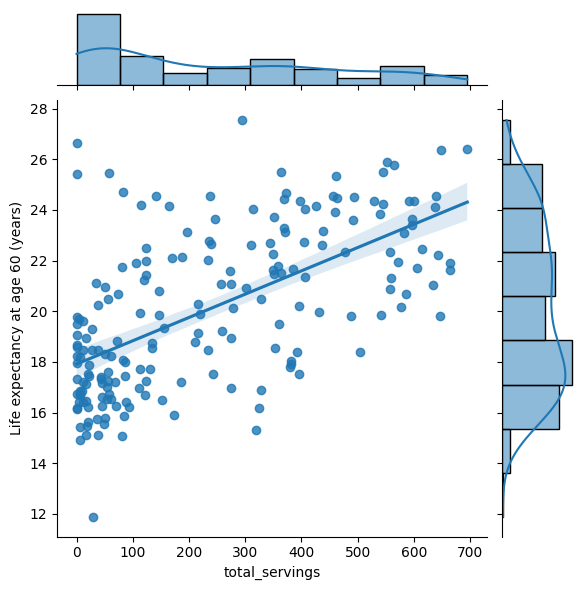

In [148]:
sns.jointplot(x='total_servings', y='Life expectancy at age 60 (years)', data=table_numeric_female_and_drinks_without_skip, kind='reg')

Рассчитаем отдельно коэффициент корреляции для двух наших параметров

In [149]:
ratio_korr = table_numeric_female_and_drinks_without_skip['total_servings'].corr(table_numeric_female_and_drinks_without_skip['Life expectancy at age 60 (years)'])
ratio_korr

0.6100161210508119

Как видим, он имеет тоже значение, что и в матрице попарных коэффицентов корреляции 'pattern_female'. Значит, мы правильно выбрали 2 параметра для установления взаимосвязи исходя из коэффицентов корреляции (другие коэффициенты были меньше, значит, тенд был бы выражен слабее)

Таким образом, ранее сделанные выводы подтверждаются и данными расчетами с графическими построениями.